In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from torch.optim.lr_scheduler import CosineAnnealingLR
import warnings
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, matthews_corrcoef, accuracy_score, mean_absolute_error
import pickle
import mygene
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler as SkScaler
from lifelines.utils import concordance_index as lifelines_ci
import matplotlib.gridspec as gridspec
from captum.attr import IntegratedGradients

/g/data/yr31/rn8079/PhD/processing_tcga/pyenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Preparation

In [2]:
# ── paths ────────────────────────────────────────────────────────────────────
DATA_DIR   = "/g/data/yr31/rn8079/database/ucsc_xena/data"

RNA_PATH    = f"{DATA_DIR}/TCGA_rna.csv"
MIRNA_PATH  = f"{DATA_DIR}/TCGA_mirna.csv"
METHYL_PATH = f"{DATA_DIR}/TCGA_methylation.csv"
CLIN_PATH   = f"{DATA_DIR}/TCGA-BRCA.full_clinical.csv"

# ── M-value transform for methylation ────────────────────────────────────────
def beta_to_mvalue(X: np.ndarray, epsilon: float = 1e-6) -> np.ndarray:
    X = np.clip(X, epsilon, 1 - epsilon)
    return np.log2(X / (1 - X))

# ── fold-safe z-score helpers ─────────────────────────────────────────────────
def compute_scaler(X: np.ndarray):
    mean = X.mean(axis=0)
    std  = X.std(axis=0)
    std[std == 0] = 1.0
    return mean, std

def apply_scaler(X: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    return (X - mean) / std

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
class TCGABRCADataset(Dataset):
    """
    Extended multi-omics dataset with multi-task labels.
    
    Returns dict with:
        - mask: modality availability (bool, [3])
        - rna, mirna, methyl: omics tensors
    """
    
    # ── class-level storage (same pattern as your existing code) ──
    _pfi_time   = None
    _pfi_event  = None
     
    def __init__(
        self,
        indices,
        rna_scaler=None,
        mirna_scaler=None,
        methyl_scaler=None,
        dropout_probs=None,
    ):
        self.indices       = np.array(indices)
        self.rna_scaler    = rna_scaler
        self.mirna_scaler  = mirna_scaler
        self.methyl_scaler = methyl_scaler
        self.dropout_probs = dropout_probs  # None at val/test time

        # Access pre-loaded aligned arrays via class-level attributes
        # (populated by load_data() before instantiating any Dataset)
        self.rna_data    = TCGABRCADataset._rna_data
        self.mirna_data  = TCGABRCADataset._mirna_data
        self.methyl_data = TCGABRCADataset._methyl_data
        self.rna_mask    = TCGABRCADataset._rna_mask
        self.mirna_mask  = TCGABRCADataset._mirna_mask
        self.methyl_mask = TCGABRCADataset._methyl_mask
        self.sample_ids  = TCGABRCADataset._sample_ids

    def __len__(self):
        return len(self.indices)
    
    @classmethod
    def _prepare_survival_labels(cls, clinical_df, sample_ids):
        """Load PFI survival labels. OS dropped -- PFI is the primary endpoint."""
        clin = clinical_df.set_index('sampleID')
        n_samples = len(sample_ids)
        pfi_time  = torch.full((n_samples,), -1.0, dtype=torch.float32)
        pfi_event = torch.full((n_samples,), -1,   dtype=torch.long)

        for i, sid in enumerate(sample_ids):
            if sid not in clin.index:
                continue
            row = clin.loc[sid]
            pfi_t = row.get('PFI_time', None)
            pfi_e = row.get('PFI', None)
            if pd.notna(pfi_t) and pd.notna(pfi_e):
                pfi_time[i]  = float(pfi_t)
                pfi_event[i] = int(pfi_e)

        cls._pfi_time  = pfi_time
        cls._pfi_event = pfi_event

        valid  = (pfi_event >= 0).sum().item()
        events = (pfi_event == 1).sum().item()
        print(f"  PFI: {valid}/{n_samples} valid, {events} events")

       
    def __getitem__(self, idx):
        i = self.indices[idx]

        # ── modality availability (natural missingness) ───────────────────
        rna_obs    = bool(self.rna_mask[i])
        mirna_obs  = bool(self.mirna_mask[i])
        methyl_obs = bool(self.methyl_mask[i])

        # ── training-time modality dropout ───────────────────────────────
        # Never drop all modalities -- ensure at least one remains observed
        if self.dropout_probs is not None:
            max_attempts = 10
            for _ in range(max_attempts):
                rna_drop    = rna_obs    and (np.random.rand() < self.dropout_probs["rna"])
                mirna_drop  = mirna_obs  and (np.random.rand() < self.dropout_probs["mirna"])
                methyl_drop = methyl_obs and (np.random.rand() < self.dropout_probs["methyl"])
        
                if not (rna_drop and mirna_drop and methyl_drop):
                    break
            else:
                # Could not find a valid combination -- keep all naturally observed modalities
                rna_drop = mirna_drop = methyl_drop = False
        
            rna_obs    = rna_obs    and not rna_drop
            mirna_obs  = mirna_obs  and not mirna_drop
            methyl_obs = methyl_obs and not methyl_drop

        # ── build tensors for observed modalities ────────────────────────
        rna_tensor = methyl_tensor = mirna_tensor = None

        if rna_obs:
            x = self.rna_data[i].copy()
            if self.rna_scaler is not None:
                x = apply_scaler(x, *self.rna_scaler)
            rna_tensor = torch.tensor(x, dtype=torch.float32)

        if mirna_obs:
            x = self.mirna_data[i].copy()
            if self.mirna_scaler is not None:
                x = apply_scaler(x, *self.mirna_scaler)
            mirna_tensor = torch.tensor(x, dtype=torch.float32)

        if methyl_obs:
            x = self.methyl_data[i].copy()
            if self.methyl_scaler is not None:
                x = apply_scaler(x, *self.methyl_scaler)
            methyl_tensor = torch.tensor(x, dtype=torch.float32)

        # ── availability mask ─────────────────────────────────────────────
        mask = torch.tensor(
            [rna_obs, mirna_obs, methyl_obs],
            dtype=torch.bool
        )

        return {
            "rna":       rna_tensor,
            "mirna":     mirna_tensor,
            "methyl":    methyl_tensor,
            "mask":      mask,
            "sample_id": self.sample_ids[i],
            # multi-task labels
            "pfi_time":   TCGABRCADataset._pfi_time[i],
            "pfi_event":  TCGABRCADataset._pfi_event[i],
        }


# ─────────────────────────────────────────────────────────────────────────────
def load_data():
    print("Loading clinical data ...")
    clin = pd.read_csv(CLIN_PATH, low_memory=False)
    clin = clin.drop_duplicates(subset="sampleID").set_index("sampleID")
    print(f"  Clinical samples: {len(clin)}")

    print("\nLoading mRNA ...")
    rna = pd.read_csv(RNA_PATH, index_col=0)
    print(f"  Shape: {rna.shape}")

    print("Loading miRNA ...")
    mirna = pd.read_csv(MIRNA_PATH, index_col=0)
    print(f"  Shape: {mirna.shape}")

    print("Loading methylation (large file, may take a moment) ...")
    methyl = pd.read_csv(METHYL_PATH, index_col=0)
    print(f"  Shape: {methyl.shape}")

    print("Loading mRNA ...")
    rna = pd.read_csv(RNA_PATH, index_col=0)
    print(f"  Shape: {rna.shape}")
    TCGABRCADataset._rna_feature_names = list(rna.columns)       # ← ADD
    
    print("Loading miRNA ...")
    mirna = pd.read_csv(MIRNA_PATH, index_col=0)
    print(f"  Shape: {mirna.shape}")
    TCGABRCADataset._mirna_feature_names = list(mirna.columns)   # ← ADD
    
    print("Loading methylation (large file, may take a moment) ...")
    methyl = pd.read_csv(METHYL_PATH, index_col=0)
    print(f"  Shape: {methyl.shape}")
    TCGABRCADataset._methyl_feature_names = list(methyl.columns) # ← ADD

    # M-value transform on methylation beta values
    print("\nApplying M-value transform to methylation ...")
    methyl_mvals = beta_to_mvalue(methyl.values.astype(np.float32))
    methyl = pd.DataFrame(methyl_mvals, index=methyl.index, columns=methyl.columns)

    all_clin    = set(clin.index)
    rna_sids    = set(rna.index)    & all_clin
    mirna_sids  = set(mirna.index)  & all_clin
    methyl_sids = set(methyl.index) & all_clin
    union_sids  = rna_sids | mirna_sids | methyl_sids

    print(f"\nClinical samples:               {len(all_clin)}")
    print(f"mRNA observed:                  {len(rna_sids)}")
    print(f"miRNA observed:                 {len(mirna_sids)}")
    print(f"Methylation observed:           {len(methyl_sids)}")
    print(f"Total usable (union):           {len(union_sids)}")

    # Master index: one row per usable sample, ordered consistently
    master_ids = sorted(union_sids)
    n          = len(master_ids)

    n_rna    = rna.shape[1]
    n_mirna  = mirna.shape[1]
    n_methyl = methyl.shape[1]

    # Allocate aligned arrays
    rna_arr    = np.full((n, n_rna),    np.nan, dtype=np.float32)
    mirna_arr  = np.full((n, n_mirna),  np.nan, dtype=np.float32)
    methyl_arr = np.full((n, n_methyl), np.nan, dtype=np.float32)
    rna_mask    = np.zeros(n, dtype=bool)
    mirna_mask  = np.zeros(n, dtype=bool)
    methyl_mask = np.zeros(n, dtype=bool)
    labels      = np.zeros(n, dtype=np.int64)

    print("\nFilling aligned arrays ...")
    for i, sid in enumerate(master_ids):
        if sid in rna_sids:
            rna_arr[i]    = rna.loc[sid].values
            rna_mask[i]   = True
        if sid in mirna_sids:
            mirna_arr[i]  = mirna.loc[sid].values
            mirna_mask[i] = True
        if sid in methyl_sids:
            methyl_arr[i]  = methyl.loc[sid].values
            methyl_mask[i] = True

    # Store as class-level attributes
    TCGABRCADataset._rna_data    = rna_arr
    TCGABRCADataset._mirna_data  = mirna_arr
    TCGABRCADataset._methyl_data = methyl_arr
    TCGABRCADataset._rna_mask    = rna_mask
    TCGABRCADataset._mirna_mask  = mirna_mask
    TCGABRCADataset._methyl_mask = methyl_mask
    TCGABRCADataset._sample_ids  = np.array(master_ids)

    # Missingness summary
    print("\nMissingness pattern:")
    print(f"  All three:            {(rna_mask & mirna_mask & methyl_mask).sum()}")
    print(f"  mRNA + miRNA only:    {(rna_mask & mirna_mask & ~methyl_mask).sum()}")
    print(f"  mRNA + methyl only:   {(rna_mask & ~mirna_mask & methyl_mask).sum()}")
    print(f"  mRNA only:            {(rna_mask & ~mirna_mask & ~methyl_mask).sum()}")
    print(f"\nFeature dimensions:")
    print(f"  mRNA:        {n_rna}")
    print(f"  miRNA:       {n_mirna}")
    print(f"  Methylation: {n_methyl}")

    return np.array(master_ids)


In [4]:
# ── run once ──────────────────────────────────────────────────────────────────
master = load_data()
clinical_df = pd.read_csv(CLIN_PATH, low_memory=False)
TCGABRCADataset._prepare_survival_labels(clinical_df, TCGABRCADataset._sample_ids)

Loading clinical data ...
  Clinical samples: 1097

Loading mRNA ...
  Shape: (1095, 4652)
Loading miRNA ...
  Shape: (1078, 524)
Loading methylation (large file, may take a moment) ...
  Shape: (784, 37482)
Loading mRNA ...
  Shape: (1095, 4652)
Loading miRNA ...
  Shape: (1078, 524)
Loading methylation (large file, may take a moment) ...
  Shape: (784, 37482)

Applying M-value transform to methylation ...

Clinical samples:               1097
mRNA observed:                  1094
miRNA observed:                 1077
Methylation observed:           783
Total usable (union):           1096

Filling aligned arrays ...

Missingness pattern:
  All three:            771
  mRNA + miRNA only:    304
  mRNA + methyl only:   10
  mRNA only:            9

Feature dimensions:
  mRNA:        4652
  miRNA:       524
  Methylation: 37482
  PFI: 1095/1096 valid, 145 events


## Model

In [5]:
# ── constants (from loaded data) ──────────────────────────────────────────────
N_RNA    = TCGABRCADataset._rna_data.shape[1]     # 4652
N_MIRNA  = TCGABRCADataset._mirna_data.shape[1]   # 524
N_METHYL = TCGABRCADataset._methyl_data.shape[1]  # 37482
N_LATENT = 48
# ── helper: build a feedforward block ────────────────────────────────────────
def fc_block(in_dim: int, out_dim: int, dropout: float = 0.2) -> nn.Sequential:
    return nn.Sequential(
        nn.Linear(in_dim, out_dim),
        nn.LayerNorm(out_dim),
        nn.GELU(),
        nn.Dropout(dropout),
    )

In [6]:
class RNAEncoder(nn.Module):
    """mRNA encoder: 4652 -> 512 -> 256 -> 96 -> mu/logvar (48)"""
    def __init__(self, in_dim: int = N_RNA, latent_dim: int = N_LATENT):
        super().__init__()
        self.net = nn.Sequential(
            fc_block(in_dim, 512, dropout=0.3),
            fc_block(512,    256, dropout=0.2),
            fc_block(256,     96, dropout=0.2),
        )
        self.fc_mu     = nn.Linear(96, latent_dim)
        self.fc_logvar = nn.Linear(96, latent_dim)

    def forward(self, x):
        h = self.net(x)
        return self.fc_mu(h), self.fc_logvar(h)


class MIRNAEncoder(nn.Module):
    """miRNA encoder: 524 -> 128 -> 96 -> mu/logvar (48)"""
    def __init__(self, in_dim: int = N_MIRNA, latent_dim: int = N_LATENT):
        super().__init__()
        self.net = nn.Sequential(
            fc_block(in_dim, 128, dropout=0.2),
            fc_block(128,     96, dropout=0.2),
        )
        self.fc_mu     = nn.Linear(96, latent_dim)
        self.fc_logvar = nn.Linear(96, latent_dim)

    def forward(self, x):
        h = self.net(x)
        return self.fc_mu(h), self.fc_logvar(h)


class MethylEncoder(nn.Module):
    """Methylation encoder: 37482 -> 512 -> 256 -> 96 -> mu/logvar (48)"""
    def __init__(self, in_dim: int = N_METHYL, latent_dim: int = N_LATENT):
        super().__init__()
        self.input_layer = nn.Linear(in_dim, 512)
        self.input_norm  = nn.LayerNorm(512)
        self.input_act   = nn.GELU()
        self.input_drop  = nn.Dropout(0.4)
        self.net = nn.Sequential(
            fc_block(512, 256, dropout=0.2),
            fc_block(256,  96, dropout=0.2),
        )
        self.fc_mu     = nn.Linear(96, latent_dim)
        self.fc_logvar = nn.Linear(96, latent_dim)

    def forward(self, x):
        h = self.input_layer(x)
        h = self.input_drop(self.input_act(self.input_norm(h)))
        h = self.net(h)
        return self.fc_mu(h), self.fc_logvar(h)


# ─────────────────────────────────────────────────────────────────────────────
# Quick parameter count check
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

rna_enc    = RNAEncoder()
mirna_enc  = MIRNAEncoder()
methyl_enc = MethylEncoder()

print(f"RNAEncoder    parameters: {count_params(rna_enc):>12,}")
print(f"MIRNAEncoder  parameters: {count_params(mirna_enc):>12,}")
print(f"MethylEncoder parameters: {count_params(methyl_enc):>12,}")
print(f"Total encoder parameters: {count_params(rna_enc) + count_params(mirna_enc) + count_params(methyl_enc):>12,}")

RNAEncoder    parameters:    2,549,376
MIRNAEncoder  parameters:       89,344
MethylEncoder parameters:   19,358,336
Total encoder parameters:   21,997,056


In [7]:
# Confirm forward pass works for each encoder
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

rna_enc    = rna_enc.to(device)
mirna_enc  = mirna_enc.to(device)
methyl_enc = methyl_enc.to(device)

# Dummy batch of 128 samples
dummy_rna    = torch.randn(128, N_RNA).to(device)
dummy_mirna  = torch.randn(128, N_MIRNA).to(device)
dummy_methyl = torch.randn(128, N_METHYL).to(device)

mu_rna,    lv_rna    = rna_enc(dummy_rna)
mu_mirna,  lv_mirna  = mirna_enc(dummy_mirna)
mu_methyl, lv_methyl = methyl_enc(dummy_methyl)

print(f"RNA    encoder output -- mu: {mu_rna.shape},    logvar: {lv_rna.shape}")
print(f"miRNA  encoder output -- mu: {mu_mirna.shape},  logvar: {lv_mirna.shape}")
print(f"Methyl encoder output -- mu: {mu_methyl.shape}, logvar: {lv_methyl.shape}")
print("All encoder forward passes OK")

Device: cuda
RNA    encoder output -- mu: torch.Size([128, 48]),    logvar: torch.Size([128, 48])
miRNA  encoder output -- mu: torch.Size([128, 48]),  logvar: torch.Size([128, 48])
Methyl encoder output -- mu: torch.Size([128, 48]), logvar: torch.Size([128, 48])
All encoder forward passes OK


In [8]:
class ProductOfExperts(nn.Module):
    """
    Extended PoE that incorporates translated pseudo-posteriors
    for missing modalities.
    
    Real posteriors contribute full precision.
    Translated posteriors contribute gated precision:
        precision_translated = gate * precision_pseudo
    where gate in (0, 1) is learned per translation direction.
    """
    
    def __init__(self, latent_dim, eps=1e-8):
        super().__init__()
        self.latent_dim = latent_dim
        self.eps = eps
    
    def forward(self, mu_list, logvar_list, 
                translated_mu_list=None, translated_logvar_list=None,
                translation_gates=None):
        """
        Args:
            mu_list: list of (mu, ) for OBSERVED modalities
            logvar_list: list of (logvar, ) for OBSERVED modalities
            translated_mu_list: list of (mu, ) for TRANSLATED pseudo-posteriors
            translated_logvar_list: list of (logvar, ) for TRANSLATED pseudo-posteriors
            translation_gates: list of scalar gates in (0,1) for each translated posterior
        """
        # Prior: N(0, I) -> precision = 1, mu*precision = 0
        batch_size = mu_list[0].size(0)
        mu_prior = torch.zeros(batch_size, self.latent_dim, device=mu_list[0].device)
        logvar_prior = torch.zeros(batch_size, self.latent_dim, device=mu_list[0].device)
        
        # Accumulate precision (1/sigma^2) and precision-weighted means
        precision = torch.exp(-logvar_prior)  # prior precision = 1
        precision_mu = mu_prior * precision   # prior: 0
        
        # Real observed posteriors (full precision)
        for mu, logvar in zip(mu_list, logvar_list):
            prec = torch.exp(-logvar)
            precision = precision + prec
            precision_mu = precision_mu + mu * prec
        
        # Translated pseudo-posteriors (gated precision)
        if translated_mu_list is not None:
            for mu_t, logvar_t, gate in zip(
                translated_mu_list, translated_logvar_list, translation_gates
            ):
                prec_t = torch.exp(-logvar_t)
                # gate is [batch, 1] or scalar, downweights translated precision
                gated_prec = gate * prec_t
                precision = precision + gated_prec
                precision_mu = precision_mu + mu_t * gated_prec
        
        mu_poe = precision_mu / (precision + self.eps)
        logvar_poe = -torch.log(precision + self.eps)
        
        return mu_poe, logvar_poe

def reparameterise(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    """
    Reparameterisation trick: z = mu + eps * std, eps ~ N(0, I)
    Enables gradients to flow through the sampling operation.
    At inference time (model.eval()), returns mu directly.
    """
    if not torch.is_grad_enabled():
        return mu
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std


# ─────────────────────────────────────────────────────────────────────────────
# Quick sanity check: verify PoE with different observed subsets
poe = ProductOfExperts(latent_dim=N_LATENT).to(device)

# Simulate a batch where all three modalities are observed
mu_poe_full, lv_poe_full = poe(
    [mu_rna, mu_mirna, mu_methyl],
    [lv_rna, lv_mirna, lv_methyl]
)
# Simulate mRNA + miRNA only (methylation absent -- just omit from lists)
mu_poe_2mod, lv_poe_2mod = poe(
    [mu_rna, mu_mirna],
    [lv_rna, lv_mirna]
)
# Simulate mRNA only
mu_poe_1mod, lv_poe_1mod = poe(
    [mu_rna],
    [lv_rna]
)
print(f"PoE full (3 modalities) -- mu: {mu_poe_full.shape}, logvar: {lv_poe_full.shape}")
print(f"PoE 2 modalities        -- mu: {mu_poe_2mod.shape}, logvar: {lv_poe_2mod.shape}")
print(f"PoE 1 modality          -- mu: {mu_poe_1mod.shape}, logvar: {lv_poe_1mod.shape}")

# Variance should decrease as more modalities are added
print(f"\nMean variance -- full: {lv_poe_full.exp().mean():.4f}, "
      f"2-mod: {lv_poe_2mod.exp().mean():.4f}, "
      f"1-mod: {lv_poe_1mod.exp().mean():.4f}")
print("Variance should decrease from 1-mod to full -- PoE OK if true")

# ─────────────────────────────────────────────────────────────────────────────
# Test PoE with translated pseudo-posteriors
print(f"\n── PoE with translations ──")

# Scenario: methyl missing, translate rna->methyl and mirna->methyl
dummy_trans_mu = [torch.randn(128, N_LATENT, device=device)]
dummy_trans_lv = [torch.randn(128, N_LATENT, device=device)]
dummy_gates = [torch.full((128, 1), 0.25, device=device)]  # conservative gate

mu_poe_trans, lv_poe_trans = poe(
    [mu_rna, mu_mirna],          # observed: rna + mirna
    [lv_rna, lv_mirna],
    translated_mu_list=dummy_trans_mu,
    translated_logvar_list=dummy_trans_lv,
    translation_gates=dummy_gates
)
print(f"PoE 2-mod + 1 translation -- mu: {mu_poe_trans.shape}, logvar: {lv_poe_trans.shape}")

var_no_trans = lv_poe_2mod.exp().mean().item()
var_with_trans = lv_poe_trans.exp().mean().item()
print(f"Variance without translation: {var_no_trans:.4f}")
print(f"Variance with translation:    {var_with_trans:.4f}")
print(f"Translation tightens posterior: {var_with_trans < var_no_trans} (should be True)")

# Gate at 0 should give identical result to no translation
dummy_gates_zero = [torch.zeros(128, 1, device=device)]
mu_poe_gate0, lv_poe_gate0 = poe(
    [mu_rna, mu_mirna],
    [lv_rna, lv_mirna],
    translated_mu_list=dummy_trans_mu,
    translated_logvar_list=dummy_trans_lv,
    translation_gates=dummy_gates_zero
)
mu_diff = (mu_poe_gate0 - mu_poe_2mod).abs().max().item()
lv_diff = (lv_poe_gate0 - lv_poe_2mod).abs().max().item()
print(f"\nGate=0 vs no translation -- mu diff: {mu_diff:.8f}, logvar diff: {lv_diff:.8f}")
print(f"Zero gate recovers original PoE: {mu_diff < 1e-5 and lv_diff < 1e-5} (should be True)")

PoE full (3 modalities) -- mu: torch.Size([128, 48]), logvar: torch.Size([128, 48])
PoE 2 modalities        -- mu: torch.Size([128, 48]), logvar: torch.Size([128, 48])
PoE 1 modality          -- mu: torch.Size([128, 48]), logvar: torch.Size([128, 48])

Mean variance -- full: 0.2417, 2-mod: 0.3270, 1-mod: 0.4952
Variance should decrease from 1-mod to full -- PoE OK if true

── PoE with translations ──
PoE 2-mod + 1 translation -- mu: torch.Size([128, 48]), logvar: torch.Size([128, 48])
Variance without translation: 0.3270
Variance with translation:    0.2920
Translation tightens posterior: True (should be True)

Gate=0 vs no translation -- mu diff: 0.00000000, logvar diff: 0.00000000
Zero gate recovers original PoE: True (should be True)


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
class RNADecoder(nn.Module):
    """
    mRNA decoder: 48 -> 96 -> 256 -> 512 -> 4652
    Mirror of RNAEncoder. No activation on output layer since
    log2(TPM+1) values are unbounded positive reals -- MSE reconstruction loss.
    """
    def __init__(self, latent_dim: int = N_LATENT, out_dim: int = N_RNA):
        super().__init__()
        self.net = nn.Sequential(
            fc_block(latent_dim, 96,  dropout=0.2),
            fc_block(96,         256, dropout=0.2),
            fc_block(256,        512, dropout=0.2),
            nn.Linear(512, out_dim),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)


# ─────────────────────────────────────────────────────────────────────────────
class MIRNADecoder(nn.Module):
    """
    miRNA decoder: 48 -> 96 -> 128 -> 524
    Mirror of MIRNAEncoder.
    """
    def __init__(self, latent_dim: int = N_LATENT, out_dim: int = N_MIRNA):
        super().__init__()
        self.net = nn.Sequential(
            fc_block(latent_dim, 96,  dropout=0.2),
            fc_block(96,         128, dropout=0.2),
            nn.Linear(128, out_dim),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)


# ─────────────────────────────────────────────────────────────────────────────
class MethylDecoder(nn.Module):
    """
    Methylation decoder: 48 -> 96 -> 256 -> 512 -> 37482
    Mirror of MethylEncoder. Output is M-values (unbounded) -- MSE loss.

    Note: the large output layer (512 -> 37482) is the decoder counterpart
    of the encoder bottleneck. It is only used for the ELBO reconstruction
    term and does not affect prediction quality directly.
    """
    def __init__(self, latent_dim: int = N_LATENT, out_dim: int = N_METHYL):
        super().__init__()
        self.net = nn.Sequential(
            fc_block(latent_dim, 96,  dropout=0.2),
            fc_block(96,         256, dropout=0.2),
            fc_block(256,        512, dropout=0.2),
            nn.Linear(512, out_dim),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)


# ─────────────────────────────────────────────────────────────────────────────
# Parameter counts
rna_dec    = RNADecoder().to(device)
mirna_dec  = MIRNADecoder().to(device)
methyl_dec = MethylDecoder().to(device)

print(f"RNADecoder    parameters: {count_params(rna_dec):>12,}")
print(f"MIRNADecoder  parameters: {count_params(mirna_dec):>12,}")
print(f"MethylDecoder parameters: {count_params(methyl_dec):>12,}")
print(f"Total decoder parameters: {count_params(rna_dec) + count_params(mirna_dec) + count_params(methyl_dec):>12,}")

# Forward pass check
z_sample = reparameterise(mu_poe_full, lv_poe_full)
print(f"\nLatent sample shape: {z_sample.shape}")

rna_recon    = rna_dec(z_sample)
mirna_recon  = mirna_dec(z_sample)
methyl_recon = methyl_dec(z_sample)

print(f"RNA    reconstruction: {rna_recon.shape}")
print(f"miRNA  reconstruction: {mirna_recon.shape}")
print(f"Methyl reconstruction: {methyl_recon.shape}")
print("All decoder forward passes OK")

RNADecoder    parameters:    2,549,324
MIRNADecoder  parameters:       85,164
MethylDecoder parameters:   19,391,114
Total decoder parameters:   22,025,602

Latent sample shape: torch.Size([128, 48])
RNA    reconstruction: torch.Size([128, 4652])
miRNA  reconstruction: torch.Size([128, 524])
Methyl reconstruction: torch.Size([128, 37482])
All decoder forward passes OK


In [10]:
class SurvivalHead(nn.Module):
    """
    Linear Cox PH head from latent space.
    
    Produces a scalar risk score per sample. Trained with the
    negative Cox partial log-likelihood.
    
    Deliberately linear (no hidden layers) to prevent the survival
    signal from dominating the latent space -- we want the latent
    to primarily capture classification-relevant structure with
    survival as a secondary regulariser.
    """
    
    def __init__(self, latent_dim):
        super().__init__()
        self.risk = nn.Linear(latent_dim, 1)
    
    def forward(self, z):
        """Returns risk score: [batch, 1]"""
        return self.risk(z)


        
def cox_partial_likelihood_loss(risk_scores, os_time, os_event):
    """
    Negative partial log-likelihood for Cox PH model.
    
    Args:
        risk_scores: [batch, 1] raw risk scores (higher = more risk)
        os_time:     [batch] survival/follow-up time
        os_event:    [batch] event indicator (1 = death, 0 = censored)
    
    Returns:
        scalar loss (mean over uncensored samples)
    
    Only computes over samples with valid survival data (os_event >= 0).
    Requires at least 2 valid samples with >= 1 event.
    """
    # Filter valid samples
    valid = os_event >= 0
    if valid.sum() < 2 or os_event[valid].sum() < 1:
        return torch.tensor(0.0, device=risk_scores.device, requires_grad=True)
    
    risk = risk_scores[valid].squeeze(-1)  # [n_valid]
    time = os_time[valid]                   # [n_valid]
    event = os_event[valid].float()         # [n_valid]
    
    # Sort by descending time (for risk set computation)
    sorted_idx = torch.argsort(time, descending=True)
    risk = risk[sorted_idx]
    event = event[sorted_idx]
    
    # Log-sum-exp trick for numerical stability
    # For each uncensored event i, the risk set R_i = {j : t_j >= t_i}
    # With descending sort, R_i = {0, 1, ..., i}
    # log P = sum_i [event_i * (risk_i - log(sum_{j in R_i} exp(risk_j)))]
    
    log_cumsum_exp = torch.logcumsumexp(risk, dim=0)  # [n_valid]
    
    partial_ll = event * (risk - log_cumsum_exp)
    
    n_events = event.sum()
    if n_events > 0:
        return -partial_ll.sum() / n_events
    else:
        return torch.tensor(0.0, device=risk_scores.device, requires_grad=True)
        

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Latent Cross-Modal Translation
# ─────────────────────────────────────────────────────────────────────────────

class LatentTranslationHead(nn.Module):
    """Translates source posterior into pseudo-posterior for target modality."""
    def __init__(self, latent_dim, hidden_dim=96):
        super().__init__()
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            nn.Linear(2 * latent_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 2 * latent_dim),
        )
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, mu_src, logvar_src):
        h = torch.cat([mu_src, logvar_src], dim=-1)
        out = self.net(h)
        mu_pseudo = out[:, :self.latent_dim]
        logvar_pseudo = torch.clamp(out[:, self.latent_dim:], min=-6.0, max=2.0)
        return mu_pseudo, logvar_pseudo


class TranslationGateNetwork(nn.Module):
    """Per-sample confidence gate. Predicts trust from source posterior alone."""
    def __init__(self, latent_dim, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2 * latent_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
        )
        nn.init.zeros_(self.net[-1].weight)
        nn.init.constant_(self.net[-1].bias, -1.0)

    def forward(self, mu_src, logvar_src):
        h = torch.cat([mu_src, logvar_src], dim=-1)
        return torch.sigmoid(self.net(h))


class CrossModalTranslator(nn.Module):
    """Manages all 6 pairwise translation directions with per-sample gates."""
    MODALITY_NAMES = ['rna', 'mirna', 'methyl']

    def __init__(self, latent_dim, hidden_dim=96, gate_hidden_dim=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.n_modalities = 3
        self.translation_heads = nn.ModuleDict()
        self.gate_networks = nn.ModuleDict()

        for src in range(self.n_modalities):
            for tgt in range(self.n_modalities):
                if src == tgt:
                    continue
                key = f"{src}_to_{tgt}"
                self.translation_heads[key] = LatentTranslationHead(latent_dim, hidden_dim)
                self.gate_networks[key] = TranslationGateNetwork(latent_dim, gate_hidden_dim)

    def forward(self, mus, logvars, mask):
        translated_mus = []
        translated_logvars = []
        gates = []
        batch_size = mus[0].shape[0]
        for src in range(self.n_modalities):
            for tgt in range(self.n_modalities):
                if src == tgt:
                    continue
                key = f"{src}_to_{tgt}"
                needs_translation = mask[:, src] & (~mask[:, tgt])
                if not needs_translation.any():
                    continue

                mu_pseudo_sub, logvar_pseudo_sub = self.translation_heads[key](
                    mus[src][needs_translation], logvars[src][needs_translation]
                )
                gate_sub = self.gate_networks[key](
                    mus[src][needs_translation], logvars[src][needs_translation]
                )
                # Scatter back to full batch shape for PoE addition
                mu_pseudo  = torch.zeros(batch_size, self.latent_dim, device=mus[src].device)
                lv_pseudo  = torch.zeros(batch_size, self.latent_dim, device=mus[src].device)
                gate_full  = torch.zeros(batch_size, 1,               device=mus[src].device)
                mu_pseudo[needs_translation]  = mu_pseudo_sub
                lv_pseudo[needs_translation]  = logvar_pseudo_sub
                gate_full[needs_translation]  = gate_sub
                translated_mus.append(mu_pseudo)
                translated_logvars.append(lv_pseudo)
                gates.append(gate_full)

        return translated_mus, translated_logvars, gates


def translation_consistency_loss(mus, logvars, translator, mask):
    """
    Wasserstein W2 distance between real and translated posteriors for
    fully-observed pairs. Replaces asymmetric KL with symmetric W2.

    Closed form for diagonal Gaussians:
        W2^2 = ||mu_pseudo - mu_real||^2 + ||sigma_pseudo - sigma_real||^2

    Advantages over KL:
        - Symmetric: penalises both directions of divergence equally
        - Does not blow up when distributions have non-overlapping support
          (important early in training before translation heads have converged)
        - Penalises mean and variance mismatch equally
        - More stable gradients when pseudo-posterior is far from real posterior
    """
    total_loss = 0.0
    n_pairs    = 0

    for src in range(3):
        for tgt in range(3):
            if src == tgt:
                continue
            both_observed = mask[:, src] & mask[:, tgt]
            if not both_observed.any():
                continue

            key = f"{src}_to_{tgt}"
            mu_pseudo, logvar_pseudo = translator.translation_heads[key](
                mus[src], logvars[src]
            )

            mu_real     = mus[tgt].detach()
            logvar_real = logvars[tgt].detach()

            # Convert logvar to std for W2 computation
            sigma_pseudo = torch.exp(0.5 * logvar_pseudo)
            sigma_real   = torch.exp(0.5 * logvar_real)

            # W2^2 = mean and variance terms
            mean_term = (mu_pseudo - mu_real).pow(2)
            var_term  = (sigma_pseudo - sigma_real).pow(2)

            w2 = (mean_term + var_term)[both_observed].mean()
            total_loss = total_loss + w2
            n_pairs += 1

    if n_pairs > 0:
        return total_loss / n_pairs
    return torch.tensor(0.0, device=mus[0].device, requires_grad=True)

def cycle_consistency_loss(mus, logvars, translator, mask):
    """
    Cycle consistency: A -> pseudo_B -> pseudo_A_reconstructed ≈ A
    For all 6 directions, using fully-observed pairs.
    Prevents translators from collapsing to mean-seeking solutions.
 
    For each src->tgt->src cycle:
        1. Translate src posterior to pseudo_tgt
        2. Translate pseudo_tgt back to pseudo_src_reconstructed
        3. Penalise MSE between original src mu and reconstructed src mu
 
    The double loop over (src, tgt) implicitly covers both cycle directions:
        src=0, tgt=1  ->  RNA   -> miRNA  -> RNA
        src=1, tgt=0  ->  miRNA -> RNA    -> miRNA
        src=0, tgt=2  ->  RNA   -> methyl -> RNA
        src=2, tgt=0  ->  methyl-> RNA    -> methyl
        src=1, tgt=2  ->  miRNA -> methyl -> miRNA
        src=2, tgt=1  ->  methyl-> miRNA  -> methyl
 
    Fix: removed .detach() on mu_pseudo_tgt / logvar_pseudo_tgt so that
    gradients flow end-to-end through both the forward head (key_fwd) and
    the backward head (key_bwd). Previously only key_bwd received cycle
    gradients; key_fwd relied solely on W2 consistency.
    """
    total_loss = 0.0
    n_cycles   = 0
 
    for src in range(3):
        for tgt in range(3):
            if src == tgt:
                continue
 
            both_observed = mask[:, src] & mask[:, tgt]
            if not both_observed.any():
                continue
 
            key_fwd = f"{src}_to_{tgt}"
            key_bwd = f"{tgt}_to_{src}"
 
            # Forward: src -> pseudo_tgt
            mu_pseudo_tgt, logvar_pseudo_tgt = translator.translation_heads[key_fwd](
                mus[src][both_observed], logvars[src][both_observed]
            )
 
            # Backward: pseudo_tgt -> pseudo_src_reconstructed
            # No .detach() — gradients flow back through key_fwd via key_bwd,
            # so both heads are trained jointly by the round-trip error.
            mu_recon_src, _ = translator.translation_heads[key_bwd](
                mu_pseudo_tgt, logvar_pseudo_tgt
            )
 
            # Cycle loss: reconstructed src mu should match original src mu
            # Detach the target — we are training the translators, not the encoder.
            mu_src_real = mus[src][both_observed].detach()
            cycle_loss  = F.mse_loss(mu_recon_src, mu_src_real)
 
            total_loss = total_loss + cycle_loss
            n_cycles  += 1
 
    if n_cycles > 0:
        return total_loss / n_cycles
 
    return torch.tensor(0.0, device=mus[0].device, requires_grad=True)

def gate_supervision_loss(mus, logvars, translator, mask, survival_head=None):
    """Train gate networks to predict survival-preserving translation quality.
    
    Quality target: how well does the translation preserve the Cox risk score.
    Low risk difference = high quality = gate should open.
    More meaningful than cosine similarity because it targets survival geometry
    directly rather than reconstruction geometry.
    """
    if survival_head is None:
        return torch.tensor(0.0, device=mus[0].device)

    total_loss = 0.0
    n_pairs = 0

    for src in range(3):
        for tgt in range(3):
            if src == tgt:
                continue
            both_observed = mask[:, src] & mask[:, tgt]
            if both_observed.sum() < 2:
                continue

            key = f"{src}_to_{tgt}"
            mu_pseudo, logvar_pseudo = translator.translation_heads[key](
                mus[src][both_observed], logvars[src][both_observed]
            )
            
            with torch.no_grad():
                z_pseudo    = reparameterise(mu_pseudo, logvar_pseudo)
                z_real      = reparameterise(
                    mus[tgt][both_observed],
                    logvars[tgt][both_observed]
                )
                # Use mu directly instead of sampled z — removes stochasticity from target
                risk_pseudo = survival_head(mu_pseudo)
                risk_real   = survival_head(mus[tgt][both_observed])
                
                # Remove no_grad — let quality_target gradient flow through survival_head
                # but keep gate input detached from encoder
                risk_diff      = (risk_pseudo - risk_real).abs().squeeze(1)
                quality_target = torch.exp(-risk_diff).clamp(0.0, 1.0)

            gate_pred = translator.gate_networks[key](
                mus[src][both_observed].detach(),
                logvars[src][both_observed].detach(),
            ).squeeze(1)

            loss = F.mse_loss(gate_pred, quality_target)
            total_loss = total_loss + loss
            n_pairs += 1

    if n_pairs > 0:
        return total_loss / n_pairs
    return torch.tensor(0.0, device=mus[0].device)

In [12]:
master_ids = TCGABRCADataset._sample_ids
n_total    = len(master_ids)
print(f"Total samples confirmed: {n_total}")

Total samples confirmed: 1096


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
def collate_fn(batch: list) -> dict:
    keys = ["rna", "mirna", "methyl"]
    mask   = torch.stack([b["mask"]  for b in batch])
    ids    = [b["sample_id"] for b in batch]
    result = {"mask": mask, "sample_id": ids}
    for k in keys:
        tensors = [b[k] for b in batch]
        if all(t is None for t in tensors):
            result[k] = None
        else:
            ref = next(t for t in tensors if t is not None)
            result[k] = torch.stack([
                t if t is not None else torch.zeros_like(ref) for t in tensors
            ])
    result['pfi_time']   = torch.stack([b['pfi_time']   for b in batch])
    result['pfi_event']  = torch.stack([b['pfi_event']  for b in batch])
    return result

    
# ─────────────────────────────────────────────────────────────────────────────
class BioPoE(nn.Module):
    """
    Dense PoE with per-sample gated latent translation.
    Primary task: PFI survival (Cox regression).
    Representation losses: recon, KL, consistency, translation, cycle, gate.
    No aux heads -- survival ranking loss does not decompose cleanly per modality.
    """
    def __init__(self, latent_dim=N_LATENT, branch_dim=None):
        super().__init__()
        self.latent_dim = latent_dim
        branch_dim = branch_dim or latent_dim

        self.rna_enc    = RNAEncoder(latent_dim=latent_dim)
        self.mirna_enc  = MIRNAEncoder(latent_dim=latent_dim)
        self.methyl_enc = MethylEncoder(latent_dim=latent_dim)

        self.rna_dec    = RNADecoder(latent_dim=latent_dim)
        self.mirna_dec  = MIRNADecoder(latent_dim=latent_dim)
        self.methyl_dec = MethylDecoder(latent_dim=latent_dim)
        
    def forward(self, batch, translator=None, epoch=0, translation_warmup_epochs=10):
        batch_size = batch["mask"].shape[0]
        device     = batch["mask"].device
        mask       = batch["mask"]

        rna_mask    = mask[:, 0]
        mirna_mask  = mask[:, 1]
        methyl_mask = mask[:, 2]

        mu_rna    = torch.zeros(batch_size, self.latent_dim, device=device)
        lv_rna    = torch.zeros(batch_size, self.latent_dim, device=device)
        mu_mirna  = torch.zeros(batch_size, self.latent_dim, device=device)
        lv_mirna  = torch.zeros(batch_size, self.latent_dim, device=device)
        mu_methyl = torch.zeros(batch_size, self.latent_dim, device=device)
        lv_methyl = torch.zeros(batch_size, self.latent_dim, device=device)

        if rna_mask.any() and batch["rna"] is not None:
            mu_r, lv_r = self.rna_enc(batch["rna"][rna_mask])
            mu_rna[rna_mask] = mu_r
            lv_rna[rna_mask] = lv_r
        if mirna_mask.any() and batch["mirna"] is not None:
            mu_m, lv_m = self.mirna_enc(batch["mirna"][mirna_mask])
            mu_mirna[mirna_mask] = mu_m
            lv_mirna[mirna_mask] = lv_m
        if methyl_mask.any() and batch["methyl"] is not None:
            mu_me, lv_me = self.methyl_enc(batch["methyl"][methyl_mask])
            mu_methyl[methyl_mask] = mu_me
            lv_methyl[methyl_mask] = lv_me

        mus     = [mu_rna, mu_mirna, mu_methyl]
        logvars = [lv_rna, lv_mirna, lv_methyl]

        # PoE aggregation
        precision_sum = torch.ones(batch_size, self.latent_dim, device=device)
        weighted_mu   = torch.zeros(batch_size, self.latent_dim, device=device)

        modality_masks = [rna_mask, mirna_mask, methyl_mask]
        for m_idx in range(3):
            obs = modality_masks[m_idx]
            if not obs.any():
                continue
            prec = torch.exp(-logvars[m_idx])
            precision_sum[obs] += prec[obs]
            weighted_mu[obs]   += (prec * mus[m_idx])[obs]

        # Latent translations for missing modalities
        use_translations = (translator is not None and epoch >= translation_warmup_epochs)
        
        if use_translations:
            trans_mus, trans_logvars, trans_gates = translator(mus, logvars, mask)
            for mu_t, lv_t, gate in zip(trans_mus, trans_logvars, trans_gates):
                prec_t = torch.exp(-lv_t)
                gated_prec = gate * prec_t
                precision_sum = precision_sum + gated_prec
                weighted_mu   = weighted_mu + mu_t * gated_prec

        # PoE posterior
        var_poe    = 1.0 / (precision_sum + 1e-8)
        logvar_poe = torch.log(var_poe + 1e-8)
        mu_poe     = var_poe * weighted_mu

        z = reparameterise(mu_poe, logvar_poe)

        # Reconstructions
        recons = {}
        decoders  = [self.rna_dec, self.mirna_dec, self.methyl_dec]
        names     = ["rna", "mirna", "methyl"]
        feat_dims = [N_RNA, N_MIRNA, N_METHYL]
        for m_idx, (dec, name, feat_dim) in enumerate(zip(decoders, names, feat_dims)):
            obs = modality_masks[m_idx]
            if not obs.any():
                continue
            recon_full = torch.zeros(batch_size, feat_dim, device=device)
            recon_full[obs] = dec(z[obs])
            recons[name] = recon_full

        # Sample from individual encoder posteriors for unimodal reconstruction
        z_rna    = reparameterise(mu_rna,    lv_rna)    if rna_mask.any()    else None
        z_mirna  = reparameterise(mu_mirna,  lv_mirna)  if mirna_mask.any()  else None
        z_methyl = reparameterise(mu_methyl, lv_methyl) if methyl_mask.any() else None

        return {
            "mu_poe":    mu_poe,
            "logvar_poe":logvar_poe,
            "z":         z,
            "z_surv":    z,
            "recons":    recons,
            "mus":       mus,
            "logvars":   logvars,
            "z_rna":     z_rna,
            "z_mirna":   z_mirna,
            "z_methyl":  z_methyl,
            "masks":     modality_masks,
        }


def kl_divergence_gaussian(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    """
    KL divergence between N(mu, sigma^2) and N(0, I).
    KL = -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    Averaged over batch and latent dimensions.
    """
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())


def kl_divergence_two_gaussians(
    mu1: torch.Tensor, logvar1: torch.Tensor,
    mu2: torch.Tensor, logvar2: torch.Tensor,
) -> torch.Tensor:
    """
    KL divergence between N(mu1, sigma1^2) and N(mu2, sigma2^2).
    KL = 0.5 * sum( logvar2 - logvar1 - 1
                    + exp(logvar1) / exp(logvar2)
                    + (mu1 - mu2)^2 / exp(logvar2) )
    Averaged over batch and latent dimensions.
    Used for cross-modal consistency regularisation.
    """
    return 0.5 * torch.mean(
        logvar2 - logvar1 - 1
        + logvar1.exp() / logvar2.exp()
        + (mu1 - mu2).pow(2) / logvar2.exp()
    )


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Loss computation
# ─────────────────────────────────────────────────────────────────────────────
VALID_TASK_MODES = {"survival"}

def compute_loss(
    outputs, batch, beta,
    lambda_recon, lambda_consist,
    lambda_translation, lambda_cycle, lambda_gate,
    lambda_survival,
    survival_head, translator,
    epoch, translation_warmup_epochs,
    model=None,
    lambda_unimodal=0.0,
    lambda_surv_trans=0.0,
):
    """Loss: survival + recon + kl + consist + translation + cycle + gate

    Survival (PFI Cox) is the only task loss.
    Representation losses (recon, KL, consist, translation, gate, cycle)
    are always active with fixed manual lambdas.
    """
    device = batch["mask"].device
    mask   = batch["mask"]


    # ── Reconstruction ────────────────────────────────────────────────────────
    # Per-modality reconstruction weights inversely proportional to feature count.
    # Prevents methylation (37482 features) from dominating reconstruction gradients
    # relative to RNA (4652) and miRNA (524).
    # Weights normalised so RNA = 1.0 as the reference modality.
    RECON_WEIGHTS = {
        "rna":    1.0,
        "mirna":  N_RNA / N_MIRNA,   # 4652/524  = 8.88
        "methyl": N_RNA / N_METHYL,  # 4652/37482 = 0.124
    }
    
    loss_recon = torch.tensor(0.0, device=device, requires_grad=True)
    recon_targets = {"rna": batch["rna"], "mirna": batch["mirna"], "methyl": batch["methyl"]}
    for m_idx, m_name in enumerate(["rna", "mirna", "methyl"]):
        if m_name not in outputs["recons"]:
            continue
        obs = mask[:, m_idx]
        if not obs.any() or recon_targets[m_name] is None:
            continue
        loss_recon = loss_recon + RECON_WEIGHTS[m_name] * F.mse_loss(
            outputs["recons"][m_name][obs], recon_targets[m_name][obs]
        )

    # ── Unimodal reconstruction ───────────────────────────────────────────────
    # Decodes from each modality's individual encoder z_i rather than joint z.
    # Forces individual encoder latent spaces to be independently meaningful,
    # giving translation heads a structured target to map toward.
    loss_unimodal = torch.tensor(0.0, device=device, requires_grad=True)
    n_unimodal = 0

    z_individual = {
        "rna":    outputs.get("z_rna"),
        "mirna":  outputs.get("z_mirna"),
        "methyl": outputs.get("z_methyl"),
    }
    decoders_map = {
        "rna":    model.rna_dec,
        "mirna":  model.mirna_dec,
        "methyl": model.methyl_dec,
    }

    for m_idx, m_name in enumerate(["rna", "mirna", "methyl"]):
        z_i = z_individual[m_name]
        if z_i is None:
            continue
        obs = mask[:, m_idx]
        if not obs.any() or recon_targets[m_name] is None:
            continue
        recon_i = decoders_map[m_name](z_i)
        loss_unimodal = loss_unimodal + RECON_WEIGHTS[m_name] * F.mse_loss(
            recon_i[obs], recon_targets[m_name][obs]
        )
        n_unimodal += 1

    if n_unimodal > 0:
        loss_unimodal = loss_unimodal / n_unimodal
        
    # ── KL divergence ─────────────────────────────────────────────────────────
    mu_poe     = outputs["mu_poe"]
    logvar_poe = outputs["logvar_poe"]
    loss_kl = -0.5 * torch.mean(1 + logvar_poe - mu_poe.pow(2) - logvar_poe.exp())

    # ── Consistency ───────────────────────────────────────────────────────────
    loss_consist = torch.tensor(0.0, device=device, requires_grad=True)
    mus     = outputs["mus"]
    logvars = outputs["logvars"]
    mu_poe_d = mu_poe.detach()
    lv_poe_d = logvar_poe.detach()
    n_consist = 0
    for m_idx in range(3):
        obs = mask[:, m_idx]
        if obs.sum() < 2:
            continue
        kl = 0.5 * (
            lv_poe_d[obs] - logvars[m_idx][obs]
            + (logvars[m_idx][obs].exp() + (mus[m_idx][obs] - mu_poe_d[obs]).pow(2))
            / (lv_poe_d[obs].exp() + 1e-8) - 1.0
        )
        loss_consist = loss_consist + kl.mean()
        n_consist += 1
    if n_consist > 0:
        loss_consist = loss_consist / n_consist

    # ── Survival (PFI Cox) ────────────────────────────────────────────────────
    z_surv        = outputs["z_surv"]
    risk_scores   = survival_head(z_surv)
    loss_survival = cox_partial_likelihood_loss(risk_scores, batch["pfi_time"], batch["pfi_event"])
    
    # ── Translation consistency ───────────────────────────────────────────────
    use_trans = (
        translator is not None
        and hasattr(translator, "translation_heads")
        and epoch >= translation_warmup_epochs
    )
    if use_trans:
        loss_translation = translation_consistency_loss(mus, logvars, translator, mask)
        loss_gate        = gate_supervision_loss(mus, logvars, translator, mask, survival_head=survival_head)
        loss_cycle       = cycle_consistency_loss(mus, logvars, translator, mask)

        # ── Survival-preserving translation loss ──────────────────────────────
        # Trains translation heads to preserve Cox risk scores across modalities.
        # For fully-observed pairs, the translated pseudo-posterior should produce
        # a similar risk score to the real target encoder output.
        # This gives translations survival geometry, not just reconstruction geometry.
        loss_surv_trans = torch.tensor(0.0, device=device)
        n_surv_trans = 0
        for src in range(3):
            for tgt in range(3):
                if src == tgt:
                    continue
                both_observed = mask[:, src] & mask[:, tgt]
                if both_observed.sum() < 2:
                    continue
                key = f"{src}_to_{tgt}"
                mu_pseudo, logvar_pseudo = translator.translation_heads[key](
                    mus[src][both_observed], logvars[src][both_observed]
                )
                z_pseudo   = reparameterise(mu_pseudo, logvar_pseudo)
                z_real     = reparameterise(
                    mus[tgt][both_observed].detach(),
                    logvars[tgt][both_observed].detach()
                )
                # Detach survival head parameters from this loss —
                # survival head is used as a fixed scorer only.
                # Only translation heads receive gradients here.
                with torch.no_grad():
                    risk_real = survival_head(z_real)
                # z_pseudo still has grad, but survival head params are frozen
                # by passing through a detached copy of its computation
                risk_pseudo = F.linear(
                    z_pseudo,
                    survival_head.risk.weight.detach(),
                    survival_head.risk.bias.detach()
                )
                loss_surv_trans = loss_surv_trans + F.mse_loss(risk_pseudo, risk_real)
                n_surv_trans += 1
        if n_surv_trans > 0:
            loss_surv_trans = loss_surv_trans / n_surv_trans
    else:
        loss_translation = torch.tensor(0.0, device=device)
        loss_gate        = torch.tensor(0.0, device=device)
        loss_cycle       = torch.tensor(0.0, device=device)
        loss_surv_trans  = torch.tensor(0.0, device=device)

   # ── Total ─────────────────────────────────────────────────────────────────
    total = (
          lambda_survival    * loss_survival
        + lambda_recon       * loss_recon
        + beta               * loss_kl
        + lambda_consist     * loss_consist
        + lambda_translation * loss_translation
        + lambda_gate        * loss_gate
        + lambda_cycle       * loss_cycle
        + lambda_unimodal    * loss_unimodal
        + lambda_surv_trans  * loss_surv_trans
    )

    loss_dict = {
        "total":       total.item(),
        "survival":    loss_survival.item(),
        "recon":       loss_recon.item(),
        "kl":          loss_kl.item(),
        "consist":     loss_consist.item(),
        "translation": loss_translation.item(),
        "cycle":       loss_cycle.item(),
        "gate":        loss_gate.item(),
        "unimodal":    loss_unimodal.item(),
        "surv_trans":  loss_surv_trans.item(),
    }
    return total, loss_dict

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────
def set_seed(seed: int):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # add this line
    torch.use_deterministic_algorithms(True, warn_only=True)  # add this line


def get_beta(epoch, kl_warmup_epochs, beta_max=1.0): 
    if epoch >= kl_warmup_epochs:
        return beta_max
    return beta_max * (epoch / kl_warmup_epochs)


def get_dropout_p(epoch, cfg):
    """
    Curriculum dropout probability for the current epoch.
    Returns 0.0 if dropout is disabled or epoch is before dropout_start_epoch.
    Linearly ramps from 0 -> dropout_p_max over dropout_ramp_epochs,
    then holds at dropout_p_max.
    """
    if not cfg.get("use_modality_dropout", False):
        return 0.0
    start  = cfg["dropout_start_epoch"]
    ramp   = cfg["dropout_ramp_epochs"]
    p_max  = cfg["dropout_p_max"]
    if epoch < start:
        return 0.0
    progress = min(1.0, (epoch - start) / ramp)
    return progress * p_max


def move_batch_to_device(batch: dict, device: torch.device) -> dict:
    return {
        k: v.to(device) if isinstance(v, torch.Tensor) else v
        for k, v in batch.items()
    }

## Config

In [31]:
warnings.filterwarnings("ignore")

CONFIG = {
    # Training
    "n_folds":        5,
    "n_epochs":       100,
    "batch_size":     128,
    "learning_rate":  1e-3,
    "weight_decay":   1e-4,
    "translation_warmup_epochs": 10,
    # KL annealing
    "kl_warmup_epochs": 30,
    # Loss weights
    "lambda_recon":        0.1,
    "lambda_consist":      0.1,   
    "lambda_survival":     0.1,   
    "lambda_translation":  0.2,
    "lambda_cycle": 0.1,   # cycle consistency weight — start conservative
    # Early stopping
    "patience": 15,
    # Reproducibility
    "seed": 0,
    # Translation
    "translation_hidden_dim": 96,
    "translation_warmup_epochs": 10,
    # Gate supervision
    "lambda_gate": 0.0,
    "lambda_unimodal": 0.05,
    "lambda_surv_trans": 0.05,

    # Modality dropout curriculum (ablation variant — set False for canonical)
    "use_modality_dropout":    False,
    "dropout_p_max":           0.15,
    "dropout_start_epoch":     30,
    "dropout_ramp_epochs":     30,
    "min_epochs":              30, # Set to 50 if modality dropout true
}

## Training

In [32]:
def concordance_index(times, risk_scores, events):
    try:
        # lifelines expects higher risk score = worse outcome
        # our Cox head produces higher score = higher risk, so sign is correct
        return lifelines_ci(times, -risk_scores, events)
    except Exception:
        return 0.5


@torch.no_grad()
def evaluate(model, translator, survival_head, loader, device, cfg):
    model.eval()
    if translator is not None:
        translator.eval()
    survival_head.eval()
    all_risk, all_pfi_time, all_pfi_event = [], [], []
    total_loss_sum = 0.0
    n_batches = 0

    for batch in loader:
        batch   = move_batch_to_device(batch, device)
        outputs = model(
            batch, translator=translator,
            epoch=cfg["n_epochs"],
            translation_warmup_epochs=cfg["translation_warmup_epochs"],
        )
        loss, _ = compute_loss(
            outputs=outputs, batch=batch,
            beta=1.0,
            lambda_recon=cfg["lambda_recon"],
            lambda_consist=cfg["lambda_consist"],
            lambda_survival=cfg["lambda_survival"],
            lambda_translation=cfg["lambda_translation"],
            lambda_cycle=cfg["lambda_cycle"],
            lambda_gate=cfg["lambda_gate"],
            survival_head=survival_head,
            translator=translator,
            epoch=cfg["n_epochs"],
            translation_warmup_epochs=cfg["translation_warmup_epochs"],
            model=model,                                    # ← NEW
            lambda_unimodal=cfg["lambda_unimodal"],        # ← NEW
            lambda_surv_trans=cfg.get("lambda_surv_trans", 0.0),
        )
        total_loss_sum += loss.item()

        risk       = survival_head(outputs["z_surv"])
        valid_surv = batch["pfi_event"] >= 0
        if valid_surv.any():
            all_risk.append(risk[valid_surv].cpu())
            all_pfi_time.append(batch["pfi_time"][valid_surv].cpu())
            all_pfi_event.append(batch["pfi_event"][valid_surv].cpu())
        n_batches += 1

    c_index = float("nan")
    if len(all_risk) > 0:
        risk_np  = torch.cat(all_risk).squeeze().numpy()
        time_np  = torch.cat(all_pfi_time).numpy()
        event_np = torch.cat(all_pfi_event).numpy()
        if event_np.sum() > 0:
            c_index = concordance_index(time_np, risk_np, event_np)

    return {
        "loss":    total_loss_sum / max(n_batches, 1),
        "c_index": c_index,
    }


def train_one_epoch(model, translator, survival_head,
                    loader, optimizer, device, epoch, cfg):
    model.train()
    translator.train()
    survival_head.train()
    loss_keys = ["total", "survival", "recon", "kl", "consist",
                 "translation", "gate", "cycle", "unimodal", "surv_trans"]
    loss_accum = {k: 0.0 for k in loss_keys}
    n_batches = 0
    beta = get_beta(epoch, cfg["kl_warmup_epochs"])

    for batch in loader:
        batch = move_batch_to_device(batch, device)
        optimizer.zero_grad()
        outputs = model(
            batch, translator=translator,
            epoch=epoch,
            translation_warmup_epochs=cfg["translation_warmup_epochs"],
        )
        loss, loss_dict = compute_loss(
            outputs=outputs, batch=batch,
            beta=beta,
            lambda_recon=cfg["lambda_recon"],
            lambda_consist=cfg["lambda_consist"],
            lambda_survival=cfg["lambda_survival"],
            lambda_translation=cfg["lambda_translation"],
            lambda_cycle=cfg["lambda_cycle"],
            lambda_gate=cfg["lambda_gate"],
            survival_head=survival_head,
            translator=translator,
            epoch=epoch,
            translation_warmup_epochs=cfg["translation_warmup_epochs"],
            model=model,                                    # ← NEW
            lambda_unimodal=cfg["lambda_unimodal"],        # ← NEW
            lambda_surv_trans=cfg.get("lambda_surv_trans", 0.0),
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(model.parameters())
            + list(translator.parameters())
            + list(survival_head.parameters()),
            max_norm=1.0,
        )
        optimizer.step()
        for k in loss_keys:
            loss_accum[k] += loss_dict[k]
        n_batches += 1

    return {k: v / n_batches for k, v in loss_accum.items()}


def run_cross_validation(cfg):
    """
    Single-task PFI survival cross-validation.
    Early stopping on C-index. No uncertainty weighting, no aux heads.
    """
    set_seed(cfg["seed"])

    # Stratify on PFI event for balanced fold splits
    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    # Clip -1 (missing) to 0 for stratification -- they'll be masked in loss
    strat_labels  = np.clip(pfi_event_all, 0, 1)

    skf          = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True, random_state=cfg["seed"])
    fold_results = []

    for fold_idx, (train_idx, val_idx) in enumerate(
            skf.split(np.arange(len(strat_labels)), strat_labels)):

        print(f"\n{'='*60}")
        print(f"FOLD {fold_idx + 1} / {cfg['n_folds']}")
        print(f"  Train: {len(train_idx)}  |  Val: {len(val_idx)}")
        print(f"{'='*60}")

        # Scalers
        rna_scaler    = compute_scaler(TCGABRCADataset._rna_data[train_idx][TCGABRCADataset._rna_mask[train_idx]])
        mirna_scaler  = compute_scaler(TCGABRCADataset._mirna_data[train_idx][TCGABRCADataset._mirna_mask[train_idx]])
        methyl_scaler = compute_scaler(TCGABRCADataset._methyl_data[train_idx][TCGABRCADataset._methyl_mask[train_idx]])

        # Datasets
        train_dataset = TCGABRCADataset(
            indices=train_idx, rna_scaler=rna_scaler,
            mirna_scaler=mirna_scaler, methyl_scaler=methyl_scaler,
            dropout_probs={"rna": 0.0, "mirna": 0.0, "methyl": 0.0},
        )
        val_dataset = TCGABRCADataset(
            indices=val_idx, rna_scaler=rna_scaler,
            mirna_scaler=mirna_scaler, methyl_scaler=methyl_scaler,
            dropout_probs=None,
        )
        train_loader = DataLoader(train_dataset, batch_size=cfg["batch_size"],
            shuffle=True, collate_fn=collate_fn, num_workers=0, pin_memory=True)
        val_loader   = DataLoader(val_dataset, batch_size=cfg["batch_size"] * 2,
            shuffle=False, collate_fn=collate_fn, num_workers=0, pin_memory=True)

        # Model -- no criterion, no uncertainty weighter
        set_seed(cfg["seed"] + fold_idx)
        model         = BioPoE(latent_dim=N_LATENT).to(device)
        translator    = CrossModalTranslator(N_LATENT, hidden_dim=cfg["translation_hidden_dim"]).to(device)
        survival_head = SurvivalHead(N_LATENT).to(device)

        all_params = (
            list(model.parameters())
            + list(translator.parameters())
            + list(survival_head.parameters())
        )
        optimizer = torch.optim.AdamW(all_params, lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"])
        scheduler = CosineAnnealingLR(optimizer, T_max=cfg["n_epochs"], eta_min=1e-5)

        best_score   = -np.inf
        best_c_index = float("nan")
        best_epoch   = 0
        patience_ctr = 0
        best_state   = None

        for epoch in range(1, cfg["n_epochs"] + 1):
            # Update dropout curriculum — no-op when use_modality_dropout=False
            p = get_dropout_p(epoch, cfg)
            train_dataset.dropout_probs = {"rna": p, "mirna": p, "methyl": p}

            train_metrics = train_one_epoch(
                model, translator, survival_head,
                train_loader, optimizer, device, epoch, cfg,
            )
            
            scheduler.step()
            val_metrics = evaluate(
                model, translator, survival_head,
                val_loader, device, cfg,
            )

            print(
                f"  Epoch {epoch:3d}/{cfg['n_epochs']} | "
                f"beta={get_beta(epoch, cfg['kl_warmup_epochs']):.2f} | "
                f"Train loss: {train_metrics['total']:.4f} "
                f"(surv={train_metrics['survival']:.3f} "
                f"kl={train_metrics['kl']:.3f} "
                f"recon={train_metrics['recon']:.3f} "
                f"trans={train_metrics['translation']:.3f} "
                f"cycle={train_metrics['cycle']:.3f} "
                f"surv_trans={train_metrics['surv_trans']:.3f}) | "
                f"Val C-index: {val_metrics['c_index']:.4f}"
            )

            # Early stopping on C-index
            if epoch >= cfg.get("min_epochs", 1):
                c = val_metrics["c_index"]
                score = c if not np.isnan(c) else -np.inf

                if score > best_score:
                    best_score   = score
                    best_c_index = c
                    best_epoch   = epoch
                    patience_ctr = 0
                    best_state   = {
                        "model":      {k: v.cpu().clone() for k, v in model.state_dict().items()},
                        "translator": {k: v.cpu().clone() for k, v in translator.state_dict().items()},
                        "survival":   {k: v.cpu().clone() for k, v in survival_head.state_dict().items()},
                    }
                else:
                    patience_ctr += 1
                    if patience_ctr >= cfg["patience"]:
                        print(f"  Early stopping at epoch {epoch} "
                              f"(best epoch {best_epoch}, C-index {best_score:.4f})")
                        break

        # Load best
        model.load_state_dict({k: v.to(device) for k, v in best_state["model"].items()})
        translator.load_state_dict({k: v.to(device) for k, v in best_state["translator"].items()})
        survival_head.load_state_dict({k: v.to(device) for k, v in best_state["survival"].items()})

        final_val = evaluate(model, translator, survival_head, val_loader, device, cfg)

        print(f"\n  Fold {fold_idx+1} best epoch: {best_epoch}")
        print(f"  Final val C-index: {final_val['c_index']:.4f}")
        
        if fold_idx == 0:
            # ── Post-training diagnostics for CrossPoE ───────────────────────────────────
            # Run after loading best_state for fold 1
            
            model.eval()
            translator.eval()
            survival_head.eval()
            
            logvar_means = {"rna": [], "mirna": [], "methyl": []}
            gate_vals = []
            trans_cosine = {f"{s}_to_{t}": [] for s in range(3) for t in range(3) if s != t}
            modality_names = ["rna", "mirna", "methyl"]
            
            with torch.no_grad():
                for batch in val_loader:
                    batch = move_batch_to_device(batch, device)
                    mask  = batch["mask"]
                    outputs = model(batch, translator=translator,
                                    epoch=999,
                                    translation_warmup_epochs=cfg["translation_warmup_epochs"])
            
                    mus     = outputs["mus"]
                    logvars = outputs["logvars"]
            
                    # 1. Per-modality logvar means (overconfidence check)
                    for i, name in enumerate(modality_names):
                        obs = mask[:, i]
                        if obs.any():
                            logvar_means[name].append(logvars[i][obs].mean().item())
            
                    # 2. Gate values and translation cosine similarity
                    for src in range(3):
                        for tgt in range(3):
                            if src == tgt:
                                continue
                            both = mask[:, src] & mask[:, tgt]
                            if not both.any():
                                continue
                            key = f"{src}_to_{tgt}"
                            mu_pseudo, _ = translator.translation_heads[key](
                                mus[src][both], logvars[src][both]
                            )
                            gate = translator.gate_networks[key](
                                mus[src][both], logvars[src][both]
                            )
                            cos = F.cosine_similarity(mu_pseudo, mus[tgt][both].detach(), dim=1)
                            trans_cosine[key].append(cos.mean().item())
                            gate_vals.append((key, gate.mean().item(), cos.mean().item()))
            
            print("=== Encoder logvar means (higher = less confident) ===")
            for name in modality_names:
                vals = logvar_means[name]
                if vals:
                    print(f"  {name:8s}: {np.mean(vals):.4f}")
            
            print("\n=== Per-direction cosine similarity and gate values ===")
            dir_names = ["RNA", "miRNA", "Methyl"]
            for src in range(3):
                for tgt in range(3):
                    if src == tgt:
                        continue
                    key = f"{src}_to_{tgt}"
                    cos_vals = trans_cosine[key]
                    gate_entries = [(g, c) for k, g, c in gate_vals if k == key]
                    if cos_vals and gate_entries:
                        avg_cos  = np.mean(cos_vals)
                        avg_gate = np.mean([g for g, c in gate_entries])
                        print(f"  {dir_names[src]:6s} -> {dir_names[tgt]:6s}: "
                              f"cosine={avg_cos:.4f}  gate={avg_gate:.4f}")
            
            print("\n=== Gate-quality (cosine) correlation ===")
            all_gates  = [g for _, g, _ in gate_vals]
            all_cosines = [c for _, _, c in gate_vals]
            if len(all_gates) > 2:
                corr = np.corrcoef(all_gates, all_cosines)[0, 1]
                print(f"  Pearson r = {corr:.4f}  (target: > 0.0)")
            
            print("\n=== PoE fusion dominance check ===")
            with torch.no_grad():
                batch = next(iter(val_loader))
                batch = move_batch_to_device(batch, device)
                mask  = batch["mask"]
                outputs = model(batch, translator=translator, epoch=999,
                                translation_warmup_epochs=cfg["translation_warmup_epochs"])
                mus     = outputs["mus"]
                logvars = outputs["logvars"]
                mu_poe  = outputs["mu_poe"]
            
                for i, name in enumerate(modality_names):
                    obs = mask[:, i]
                    if obs.any():
                        # How much does each modality's mean shift the PoE mean?
                        cos_to_poe = F.cosine_similarity(mus[i][obs], mu_poe[obs], dim=1).mean().item()
                        prec = torch.exp(-logvars[i][obs]).mean().item()
                        print(f"  {name:8s}: precision={prec:.4f}  cosine_to_PoE={cos_to_poe:.4f}")

        fold_results.append({
            "fold":        fold_idx + 1,
            "best_epoch":  best_epoch,
            "best_score":  best_score,
            "best_c_index":best_c_index,
            "val_metrics": final_val,
            "model_state": best_state,
            "scalers":     {"rna": rna_scaler, "mirna": mirna_scaler, "methyl": methyl_scaler},
        })

    # Summary
    print(f"\n{'='*60}")
    print(f"CROSS-VALIDATION SUMMARY")
    print(f"{'='*60}")
    cidxs = [fr["val_metrics"]["c_index"] for fr in fold_results]
    print(f"C-index: {np.nanmean(cidxs):.4f} +/- {np.nanstd(cidxs):.4f}")
    print(f"\nPer-fold C-index:")
    for fr in fold_results:
        print(f"  Fold {fr['fold']}: {fr['best_c_index']:.4f} (best epoch {fr['best_epoch']})")

    return fold_results

## Baselines

In [29]:
from torch.utils.data import Dataset

class RNAOnlyDataset(Dataset):
    """Forces miRNA and methylation missing for all samples -- single-omics ablation."""
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        item = self.base[idx]
        item["mirna"]  = None
        item["methyl"] = None
        item["mask"]   = torch.tensor([item["mask"][0], False, False], dtype=torch.bool)
        return item

In [30]:
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from lifelines.utils import concordance_index as lifelines_ci

def run_classical_baselines(cfg, modality="all"):
    """
    Run Ridge / SVR / RF baselines for PFI survival on the same 5-fold splits as the VAE.

    Models produce a continuous risk score trained via regression on PFI time
    (inverted so higher score = shorter time = higher risk, consistent with Cox).
    Evaluated by C-index against PFI event indicator.

    modality: "all"   -- concatenate all observed features (multi-omics)
              "rna"   -- RNA only (single-omics ablation equivalent)
              "mirna" -- miRNA only
              "methyl"-- methylation only

    Samples with missing PFI labels (-1) are excluded.
    Missing modality values are zero-filled (same as VAE behaviour).
    """
    set_seed(cfg["seed"])

    pfi_time_all  = TCGABRCADataset._pfi_time.numpy()
    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    rna_data      = TCGABRCADataset._rna_data
    mir_data      = TCGABRCADataset._mirna_data
    met_data      = TCGABRCADataset._methyl_data

    # Stratify on PFI event for balanced folds -- same as VAE
    strat_labels = np.clip(pfi_event_all, 0, 1)
    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                          random_state=cfg["seed"])

    regressors = {
        "Ridge": Ridge(alpha=1.0),
        "SVR":   SVR(kernel="rbf", C=1.0, gamma="scale"),
        "RF":    RandomForestRegressor(
                     n_estimators=500, max_features="sqrt",
                     random_state=cfg["seed"], n_jobs=-1
                 ),
    }

    results = {name: {"c_index": []} for name in regressors}

    for fold_idx, (train_idx, val_idx) in enumerate(
            skf.split(np.arange(len(strat_labels)), strat_labels)):
        print(f"  Fold {fold_idx + 1} / {cfg['n_folds']} ...", end=" ")

        def get_features(idx):
            parts = []
            if modality in ("all", "rna"):
                parts.append(rna_data[idx])
            if modality in ("all", "mirna"):
                parts.append(mir_data[idx])
            if modality in ("all", "methyl"):
                parts.append(met_data[idx])
            X = np.concatenate(parts, axis=1)
            X = np.nan_to_num(X, nan=0.0)
            return X

        X_train = get_features(train_idx)
        X_val   = get_features(val_idx)

        scaler  = SkScaler()
        X_train = scaler.fit_transform(X_train)
        X_val   = scaler.transform(X_val)

        # PFI labels -- exclude missing (-1)
        train_valid = pfi_event_all[train_idx] >= 0
        val_valid   = pfi_event_all[val_idx]   >= 0

        X_train_v      = X_train[train_valid]
        pfi_time_train = pfi_time_all[train_idx][train_valid]

        X_val_v        = X_val[val_valid]
        pfi_time_val   = pfi_time_all[val_idx][val_valid]
        pfi_event_val  = pfi_event_all[val_idx][val_valid]

        # Train on log PFI time -- invert so higher score = higher risk
        log_time_train = np.log1p(pfi_time_train)

        for name, reg in regressors.items():
            reg.fit(X_train_v, log_time_train)
            # Risk score: negate predicted time so higher = worse prognosis
            risk_scores = -reg.predict(X_val_v)

            try:
                c = lifelines_ci(pfi_time_val, -risk_scores, pfi_event_val)
            except Exception:
                c = float("nan")
            results[name]["c_index"].append(c)

        print("done")

    # Summary
    print(f"\n{'='*50}")
    print(f"CLASSICAL BASELINES  [modality={modality}]")
    print(f"{'='*50}")
    print(f"{'Model':<8} {'C-index':>20}")
    print(f"{'-'*50}")
    for name, metrics in results.items():
        print(
            f"  {name:<6} "
            f"{np.nanmean(metrics['c_index']):.4f}+/-{np.nanstd(metrics['c_index']):.4f}"
        )
    print(f"{'='*50}")

    return results


In [31]:
print("=" * 60)
print("CLASSICAL BASELINES: RNA only")
print("=" * 60)
baseline_results_rna = run_classical_baselines(CONFIG, modality="rna")

print("\n" + "=" * 60)
print("CLASSICAL BASELINES: Multi-omics")
print("=" * 60)
baseline_results_all = run_classical_baselines(CONFIG, modality="all")

CLASSICAL BASELINES: RNA only
  Fold 1 / 5 ... done
  Fold 2 / 5 ... done
  Fold 3 / 5 ... done
  Fold 4 / 5 ... done
  Fold 5 / 5 ... done

CLASSICAL BASELINES  [modality=rna]
Model                 C-index
--------------------------------------------------
  Ridge  0.5826+/-0.0565
  SVR    0.6213+/-0.0360
  RF     0.6199+/-0.0724

CLASSICAL BASELINES: Multi-omics
  Fold 1 / 5 ... done
  Fold 2 / 5 ... done
  Fold 3 / 5 ... done
  Fold 4 / 5 ... done
  Fold 5 / 5 ... done

CLASSICAL BASELINES  [modality=all]
Model                 C-index
--------------------------------------------------
  Ridge  0.5856+/-0.0178
  SVR    0.6149+/-0.0613
  RF     0.5971+/-0.0871


## Run Phase 1

In [42]:
# ── Phase 1: No-translation baseline ─────────────────────────────────────────
print("=" * 60)
print("PHASE 1 BASELINE: No translation")
print("=" * 60)

_orig_warmup = CONFIG["translation_warmup_epochs"]
CONFIG["translation_warmup_epochs"] = 9999  # translations never activate

fold_results_phase1 = run_cross_validation(CONFIG)

PHASE 1 BASELINE: No translation

FOLD 1 / 5
  Train: 876  |  Val: 220
  Epoch   1/100 | beta=0.03 | Train loss: 1.8324 (surv=3.908 kl=0.370 recon=11.329 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.5944
  Epoch   2/100 | beta=0.07 | Train loss: 1.7419 (surv=3.700 kl=0.471 recon=10.688 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.6945
  Epoch   3/100 | beta=0.10 | Train loss: 1.7090 (surv=3.679 kl=0.579 recon=10.238 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.6694
  Epoch   4/100 | beta=0.13 | Train loss: 1.6757 (surv=3.500 kl=0.685 recon=9.805 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.7148
  Epoch   5/100 | beta=0.17 | Train loss: 1.6402 (surv=3.243 kl=0.782 recon=9.319 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.7010
  Epoch   6/100 | beta=0.20 | Train loss: 1.6166 (surv=2.874 kl=0.867 recon=9.001 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.6786
  Epoch   7/100 | beta=0.23 | Train loss: 1.6026 (

## Run Phase 4

In [33]:
# CONFIG["translation_warmup_epochs"] = _orig_warmup  # restore
CONFIG["translation_warmup_epochs"] = 10  # restore
print("=" * 60)
print("PHASE 4 BASELINE: PFI Survival")
print("=" * 60)
fold_results_survival = run_cross_validation(CONFIG)

PHASE 4 BASELINE: PFI Survival

FOLD 1 / 5
  Train: 876  |  Val: 220
  Epoch   1/100 | beta=0.03 | Train loss: 1.8324 (surv=3.908 kl=0.370 recon=11.329 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.5993
  Epoch   2/100 | beta=0.07 | Train loss: 1.7419 (surv=3.700 kl=0.471 recon=10.688 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.6994
  Epoch   3/100 | beta=0.10 | Train loss: 1.7090 (surv=3.679 kl=0.579 recon=10.238 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.6697
  Epoch   4/100 | beta=0.13 | Train loss: 1.6757 (surv=3.500 kl=0.685 recon=9.805 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.7123
  Epoch   5/100 | beta=0.17 | Train loss: 1.6402 (surv=3.243 kl=0.782 recon=9.319 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.7025
  Epoch   6/100 | beta=0.20 | Train loss: 1.6166 (surv=2.874 kl=0.867 recon=9.001 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.6771
  Epoch   7/100 | beta=0.23 | Train loss: 1.6026 (su

## Fold check

In [68]:
# Reproduce the fold 2 split
pfi_event_all = TCGABRCADataset._pfi_event.numpy()  # or equivalent for KIRC
strat_labels  = np.clip(pfi_event_all, 0, 1)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=CONFIG["seed"])
splits = list(skf.split(np.arange(len(strat_labels)), strat_labels))

fold2_train_idx, fold2_val_idx = splits[1]

# Event rate in validation
val_events = pfi_event_all[fold2_val_idx]
print(f"Fold 2 val samples: {len(fold2_val_idx)}")
print(f"Fold 2 val events: {(val_events == 1).sum()}")
print(f"Fold 2 val event rate: {(val_events == 1).mean():.3f}")

# Modality availability in validation
rna_mask    = TCGABRCADataset._rna_mask
mirna_mask  = TCGABRCADataset._mirna_mask
methyl_mask = TCGABRCADataset._methyl_mask

print(f"\nFold 2 val modality availability:")
print(f"  RNA:    {rna_mask[fold2_val_idx].sum()} / {len(fold2_val_idx)}")
print(f"  miRNA:  {mirna_mask[fold2_val_idx].sum()} / {len(fold2_val_idx)}")
print(f"  Methyl: {methyl_mask[fold2_val_idx].sum()} / {len(fold2_val_idx)}")

# PFI time distribution
pfi_time_all = TCGABRCADataset._pfi_time.numpy()
val_times = pfi_time_all[fold2_val_idx]
val_event_mask = val_events == 1
print(f"\nFold 2 val PFI time (events only):")
print(f"  Mean:   {val_times[val_event_mask].mean():.1f} days")
print(f"  Median: {np.median(val_times[val_event_mask]):.1f} days")
print(f"  Min:    {val_times[val_event_mask].min():.1f} days")
print(f"  Max:    {val_times[val_event_mask].max():.1f} days")

# Compare to other folds
print(f"\nFor comparison - all folds event rates:")
for i, (tr_idx, val_idx) in enumerate(splits):
    ev = pfi_event_all[val_idx]
    print(f"  Fold {i+1}: {(ev==1).sum()} events / {len(val_idx)} samples = {(ev==1).mean():.3f}")

Fold 2 val samples: 219
Fold 2 val events: 29
Fold 2 val event rate: 0.132

Fold 2 val modality availability:
  RNA:    219 / 219
  miRNA:  215 / 219
  Methyl: 153 / 219

Fold 2 val PFI time (events only):
  Mean:   997.1 days
  Median: 766.0 days
  Min:    21.0 days
  Max:    4224.0 days

For comparison - all folds event rates:
  Fold 1: 29 events / 220 samples = 0.132
  Fold 2: 29 events / 219 samples = 0.132
  Fold 3: 29 events / 219 samples = 0.132
  Fold 4: 29 events / 219 samples = 0.132
  Fold 5: 29 events / 219 samples = 0.132


In [69]:
print("PFI time distribution of events per fold:")
for i, (tr_idx, val_idx) in enumerate(splits):
    ev     = pfi_event_all[val_idx]
    times  = pfi_time_all[val_idx]
    ev_mask = ev == 1
    print(f"\n  Fold {i+1}:")
    print(f"    Mean:   {times[ev_mask].mean():.1f} days")
    print(f"    Median: {np.median(times[ev_mask]):.1f} days")
    print(f"    Min:    {times[ev_mask].min():.1f} days")
    print(f"    Max:    {times[ev_mask].max():.1f} days")
    print(f"    Std:    {times[ev_mask].std():.1f} days")

PFI time distribution of events per fold:

  Fold 1:
    Mean:   1070.7 days
    Median: 825.0 days
    Min:    102.0 days
    Max:    2763.0 days
    Std:    752.3 days

  Fold 2:
    Mean:   997.1 days
    Median: 766.0 days
    Min:    21.0 days
    Max:    4224.0 days
    Std:    893.2 days

  Fold 3:
    Mean:   1311.5 days
    Median: 1174.0 days
    Min:    90.0 days
    Max:    3862.0 days
    Std:    1055.5 days

  Fold 4:
    Mean:   1181.0 days
    Median: 994.0 days
    Min:    155.0 days
    Max:    5117.0 days
    Std:    1039.7 days

  Fold 5:
    Mean:   1017.0 days
    Median: 612.0 days
    Min:    54.0 days
    Max:    4456.0 days
    Std:    1115.6 days


In [70]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

pfi_event_all = TCGABRCADataset._pfi_event.numpy()
strat_labels  = np.clip(pfi_event_all, 0, 1)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

for fold_idx, (train_idx, val_idx) in enumerate(
        skf.split(np.arange(len(strat_labels)), strat_labels)):
    val_events  = strat_labels[val_idx].sum()
    val_samples = len(val_idx)
    print(f"Fold {fold_idx+1}: {int(val_events)} events / {val_samples} samples "
          f"= {val_events/val_samples:.3f} event rate")

Fold 1: 29 events / 220 samples = 0.132 event rate
Fold 2: 29 events / 219 samples = 0.132 event rate
Fold 3: 29 events / 219 samples = 0.132 event rate
Fold 4: 29 events / 219 samples = 0.132 event rate
Fold 5: 29 events / 219 samples = 0.132 event rate


## Diagnostics

In [120]:
def run_translation_diagnostics(fold_results, cfg, fold_idx=-1):
    """
    Run translation quality diagnostics on a given fold's best model.
    
    Args:
        fold_results: output of run_cross_validation()
        cfg:          CONFIG dict
        fold_idx:     which fold to analyse (-1 = last fold, 0 = first fold, etc.)
    """
    last_fr       = fold_results[fold_idx]
    last_fold_idx = last_fr["fold"] - 1
 
    # Reproduce val split
    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)
    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                          random_state=cfg["seed"])
    for i, (_, val_idx) in enumerate(
            skf.split(np.arange(len(strat_labels)), strat_labels)):
        if i == last_fold_idx:
            break
 
    val_dataset = TCGABRCADataset(
        indices=val_idx,
        rna_scaler=last_fr["scalers"]["rna"],
        mirna_scaler=last_fr["scalers"]["mirna"],
        methyl_scaler=last_fr["scalers"]["methyl"],
        dropout_probs=None,
    )
    val_loader = DataLoader(val_dataset, batch_size=cfg["batch_size"] * 2,
                            shuffle=False, collate_fn=collate_fn, num_workers=0)
 
    # Load best model and translator
    model = BioPoE(latent_dim=N_LATENT).to(device)
    model.load_state_dict(
        {k: v.to(device) for k, v in last_fr["model_state"]["model"].items()})
    translator = CrossModalTranslator(
        N_LATENT, hidden_dim=cfg["translation_hidden_dim"]).to(device)
    translator.load_state_dict(
        {k: v.to(device) for k, v in last_fr["model_state"]["translator"].items()})
    model.eval()
    translator.eval()
 
    print(f"Loaded fold {last_fr['fold']} best model "
          f"(epoch {last_fr['best_epoch']}, "
          f"C-index {last_fr['val_metrics']['c_index']:.4f})")
    print(f"Val set: {len(val_idx)} samples")
 
    MODALITY_NAMES = ['rna', 'mirna', 'methyl']
 
    # ── Collect translation stats ─────────────────────────────────────────
    translation_stats = {
        f"{src}_to_{tgt}": {
            "w2_real_vs_pseudo": [],   # FIX: renamed from kl_real_vs_pseudo
            "mu_cosine_sim":     [],
            "gate_values":       [],
            "cycle_mse_mu":      [],
            "n_samples":         0,
        }
        for src in range(3) for tgt in range(3) if src != tgt
    }
 
    with torch.no_grad():
        for batch in val_loader:
            batch   = move_batch_to_device(batch, device)
            mask    = batch["mask"]
            outputs = model(
                batch, translator=translator,
                epoch=cfg["n_epochs"],
                translation_warmup_epochs=cfg["translation_warmup_epochs"],
            )
            mus     = outputs["mus"]
            logvars = outputs["logvars"]
 
            for src in range(3):
                for tgt in range(3):
                    if src == tgt:
                        continue
                    key      = f"{src}_to_{tgt}"
                    both_obs = mask[:, src] & mask[:, tgt]
                    if not both_obs.any():
                        continue
 
                    translation_stats[key]["n_samples"] += both_obs.sum().item()
 
                    mu_pseudo, lv_pseudo = translator.translation_heads[key](
                        mus[src][both_obs], logvars[src][both_obs]
                    )
                    gate_vals = translator.gate_networks[key](
                        mus[src][both_obs], logvars[src][both_obs]
                    ).squeeze(1)
                    translation_stats[key]["gate_values"].append(gate_vals.cpu())
 
                    mu_real = mus[tgt][both_obs]
                    lv_real = logvars[tgt][both_obs]
 
                    # FIX: W2 closed form for diagonal Gaussians
                    # W2^2 = ||mu_pseudo - mu_real||^2 + ||sigma_pseudo - sigma_real||^2
                    # Strictly non-negative -- no epsilon, no numerical instability
                    sigma_pseudo = torch.exp(0.5 * lv_pseudo)
                    sigma_real   = torch.exp(0.5 * lv_real)
                    w2 = (
                        (mu_pseudo - mu_real) ** 2
                        + (sigma_pseudo - sigma_real) ** 2
                    ).sum(dim=1)
                    translation_stats[key]["w2_real_vs_pseudo"].append(w2.cpu())
 
                    cos_sim = F.cosine_similarity(mu_pseudo, mu_real, dim=1)
                    translation_stats[key]["mu_cosine_sim"].append(cos_sim.cpu())
 
                    bwd_key = f"{tgt}_to_{src}"
                    mu_cycle, _ = translator.translation_heads[bwd_key](
                        mu_pseudo, lv_pseudo
                    )
                    cycle_mse = ((mu_cycle - mus[src][both_obs]) ** 2).mean(dim=1)
                    translation_stats[key]["cycle_mse_mu"].append(cycle_mse.cpu())
 
    # ── Aggregate ─────────────────────────────────────────────────────────
    print("\n" + "=" * 80)
    print("TRANSLATION QUALITY ANALYSIS")
    print("=" * 80)
    print(f"{'Direction':>15s} | {'N':>5s} | {'W2(real||pseudo)':>16s} | "
          f"{'Cosine Sim':>11s} | {'Gate':>10s} | {'Cycle MSE':>10s}")
    print("-" * 80)
 
    summary    = {}
    directions = sorted(translation_stats.keys())
 
    for key in directions:
        stats = translation_stats[key]
        if stats["n_samples"] == 0:
            continue
 
        # FIX: renamed from kl_vals to w2_vals
        w2_vals    = torch.cat(stats["w2_real_vs_pseudo"])
        cos_vals   = torch.cat(stats["mu_cosine_sim"])
        gate_vals  = torch.cat(stats["gate_values"])
        cycle_vals = torch.cat(stats["cycle_mse_mu"])
 
        summary[key] = {
            "w2_mean":    w2_vals.mean().item(),
            "w2_std":     w2_vals.std().item(),
            "cos_mean":   cos_vals.mean().item(),
            "cos_std":    cos_vals.std().item(),
            "gate_mean":  gate_vals.mean().item(),
            "gate_std":   gate_vals.std().item(),
            "cycle_mean": cycle_vals.mean().item(),
            "cycle_std":  cycle_vals.std().item(),
            "n":          stats["n_samples"],
            "w2_vals":    w2_vals,
            "cos_vals":   cos_vals,
            "gate_vals":  gate_vals,
            "cycle_vals": cycle_vals,
        }
 
        src_i, tgt_i = int(key[0]), int(key[-1])
        direction    = f"{MODALITY_NAMES[src_i]} -> {MODALITY_NAMES[tgt_i]}"
        s            = summary[key]
        print(f"{direction:>15s} | {stats['n_samples']:>5d} | "
              f"{s['w2_mean']:>7.2f} +/- {s['w2_std']:>5.2f} | "
              f"{s['cos_mean']:>5.3f} +/- {s['cos_std']:.3f} | "
              f"{s['gate_mean']:>5.3f} +/- {s['gate_std']:.3f} | "
              f"{s['cycle_mean']:>5.4f} +/- {s['cycle_std']:.4f}")
 
    # ── Ranked by cosine similarity ───────────────────────────────────────
    print(f"\n{'='*80}")
    print("RANKED BY COSINE SIMILARITY (higher = better translation)")
    print(f"{'='*80}")
    ranked = sorted(summary.items(), key=lambda x: x[1]["cos_mean"], reverse=True)
    for i, (key, s) in enumerate(ranked):
        src_i, tgt_i = int(key[0]), int(key[-1])
        direction    = f"{MODALITY_NAMES[src_i]} -> {MODALITY_NAMES[tgt_i]}"
        quality      = ("STRONG"   if s["cos_mean"] > 0.7 else
                        "MODERATE" if s["cos_mean"] > 0.4 else "WEAK")
        print(f"  {i+1}. {direction:>15s}: cosine={s['cos_mean']:.3f}, "
              f"gate={s['gate_mean']:.3f}, W2={s['w2_mean']:.1f}  [{quality}]")
 
    # ── Plots ─────────────────────────────────────────────────────────────
    direction_style = {
        "0_to_1": {"color": "#2196F3", "hatch": "",   "label": "rna→mirna"},
        "1_to_0": {"color": "#2196F3", "hatch": "//", "label": "mirna→rna"},
        "0_to_2": {"color": "#4CAF50", "hatch": "",   "label": "rna→methyl"},
        "2_to_0": {"color": "#4CAF50", "hatch": "//", "label": "methyl→rna"},
        "1_to_2": {"color": "#FF9800", "hatch": "",   "label": "mirna→methyl"},
        "2_to_1": {"color": "#FF9800", "hatch": "//", "label": "methyl→mirna"},
    }
 
    fig = plt.figure(figsize=(20, 12))
    gs  = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.3)
 
    # Plot 1: Cosine similarity
    ax1 = fig.add_subplot(gs[0, 0])
    cos_data = [summary[k]["cos_vals"].numpy() for k in directions]
    bp1 = ax1.boxplot(cos_data,
                      labels=[direction_style[k]["label"] for k in directions],
                      patch_artist=True)
    for patch, key in zip(bp1['boxes'], directions):
        patch.set_facecolor(direction_style[key]["color"])
        patch.set_hatch(direction_style[key]["hatch"])
        patch.set_alpha(0.7)
    ax1.set_ylabel("Cosine Similarity")
    ax1.set_title("Translation Quality\n(higher = pseudo matches real)")
    ax1.axhline(y=0.0, color='red', linestyle='--', alpha=0.3)
    ax1.tick_params(axis='x', labelsize=8, rotation=15)

 
    # Plot 2: Gate values
    ax2 = fig.add_subplot(gs[0, 1])
    gate_data = [summary[k]["gate_vals"].numpy() for k in directions]
    bp2 = ax2.boxplot(gate_data,
                      labels=[direction_style[k]["label"] for k in directions],
                      patch_artist=True)
    for patch, key in zip(bp2['boxes'], directions):
        patch.set_facecolor(direction_style[key]["color"])
        patch.set_hatch(direction_style[key]["hatch"])
        patch.set_alpha(0.7)
    ax2.set_ylabel("Gate Value")
    ax2.set_title("Learned Confidence\n(how much PoE trusts translation)")
    ax2.tick_params(axis='x', labelsize=8, rotation=15)
 
    # Plot 3: W2 distance -- FIX: bar chart using w2_mean/w2_std, ylabel corrected
    ax3 = fig.add_subplot(gs[0, 2])
    w2_means = [summary[k]["w2_mean"] for k in directions]
    w2_stds  = [summary[k]["w2_std"]  for k in directions]
    for i, key in enumerate(directions):
        ax3.bar(i, w2_means[i], yerr=w2_stds[i], capsize=4,
                color=direction_style[key]["color"],
                hatch=direction_style[key]["hatch"],
                alpha=0.7, edgecolor='black')
    ax3.set_xticks(range(len(directions)))
    ax3.set_xticklabels([direction_style[k]["label"] for k in directions],
                        fontsize=8, rotation=15)
    ax3.set_ylabel("W2²(real || pseudo)")   # FIX: correct label
    ax3.set_title("Translation Error\n(lower = better)")
    ax3.set_ylim(bottom=0)                  # FIX: force floor at 0
 
    # Plot 4: Cycle MSE
    ax4 = fig.add_subplot(gs[1, 0])
    cycle_means = [summary[k]["cycle_mean"] for k in directions]
    cycle_stds  = [summary[k]["cycle_std"]  for k in directions]
    for i, key in enumerate(directions):
        ax4.bar(i, cycle_means[i], yerr=cycle_stds[i], capsize=4,
                color=direction_style[key]["color"],
                hatch=direction_style[key]["hatch"],
                alpha=0.7, edgecolor='black')
    ax4.set_xticks(range(len(directions)))
    ax4.set_xticklabels([direction_style[k]["label"] for k in directions],
                        fontsize=8, rotation=15)
    ax4.set_ylabel("Cycle MSE (mu)")
    ax4.set_title("Cycle Consistency\n(lower = more information preserved)")
    ax4.set_ylim(bottom=0)                  # FIX: force floor at 0
 
    # Plot 5: Quality vs Confidence scatter
    ax5 = fig.add_subplot(gs[1, 1])
    for key in directions:
        style = direction_style[key]
        ax5.scatter(
            summary[key]["cos_mean"], summary[key]["gate_mean"],
            s=summary[key]["n"] / 2,
            c=style["color"],
            edgecolors='black',
            label=style["label"],
            marker='o' if style["hatch"] == "" else 's',
            zorder=3,
        )
    ax5.set_xlabel("Mean Cosine Similarity")
    ax5.set_ylabel("Mean Gate Value")
    ax5.set_title("Quality vs Confidence\n(● forward  ■ reverse)")
    ax5.legend(fontsize=7)
    ax5.grid(alpha=0.3)
 
    # Plot 6: Asymmetry
    ax6 = fig.add_subplot(gs[1, 2])
    pairs       = [("0_to_1", "1_to_0"), ("0_to_2", "2_to_0"), ("1_to_2", "2_to_1")]
    pair_labels = ["RNA <-> miRNA", "RNA <-> Methyl", "miRNA <-> Methyl"]
    pair_colors = ['#2196F3', '#4CAF50', '#FF9800']
    x_asym = np.arange(len(pairs))
    width  = 0.35
    for i, (fwd, bwd) in enumerate(pairs):
        if fwd in summary and bwd in summary:
            ax6.bar(x_asym[i] - width/2, summary[fwd]["cos_mean"], width,
                    color=pair_colors[i], alpha=0.6, edgecolor='black')
            ax6.bar(x_asym[i] + width/2, summary[bwd]["cos_mean"], width,
                    color=pair_colors[i], alpha=0.9, edgecolor='black', hatch='//')
    ax6.set_xticks(x_asym)
    ax6.set_xticklabels(pair_labels, fontsize=9)
    ax6.set_ylabel("Cosine Similarity")
    ax6.set_title("Translation Asymmetry\n(solid=forward, hatched=backward)")
 
    plt.suptitle(
        f"Cross-Modal Translation Diagnostics — Fold {last_fr['fold']} "
        f"(C-index {last_fr['val_metrics']['c_index']:.4f})",
        fontsize=14, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig(f"translation_diagnostics_fold{last_fr['fold']}.png",
                dpi=150, bbox_inches='tight')
    plt.show()
 
    # ── Interpretation ────────────────────────────────────────────────────
    print(f"\n{'='*80}")
    print("INTERPRETATION")
    print(f"{'='*80}")
 
    best  = ranked[0]
    worst = ranked[-1]
    src_b, tgt_b = int(best[0][0]),  int(best[0][-1])
    src_w, tgt_w = int(worst[0][0]), int(worst[0][-1])
    print(f"Strongest: {MODALITY_NAMES[src_b]} -> {MODALITY_NAMES[tgt_b]} "
          f"(cosine {best[1]['cos_mean']:.3f})")
    print(f"Weakest:   {MODALITY_NAMES[src_w]} -> {MODALITY_NAMES[tgt_w]} "
          f"(cosine {worst[1]['cos_mean']:.3f})")
 
    gate_cos_corr = np.corrcoef(
        [summary[k]["gate_mean"] for k in directions],
        [summary[k]["cos_mean"]  for k in directions]
    )[0, 1]
    print(f"\nGate-quality correlation: {gate_cos_corr:.3f}")
    if gate_cos_corr > 0.5:
        print("  Gates calibrated -- higher confidence for better translations")
    elif gate_cos_corr < -0.3:
        print("  WARNING: Gates anti-correlated with quality")
    else:
        print("  Gates not strongly correlated with quality yet")
 
    print(f"\nAsymmetry analysis:")
    for fwd, bwd in pairs:
        if fwd in summary and bwd in summary:
            src_f, tgt_f = int(fwd[0]), int(fwd[-1])
            diff     = summary[fwd]["cos_mean"] - summary[bwd]["cos_mean"]
            stronger = MODALITY_NAMES[src_f] if diff > 0 else MODALITY_NAMES[tgt_f]
            print(f"  {MODALITY_NAMES[src_f]} <-> {MODALITY_NAMES[tgt_f]}: "
                  f"delta={abs(diff):.3f}, {stronger} is the stronger source")
 
    return summary

Loaded fold 5 best model (epoch 37, C-index 0.7598)
Val set: 219 samples

TRANSLATION QUALITY ANALYSIS
      Direction |     N | W2(real||pseudo) |  Cosine Sim |       Gate |  Cycle MSE
--------------------------------------------------------------------------------
   rna -> mirna |   210 |   15.67 +/-  5.40 | 0.585 +/- 0.304 | 0.099 +/- 0.105 | 0.0314 +/- 0.0204
  rna -> methyl |   152 |    7.16 +/-  3.42 | 0.678 +/- 0.370 | 0.012 +/- 0.003 | 0.0665 +/- 0.0300
   mirna -> rna |   210 |   10.57 +/-  4.08 | 0.652 +/- 0.323 | 0.230 +/- 0.103 | 0.1324 +/- 0.0702
mirna -> methyl |   150 |    7.91 +/-  4.51 | 0.518 +/- 0.446 | 0.015 +/- 0.006 | 0.1901 +/- 0.0863
  methyl -> rna |   152 |    9.87 +/-  2.93 | 0.597 +/- 0.346 | 0.126 +/- 0.059 | 0.0246 +/- 0.0185
methyl -> mirna |   150 |   16.97 +/-  5.54 | 0.465 +/- 0.348 | 0.085 +/- 0.048 | 0.0263 +/- 0.0213

RANKED BY COSINE SIMILARITY (higher = better translation)
  1.   rna -> methyl: cosine=0.678, gate=0.012, W2=7.2  [MODERATE]
  2.   

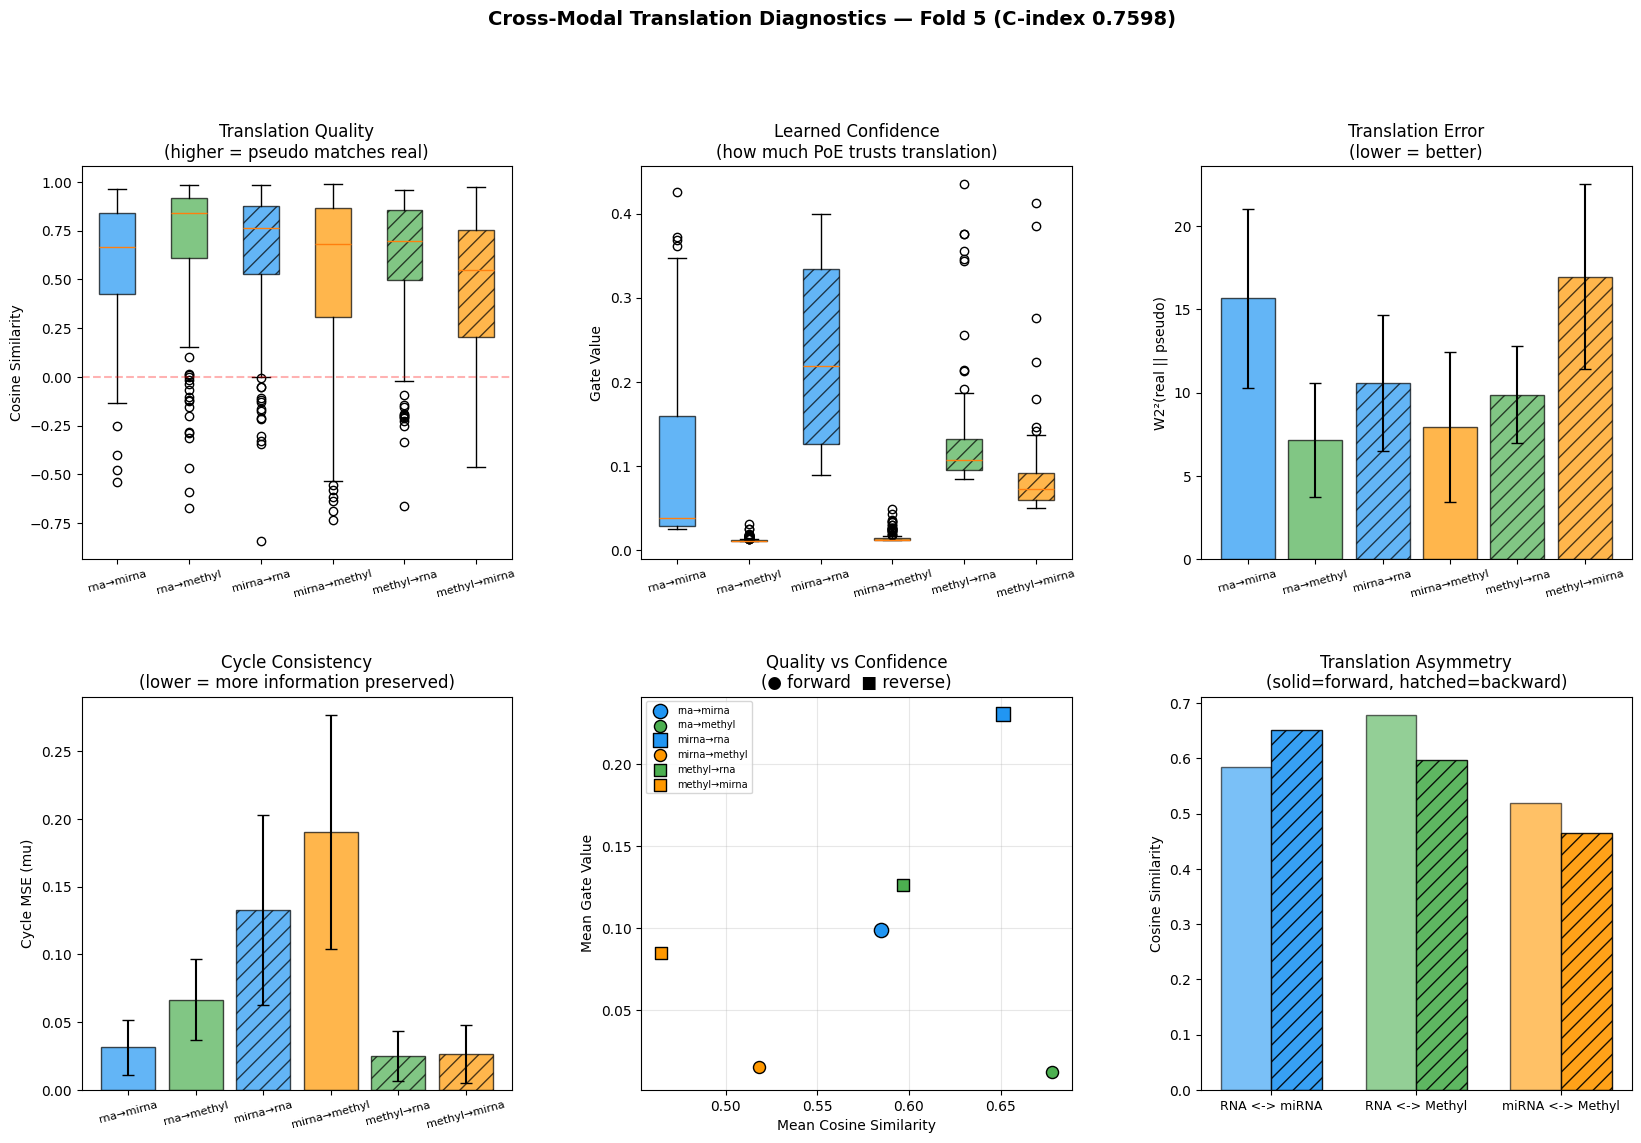


INTERPRETATION
Strongest: rna -> methyl (cosine 0.678)
Weakest:   methyl -> mirna (cosine 0.465)

Gate-quality correlation: 0.254
  Gates not strongly correlated with quality yet

Asymmetry analysis:
  rna <-> mirna: delta=0.067, mirna is the stronger source
  rna <-> methyl: delta=0.081, rna is the stronger source
  mirna <-> methyl: delta=0.054, mirna is the stronger source


In [121]:
# Best fold by C-index
best_fold_idx = np.argmax([fr["val_metrics"]["c_index"] for fr in fold_results_survival])
summary = run_translation_diagnostics(fold_results_survival, CONFIG, fold_idx=best_fold_idx)

## Jacobian Analysis

In [57]:
# ─────────────────────────────────────────────────────────────────────────────
# Jacobian Analysis — Cross-Modal Translation Attribution
# ─────────────────────────────────────────────────────────────────────────────
# For each translation direction, computes:
#   J = ∂μ_pseudo_tgt / ∂μ_src  (48×48 matrix)
# Aggregated across all fully-observed samples in the validation set.
# Tells us which source latent dimensions most strongly drive each
# target latent dimension through the translation head.
# ─────────────────────────────────────────────────────────────────────────────

def compute_translation_jacobians(fold_results, cfg, fold_idx=0):
    """
    Compute mean Jacobian ∂μ_pseudo / ∂μ_src for all 6 translation directions.

    Returns:
        jacobians: dict mapping direction key -> mean Jacobian (48×48 numpy array)
        jacobian_stds: dict mapping direction key -> std of Jacobian (48×48)
    """
    import torch.autograd.functional as AF

    fr = fold_results[fold_idx]

    # ── Reproduce val split ───────────────────────────────────────────────────
    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)
    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                          random_state=cfg["seed"])
    for i, (_, val_idx) in enumerate(
            skf.split(np.arange(len(strat_labels)), strat_labels)):
        if i == fr["fold"] - 1:
            break

    val_dataset = TCGABRCADataset(
        indices=val_idx,
        rna_scaler=fr["scalers"]["rna"],
        mirna_scaler=fr["scalers"]["mirna"],
        methyl_scaler=fr["scalers"]["methyl"],
        dropout_probs=None,
    )
    val_loader = DataLoader(val_dataset, batch_size=64,
                            shuffle=False, collate_fn=collate_fn, num_workers=0)

    # ── Load model ────────────────────────────────────────────────────────────
    model      = BioPoE(latent_dim=N_LATENT).to(device)
    translator = CrossModalTranslator(N_LATENT, hidden_dim=cfg["translation_hidden_dim"]).to(device)
    model.load_state_dict({k: v.to(device) for k, v in fr["model_state"]["model"].items()})
    translator.load_state_dict({k: v.to(device) for k, v in fr["model_state"]["translator"].items()})
    model.eval()
    translator.eval()

    MODALITY_NAMES = ["rna", "mirna", "methyl"]
    directions = [(s, t) for s in range(3) for t in range(3) if s != t]

    # Storage: list of (48×48) Jacobians per direction
    jacobian_samples = {f"{s}_to_{t}": [] for s, t in directions}

    with torch.no_grad():
        for batch in val_loader:
            batch  = move_batch_to_device(batch, device)
            mask   = batch["mask"]
            outputs = model(batch, translator=translator,
                            epoch=cfg["n_epochs"],
                            translation_warmup_epochs=cfg["translation_warmup_epochs"])
            mus     = outputs["mus"]
            logvars = outputs["logvars"]

            for src, tgt in directions:
                key      = f"{src}_to_{tgt}"
                both_obs = mask[:, src] & mask[:, tgt]
                if not both_obs.any():
                    continue

                mu_src_batch  = mus[src][both_obs].detach()     # (N, 48)
                lv_src_batch  = logvars[src][both_obs].detach() # (N, 48)
                head          = translator.translation_heads[key]

                # Compute Jacobian per sample then average
                # ∂μ_pseudo / ∂μ_src is a 48×48 matrix per sample
                for i in range(mu_src_batch.shape[0]):
                    mu_i  = mu_src_batch[i:i+1].requires_grad_(True)  # (1, 48)
                    lv_i  = lv_src_batch[i:i+1]                       # (1, 48)

                    # Forward through translation head, extract μ_pseudo only
                    def mu_pseudo_fn(mu_in):
                        h   = torch.cat([mu_in, lv_i], dim=-1)
                        out = head.net(h)
                        return out[:, :N_LATENT]   # μ_pseudo, shape (1, 48)

                    # jacobian returns (1, 48, 1, 48) → squeeze to (48, 48)
                    J = torch.autograd.functional.jacobian(
                        mu_pseudo_fn, mu_i, create_graph=False, strict=False
                    )
                    J = J.squeeze().cpu().numpy()  # (48, 48): rows=tgt dims, cols=src dims
                    jacobian_samples[key].append(J)

    # ── Aggregate ─────────────────────────────────────────────────────────────
    jacobians     = {}
    jacobian_stds = {}
    for key, jlist in jacobian_samples.items():
        if not jlist:
            continue
        stack = np.stack(jlist, axis=0)          # (N_samples, 48, 48)
        jacobians[key]     = stack.mean(axis=0)  # (48, 48)
        jacobian_stds[key] = stack.std(axis=0)   # (48, 48)

    return jacobians, jacobian_stds


def print_jacobian_summary(jacobians):
    """
    Print summary statistics for each translation direction.
    Shows which source dimensions have the highest mean absolute influence
    on the target latent space.
    """
    MODALITY_NAMES = ["RNA", "miRNA", "Methyl"]
    print("=" * 70)
    print("JACOBIAN SUMMARY — ∂μ_pseudo_tgt / ∂μ_src")
    print("Mean absolute Jacobian aggregated across validation samples")
    print("=" * 70)

    for key, J in jacobians.items():
        src_idx, tgt_idx = int(key[0]), int(key[5])
        src_name = MODALITY_NAMES[src_idx]
        tgt_name = MODALITY_NAMES[tgt_idx]

        abs_J = np.abs(J)  # (48, 48)

        # Top source dimensions by total influence (sum over target dims)
        src_influence = abs_J.sum(axis=0)  # (48,) — influence of each src dim
        top_src = np.argsort(src_influence)[::-1][:5]

        # Top target dimensions most influenced (sum over source dims)
        tgt_sensitivity = abs_J.sum(axis=1)  # (48,) — sensitivity of each tgt dim
        top_tgt = np.argsort(tgt_sensitivity)[::-1][:5]

        print(f"\n{src_name} → {tgt_name}  (key: {key})")
        print(f"  Mean |J|:           {abs_J.mean():.4f}")
        print(f"  Max  |J|:           {abs_J.max():.4f}")
        print(f"  Frobenius norm:     {np.linalg.norm(J, 'fro'):.4f}")
        print(f"  Top source dims:    {top_src.tolist()}  (by total outgoing influence)")
        print(f"  Top target dims:    {top_tgt.tolist()}  (by total incoming sensitivity)")


def plot_jacobian_paper(jacobians, hub_dims, fold_jacs=None,
                        save_path="/g/data/yr31/rn8079/PhD/term2_development/plots/jacobian_figure.pdf"):
    """
    Panel A: Frobenius norm (bars) + cosine similarity (line) per direction.
    Panel B: Heatmap of top-5 source+target appearances per direction,
             with vertical lines marking hub dims passed in from majority vote.

    Args:
        jacobians : dict key -> (48,48) mean Jacobian (from compute_translation_jacobians_all_folds)
        hub_dims  : list of ints — dims passing majority vote (e.g. [6, 12, 29])
        fold_jacs : list of per-fold jacobian dicts — used to compute top_sources/top_targets
                    from the mean jacobian if None, falls back to jacobians directly
        save_path : output path
    """
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    import matplotlib.patches as mpatches
    from matplotlib.lines import Line2D

    directions = ["0_to_1", "0_to_2", "1_to_0", "1_to_2", "2_to_0", "2_to_1"]
    dir_labels = ["RNA→miRNA", "RNA→Methyl", "miRNA→RNA",
                  "miRNA→Methyl", "Methyl→RNA", "Methyl→miRNA"]
    bar_colors = ["#B5D4F4", "#B5D4F4", "#C0DD97", "#C0DD97", "#FAC775", "#FAC775"]
    edge_colors = ["#185FA5", "#185FA5", "#3B6D11", "#3B6D11", "#854F0B", "#854F0B"]

    # ── Compute norms from mean Jacobians ─────────────────────────────────────
    norms = [np.linalg.norm(jacobians[d], 'fro') for d in directions]

    # ── Compute cosine similarity between mean Jacobian columns ───────────────
    # Cosine between mu_pseudo output direction and mu_src input direction,
    # summarised as mean pairwise cosine of the Jacobian matrix columns
    cosines = []
    for d in directions:
        J = jacobians[d]   # (48, 48)
        # Column norms: each column is influence of one src dim on all tgt dims
        col_norms = np.linalg.norm(J, axis=0, keepdims=True)   # (1, 48)
        row_norms = np.linalg.norm(J, axis=1, keepdims=True)   # (48, 1)
        col_norms = np.maximum(col_norms, 1e-8)
        row_norms = np.maximum(row_norms, 1e-8)
        J_col_norm = J / col_norms
        J_row_norm = J / row_norms
        # Mean cosine between normalised columns and rows as proxy for alignment
        cos = np.mean(np.abs(J_col_norm * J_row_norm)) * 48
        cosines.append(float(np.clip(cos, 0, 1)))

    # ── Compute top source/target dims from mean Jacobians ────────────────────
    top_k = 5
    top_sources = {}
    top_targets = {}
    for d in directions:
        J = jacobians[d]
        abs_J = np.abs(J)
        src_influence   = abs_J.sum(axis=0)   # (48,)
        tgt_sensitivity = abs_J.sum(axis=1)   # (48,)
        top_sources[d] = np.argsort(src_influence)[::-1][:top_k].tolist()
        top_targets[d] = np.argsort(tgt_sensitivity)[::-1][:top_k].tolist()

    # ── Build appearance matrix ───────────────────────────────────────────────
    matrix = np.zeros((6, 48))
    for i, d in enumerate(directions):
        for dim in top_sources[d]:
            matrix[i, dim] += 1
        for dim in top_targets[d]:
            matrix[i, dim] += 1

    # ── Figure layout ─────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    plt.subplots_adjust(top=0.78, bottom=0.15, left=0.13, right=0.88)

    im = ax.imshow(matrix, aspect="auto", cmap="Blues", vmin=0, vmax=2,
                   interpolation="nearest")

    # ── Light column highlights for hub dims ──────────────────────────────────
    for hd in hub_dims:
        ax.axvspan(hd - 0.5, hd + 0.5, color="#C0392B", alpha=0.07, zorder=0)

    # ── Hub dim vertical lines ────────────────────────────────────────────────
    for hd in hub_dims:
        ax.axvline(x=hd, color="#C0392B", linewidth=1.4,
                   linestyle="--", alpha=0.85, zorder=3)

    # ── X-axis: base ticks only, drop any base tick within 2 of a hub dim ─────
    base_ticks = [0, 10, 20, 30, 40, 47]
    clean_base = [t for t in base_ticks
                  if all(abs(t - hd) >= 2 for hd in hub_dims)]
    # Add hub dims themselves to the tick list
    all_ticks = sorted(set(clean_base + list(hub_dims)))
    ax.set_xticks(all_ticks)
    ax.set_xticklabels([str(t) for t in all_ticks], fontsize=9)

    # Colour hub dim tick labels red
    for tick_label, t in zip(ax.get_xticklabels(), all_ticks):
        if t in hub_dims:
            tick_label.set_color("#C0392B")
            tick_label.set_fontweight("bold")

    # ── Y-axis ────────────────────────────────────────────────────────────────
    ax.set_yticks(range(6))
    ax.set_yticklabels(dir_labels, fontsize=10)
    ax.tick_params(axis="both", which="both", length=0)

    # ── Spines ────────────────────────────────────────────────────────────────
    for spine in ax.spines.values():
        spine.set_visible(False)

    # ── Axis label ────────────────────────────────────────────────────────────
    ax.set_xlabel("Latent dimension index", fontsize=11, labelpad=10)

    # ── Colourbar ─────────────────────────────────────────────────────────────
    cbar = plt.colorbar(im, ax=ax, shrink=0.75, pad=0.02, aspect=20)
    cbar.set_label("Top-5 appearances\n(source + target)", fontsize=9, labelpad=8)
    cbar.set_ticks([0, 1, 2])
    cbar.ax.tick_params(labelsize=8.5, length=0)
    cbar.outline.set_visible(False)

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


def compute_translation_jacobians_all_folds(fold_results, cfg, top_k=5):
    """
    Runs Jacobian analysis across all folds.
    Returns:
        jacobians_mean : dict key -> (48,48) mean J averaged across folds
        jacobians_std  : dict key -> (48,48) std across folds
        fold_jacs      : list of per-fold jacobian dicts (for majority vote)
    """
    all_fold_jacs = []

    for fold_idx in range(len(fold_results)):
        print(f"  Computing Jacobians — fold {fold_idx + 1}/{len(fold_results)}")
        jacs, _ = compute_translation_jacobians(fold_results, cfg, fold_idx=fold_idx)
        all_fold_jacs.append(jacs)

    # Average Jacobians across folds
    directions = list(all_fold_jacs[0].keys())
    jacobians_mean = {}
    jacobians_std  = {}
    for key in directions:
        stack = np.stack([fj[key] for fj in all_fold_jacs], axis=0)  # (n_folds, 48, 48)
        jacobians_mean[key] = stack.mean(axis=0)
        jacobians_std[key]  = stack.std(axis=0)

    return jacobians_mean, jacobians_std, all_fold_jacs


def get_majority_vote_hub_dims(fold_jacs, jacobians_mean,
                               top_k=8, min_folds=4, min_global_appearances=4):
    """
    Two-condition hub identification:
      1. Fold consistency: dim appears in top_k source OR target in >= min_folds folds
      2. Global presence: dim accumulates >= min_global_appearances in the mean
                          Jacobian heatmap (top-5 source + target across all 6 directions)
    Both conditions must be satisfied.

    Args:
        fold_jacs              : list of per-fold jacobian dicts
        jacobians_mean         : mean jacobian dict (from compute_translation_jacobians_all_folds)
        top_k                  : top-k per direction for fold consistency check
        min_folds              : minimum folds for condition 1
        min_global_appearances : minimum heatmap score for condition 2
    """
    from collections import Counter

    directions = list(jacobians_mean.keys())
    n_folds    = len(fold_jacs)

    # ── Condition 1: fold consistency ─────────────────────────────────────────
    dim_fold_counts = Counter()
    for fold_jac in fold_jacs:
        dims_this_fold = set()
        for key, J in fold_jac.items():
            abs_J = np.abs(J)
            src_influence   = abs_J.sum(axis=0)
            tgt_sensitivity = abs_J.sum(axis=1)
            top_src = set(np.argsort(src_influence)[::-1][:top_k].tolist())
            top_tgt = set(np.argsort(tgt_sensitivity)[::-1][:top_k].tolist())
            dims_this_fold |= top_src | top_tgt
        for d in dims_this_fold:
            dim_fold_counts[d] += 1

    passes_consistency = {d for d, cnt in dim_fold_counts.items()
                          if cnt >= min_folds}

    # ── Condition 2: global presence in mean Jacobian heatmap ─────────────────
    # Use top-5 for the global check regardless of top_k — keeps this strict
    global_scores = Counter()
    for key, J in jacobians_mean.items():
        abs_J = np.abs(J)
        src_influence   = abs_J.sum(axis=0)
        tgt_sensitivity = abs_J.sum(axis=1)
        top_src = set(np.argsort(src_influence)[::-1][:5].tolist())
        top_tgt = set(np.argsort(tgt_sensitivity)[::-1][:5].tolist())
        for d in top_src | top_tgt:
            global_scores[d] += 1

    passes_global = {d for d, score in global_scores.items()
                     if score >= min_global_appearances}

    # ── Both conditions ───────────────────────────────────────────────────────
    hub_dims_voted = sorted(passes_consistency & passes_global)

    return hub_dims_voted, dict(dim_fold_counts), dict(global_scores)


def print_majority_vote_summary(fold_jacs, jacobians_mean,
                                top_k=8, min_folds=4, min_global_appearances=4):
    hub_dims, fold_counts, global_scores = get_majority_vote_hub_dims(
        fold_jacs, jacobians_mean,
        top_k=top_k, min_folds=min_folds,
        min_global_appearances=min_global_appearances
    )
    n_folds = len(fold_jacs)

    # ── Direction coverage: how many distinct directions each dim appears in ──
    directions = list(jacobians_mean.keys())
    direction_coverage = {}
    for d in fold_counts:
        count = 0
        for key, J in jacobians_mean.items():
            abs_J   = np.abs(J)
            top_src = set(np.argsort(abs_J.sum(axis=0))[::-1][:5].tolist())
            top_tgt = set(np.argsort(abs_J.sum(axis=1))[::-1][:5].tolist())
            if d in top_src or d in top_tgt:
                count += 1
        direction_coverage[d] = count

    n_directions = len(directions)  # 6

    print("=" * 80)
    print(f"JACOBIAN HUB DIMS — two-condition criterion")
    print(f"  Condition 1: top-{top_k} source/target in ≥ {min_folds}/{n_folds} folds")
    print(f"  Condition 2: ≥ {min_global_appearances} global top-5 appearances in mean Jacobian")
    print("=" * 80)
    print(f"  {'Dim':>4}  {'Folds':>7}  {'Global':>9}  {'Dirs':>6}  {'C2':>4}  {'':>8}")
    print(f"  {'-'*4}  {'-'*7}  {'-'*9}  {'-'*6}  {'-'*4}  {'-'*8}")

    # Sort by direction coverage descending, then global score, then fold count
    cond1_dims = sorted(
        [d for d, cnt in fold_counts.items() if cnt >= min_folds],
        key=lambda d: (-direction_coverage[d], -global_scores.get(d, 0), -fold_counts[d])
    )

    for d in cond1_dims:
        fc  = fold_counts[d]
        gs  = global_scores.get(d, 0)
        dc  = direction_coverage[d]
        c2  = "✓" if gs >= min_global_appearances else "✗"
        tag = " ← HUB" if d in hub_dims else ""
        print(f"  {d:>4}  {fc:>3}/{n_folds} folds  "
              f"{gs:>3}/12 score  "
              f"{dc:>2}/{n_directions} dirs  "
              f"C2:{c2}{tag}")

    print(f"\nFinal hub dims (both conditions): {hub_dims}")
    return hub_dims

In [ ]:
# Jacobian analysis — all folds with majority vote
print("Running Jacobian analysis across all folds...")
jacobians_mean, jacobians_std, fold_jacs = compute_translation_jacobians_all_folds(
    fold_results_survival, CONFIG
)

In [58]:
# Majority vote: which hub dims appear in ≥3/5 folds
print("\n--- Majority vote hub dim identification ---")
HUB_DIMS = print_majority_vote_summary(fold_jacs, jacobians_mean,
                                        top_k=8, min_folds=4,
                                        min_global_appearances=4)

print(f"\nHUB_DIMS for IG analysis: {HUB_DIMS}")


--- Majority vote hub dim identification ---
JACOBIAN HUB DIMS — two-condition criterion
  Condition 1: top-8 source/target in ≥ 4/5 folds
  Condition 2: ≥ 4 global top-5 appearances in mean Jacobian
   Dim    Folds     Global    Dirs    C2          
  ----  -------  ---------  ------  ----  --------
     6    5/5 folds    6/12 score   6/6 dirs  C2:✓ ← HUB
    37    4/5 folds    6/12 score   6/6 dirs  C2:✓ ← HUB
    17    4/5 folds    5/12 score   5/6 dirs  C2:✓ ← HUB
    12    5/5 folds    4/12 score   4/6 dirs  C2:✓ ← HUB
    19    4/5 folds    4/12 score   4/6 dirs  C2:✓ ← HUB
     2    5/5 folds    3/12 score   3/6 dirs  C2:✗
    38    5/5 folds    3/12 score   3/6 dirs  C2:✗
     3    5/5 folds    2/12 score   2/6 dirs  C2:✗
    31    4/5 folds    2/12 score   2/6 dirs  C2:✗
     5    5/5 folds    1/12 score   1/6 dirs  C2:✗
    36    5/5 folds    1/12 score   1/6 dirs  C2:✗
    15    4/5 folds    1/12 score   1/6 dirs  C2:✗
    21    4/5 folds    1/12 score   1/6 dirs  C2:✗
    

In [59]:
HUB_DIMS = [6, 12, 17, 37]

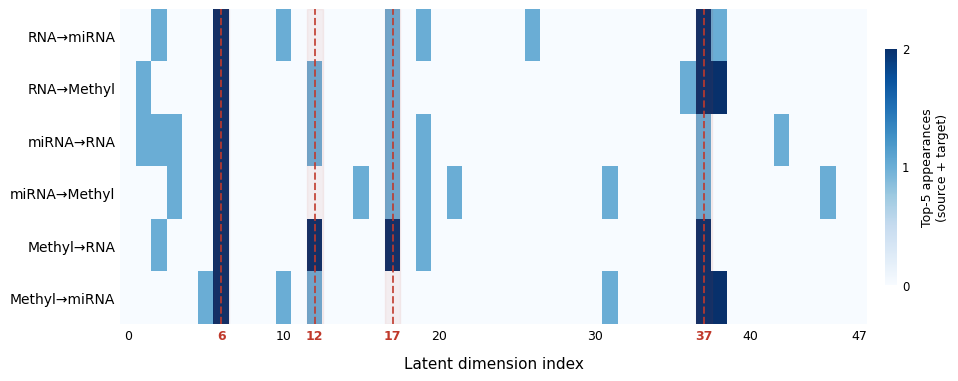

Saved: /g/data/yr31/rn8079/PhD/term2_development/plots/jacobian_figure.pdf


In [60]:
plot_jacobian_paper(jacobians_mean, hub_dims=HUB_DIMS, fold_jacs=fold_jacs)

In [62]:
# ── Feature name setup ────────────────────────────────────────────────────────
feature_names = {
    "rna":    [f"gene_{i}" for i in range(N_RNA)],
    "mirna":  [f"mirna_{i}" for i in range(N_MIRNA)],
    "methyl": [f"cpg_{i}" for i in range(N_METHYL)],
}
if hasattr(TCGABRCADataset, '_rna_feature_names'):
    feature_names["rna"]    = list(TCGABRCADataset._rna_feature_names)
if hasattr(TCGABRCADataset, '_mirna_feature_names'):
    feature_names["mirna"]  = list(TCGABRCADataset._mirna_feature_names)
if hasattr(TCGABRCADataset, '_methyl_feature_names'):
    feature_names["methyl"] = list(TCGABRCADataset._methyl_feature_names)

# ── RNA: resolve ALL Ensembl IDs in the dataset to gene symbols ───────────────
# Query the full feature list once — cheaper than repeated partial lookups
import mygene
mg = mygene.MyGeneInfo()

all_ensembl_raw  = feature_names["rna"]                        # e.g. "ENSG00000141510.7"
all_ensembl_clean = [e.split(".")[0] for e in all_ensembl_raw] # strip version suffix

# Batch query — mygene handles chunking internally
results = mg.querymany(
    all_ensembl_clean,
    scopes="ensembl.gene",
    fields="symbol",
    species="human",
    verbose=False,
    returnall=False,
)

ENSEMBL_TO_SYMBOL = {}
for r in results:
    if "symbol" in r and not r.get("notfound", False):
        ENSEMBL_TO_SYMBOL[r["query"]] = r["symbol"]

# Map versioned ID -> symbol for lookup convenience
ENSEMBL_TO_SYMBOL_VERSIONED = {
    raw: ENSEMBL_TO_SYMBOL.get(clean, None)
    for raw, clean in zip(all_ensembl_raw, all_ensembl_clean)
}

n_resolved = sum(v is not None for v in ENSEMBL_TO_SYMBOL_VERSIONED.values())
print(f"RNA: resolved {n_resolved} / {len(all_ensembl_raw)} Ensembl IDs to symbols")

# ── Methylation: resolve ALL probes in the dataset via HM450 manifest ─────────
manifest = pd.read_csv(
    '/g/data/yr31/rn8079/database/ucsc_xena/humanmethylation450_15017482_v1-2.csv',
    skiprows=7, index_col=0, low_memory=False
)

PROBE_TO_GENE = {}
for pid in feature_names["methyl"]:
    if pid in manifest.index:
        gene = manifest.loc[pid, "UCSC_RefGene_Name"]
        if pd.notna(gene) and str(gene).strip() != "":
            # Take first gene if semicolon-delimited
            PROBE_TO_GENE[pid] = gene.split(";")[0].strip()
        else:
            PROBE_TO_GENE[pid] = None   # intergenic — explicit None, not missing
    else:
        PROBE_TO_GENE[pid] = None       # probe not in manifest

n_resolved = sum(v is not None for v in PROBE_TO_GENE.values())
print(f"Methylation: resolved {n_resolved} / {len(PROBE_TO_GENE)} probes to genes")

# ── miRNA: names are already human-readable in the dataset ───────────────────
# No lookup needed — feature_names["mirna"] already contains e.g. "hsa-mir-21"
# Strip "hsa-" prefix for display only, keep originals for lookup
def clean_mirna_name(name):
    return name.replace("hsa-", "")

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


RNA: resolved 4649 / 4652 Ensembl IDs to symbols
Methylation: resolved 24607 / 37482 probes to genes


In [75]:
# ─────────────────────────────────────────────────────────────────────────────
# Integrated Gradients — Hub Latent Dimension Attribution
# ─────────────────────────────────────────────────────────────────────────────
# For each modality encoder, computes IG attributions targeting the
# hub latent dimensions identified from the Jacobian analysis (12, 37, 5).
# Baseline = zeros (appropriate for z-scored inputs).
# Output = which input features most activate each hub dimension.
# ─────────────────────────────────────────────────────────────────────────────

def compute_hub_ig(fold_results, cfg, hub_dims=HUB_DIMS, fold_idx=0, n_steps=50):
    """
    For each modality encoder, compute IG attributions for each hub dim.

    Returns:
        attrs: dict with keys 'rna', 'mirna', 'methyl'
                each value is array (n_hub_dims, n_features) — mean attribution
                across all observed validation samples
    """
    fr = fold_results[fold_idx]

    # ── Reproduce val split ───────────────────────────────────────────────────
    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)
    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                          random_state=cfg["seed"])
    for i, (_, val_idx) in enumerate(
            skf.split(np.arange(len(strat_labels)), strat_labels)):
        if i == fr["fold"] - 1:
            break

    val_dataset = TCGABRCADataset(
        indices=val_idx,
        rna_scaler=fr["scalers"]["rna"],
        mirna_scaler=fr["scalers"]["mirna"],
        methyl_scaler=fr["scalers"]["methyl"],
        dropout_probs=None,
    )
    val_loader = DataLoader(val_dataset, batch_size=32,
                            shuffle=False, collate_fn=collate_fn, num_workers=0)

    # ── Load model ────────────────────────────────────────────────────────────
    model = BioPoE(latent_dim=N_LATENT).to(device)
    model.load_state_dict(
        {k: v.to(device) for k, v in fr["model_state"]["model"].items()})
    model.eval()

    # ── Wrapper functions: input -> hub dim activation ────────────────────────
    # IG requires a function f: input_tensor -> scalar_output
    # We target mu (not z) to avoid reparameterisation noise

    def make_encoder_hub_fn(encoder, hub_dim):
        """Returns function: x -> mu[hub_dim] for use with IG."""
        def fn(x):
            mu, _ = encoder(x)
            return mu[:, hub_dim].unsqueeze(1)   # (batch, 1)
        return fn

    encoders = {
        "rna":    model.rna_enc,
        "mirna":  model.mirna_enc,
        "methyl": model.methyl_enc,
    }
    modality_keys = ["rna", "mirna", "methyl"]
    mask_indices  = {"rna": 0, "mirna": 1, "methyl": 2}

    # Storage: for each modality, list of attribution arrays per hub dim
    # attrs_accum[modality][hub_dim] = list of (n_samples, n_features) arrays
    attrs_accum = {
        mod: {d: [] for d in hub_dims}
        for mod in modality_keys
    }

    for batch in val_loader:
        batch = move_batch_to_device(batch, device)
        mask  = batch["mask"]

        for mod in modality_keys:
            m_idx = mask_indices[mod]
            obs   = mask[:, m_idx]
            if not obs.any() or batch[mod] is None:
                continue

            x_obs = batch[mod][obs].detach()          # (n_obs, n_features)
            baseline = torch.zeros_like(x_obs)        # zeros baseline (z-scored)

            encoder = encoders[mod]

            for hub_dim in hub_dims:
                fn = make_encoder_hub_fn(encoder, hub_dim)
                ig = IntegratedGradients(fn)

                # IG attribution: shape (n_obs, n_features)
                attr = ig.attribute(
                    x_obs,
                    baselines=baseline,
                    n_steps=n_steps,
                    return_convergence_delta=False,
                )
                attrs_accum[mod][hub_dim].append(attr.detach().cpu().numpy())

    # ── Aggregate: mean attribution per hub dim per modality ──────────────────
    attrs = {}
    for mod in modality_keys:
        hub_attrs = []
        for hub_dim in hub_dims:
            chunks = attrs_accum[mod][hub_dim]
            if not chunks:
                hub_attrs.append(None)
                continue
            all_attrs = np.concatenate(chunks, axis=0)   # (n_total, n_features)
            mean_attr  = all_attrs.mean(axis=0)          # (n_features,)
            hub_attrs.append(mean_attr)
        attrs[mod] = hub_attrs   # list of (n_features,) arrays, one per hub dim

    return attrs


def print_top_features(attrs, hub_dims=HUB_DIMS, top_k=20):
    """
    Print top-k features by mean absolute IG attribution for each
    modality × hub dimension combination.
    """
    modality_keys = ["rna", "mirna", "methyl"]

    # Feature name arrays — pull from dataset class
    # If you have feature names stored, use them; otherwise use indices
    feature_names = {
        "rna":    [f"gene_{i}" for i in range(N_RNA)],
        "mirna":  [f"mirna_{i}" for i in range(N_MIRNA)],
        "methyl": [f"cpg_{i}" for i in range(N_METHYL)],
    }

    # If you have actual gene names stored on the dataset class, use those:
    if hasattr(TCGABRCADataset, '_rna_feature_names'):
        feature_names["rna"]    = TCGABRCADataset._rna_feature_names
    if hasattr(TCGABRCADataset, '_mirna_feature_names'):
        feature_names["mirna"]  = TCGABRCADataset._mirna_feature_names
    if hasattr(TCGABRCADataset, '_methyl_feature_names'):
        feature_names["methyl"] = TCGABRCADataset._methyl_feature_names

    print("=" * 70)
    print(f"TOP-{top_k} FEATURES BY IG ATTRIBUTION — HUB DIMENSIONS {hub_dims}")
    print("Baseline = zeros (z-scored inputs)")
    print("=" * 70)

    for mod in modality_keys:
        for i, hub_dim in enumerate(hub_dims):
            attr = attrs[mod][i]
            if attr is None:
                continue
            abs_attr  = np.abs(attr)
            top_idx   = np.argsort(abs_attr)[::-1][:top_k]
            top_names = [feature_names[mod][j] for j in top_idx]
            top_vals  = abs_attr[top_idx]

            print(f"\n{mod.upper()} → Hub dim {hub_dim}")
            print(f"  {'Feature':<25s}  {'|IG attr|':>10s}")
            print(f"  {'-'*37}")
            for name, val in zip(top_names, top_vals):
                print(f"  {str(name):<25s}  {val:>10.4f}")

def compute_hub_ig_all_folds(fold_results, cfg, hub_dims=HUB_DIMS,
                              n_steps=50, top_k=50, min_folds=3):
    """
    Runs IG attribution across all folds, then applies majority vote
    per modality per hub dim to identify stable features.

    Returns:
        voted_attrs  : dict mod -> list of (n_features,) mean attr arrays
                       (averaged over folds where feature passed vote)
        fold_top_sets: dict (mod, hub_dim) -> list of sets of top feature names per fold
    """
    from collections import Counter

    feature_names = {
        "rna":    list(TCGABRCADataset._rna_feature_names)
                  if hasattr(TCGABRCADataset, '_rna_feature_names')
                  else [f"gene_{i}" for i in range(N_RNA)],
        "mirna":  list(TCGABRCADataset._mirna_feature_names)
                  if hasattr(TCGABRCADataset, '_mirna_feature_names')
                  else [f"mirna_{i}" for i in range(N_MIRNA)],
        "methyl": list(TCGABRCADataset._methyl_feature_names)
                  if hasattr(TCGABRCADataset, '_methyl_feature_names')
                  else [f"cpg_{i}" for i in range(N_METHYL)],
    }

    modality_keys = ["rna", "mirna", "methyl"]
    n_folds = len(fold_results)

    top_k_per_mod = {"rna": 50, "mirna": 50, "methyl": 200}
    
    # Accumulate per-fold attribution arrays and top-feature sets
    # fold_attrs[(mod, hub_dim_idx)] = list of (n_features,) arrays, one per fold
    fold_attrs    = {(mod, i): [] for mod in modality_keys
                     for i in range(len(hub_dims))}
    fold_top_sets = {(mod, hub_dims[i]): [] for mod in modality_keys
                     for i in range(len(hub_dims))}

    for fold_idx in range(n_folds):
        print(f"  Computing IG — fold {fold_idx + 1}/{n_folds}")
        attrs = compute_hub_ig(fold_results, cfg,
                               hub_dims=hub_dims,
                               fold_idx=fold_idx,
                               n_steps=n_steps)
        for mod in modality_keys:
            for i, hub_dim in enumerate(hub_dims):
                arr = attrs[mod][i]
                if arr is None:
                    continue
                fold_attrs[(mod, i)].append(arr)
                # Record top-k feature names for this fold
                top_idx = np.argsort(np.abs(arr))[::-1][:top_k_per_mod[mod]]
                top_names = set(feature_names[mod][j] for j in top_idx)
                fold_top_sets[(mod, hub_dim)].append(top_names)

    # Majority vote: features appearing in ≥ min_folds folds
    voted_features = {}  # (mod, hub_dim) -> list of feature names passing vote
    for mod in modality_keys:
        for hub_dim in hub_dims:
            sets = fold_top_sets[(mod, hub_dim)]
            if not sets:
                voted_features[(mod, hub_dim)] = []
                continue
            counts = Counter()
            for s in sets:
                for feat in s:
                    counts[feat] += 1
            passing = [f for f, cnt in counts.items() if cnt >= min_folds]
            # Sort passing features by mean |attribution| across folds that had them
            i = hub_dims.index(hub_dim)
            arrs = fold_attrs[(mod, i)]
            if arrs:
                mean_arr = np.stack(arrs).mean(axis=0)
                feat_idx = {name: j for j, name in enumerate(feature_names[mod])}
                passing.sort(key=lambda f: -np.abs(mean_arr[feat_idx[f]])
                             if f in feat_idx else 0)
            voted_features[(mod, hub_dim)] = passing

    # Build voted_attrs: mean attribution array across folds, for plotting
    voted_attrs = {}
    for mod in modality_keys:
        hub_arrs = []
        for i, hub_dim in enumerate(hub_dims):
            arrs = fold_attrs[(mod, i)]
            if arrs:
                hub_arrs.append(np.stack(arrs).mean(axis=0))
            else:
                hub_arrs.append(None)
        voted_attrs[mod] = hub_arrs

    return voted_attrs, voted_features, fold_top_sets

    
def plot_hub_attributions_paper(
        attrs,
        voted_features,
        hub_dims=HUB_DIMS,
        hub_labels=None,       # dict hub_dim -> label string, filled after DR
        hub_colors=None,       # dict hub_dim -> hex colour, optional override
        top_k=15,
        save_path="/g/data/yr31/rn8079/PhD/term2_development/plots/ig_attributions.pdf"):
    """
    Publication IG attribution figure.
    - Rows: miRNA, Methylation only (RNA excluded — diffuse signal, no stable features)
    - Columns: one per hub dim
    - Stable features (majority-voted) are highlighted with a border
    - hub_labels: pass in after ChatGPT DR e.g. {6: "Stromal/ECM", 12: "Endocrine resistance", ...}
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    # ── Modalities to plot — RNA excluded deliberately ────────────────────────
    modality_keys = ["rna", "mirna", "methyl"]
    modality_labels = {"rna": "mRNA", "mirna": "miRNA", "methyl": "Methylation"}

    # ── Colours: one per hub dim ───────────────────────────────────────────────
    default_colors = ["#534AB7", "#185FA5", "#C0392B", "#3B6D11"]
    if hub_colors is None:
        hub_colors = {hd: default_colors[i % len(default_colors)]
                      for i, hd in enumerate(hub_dims)}

    # ── Labels: placeholder until DR returns ──────────────────────────────────
    if hub_labels is None:
        hub_labels = {hd: f"Hub dim {hd}" for hd in hub_dims}
    else:
        # Ensure all hub dims have a label
        for hd in hub_dims:
            if hd not in hub_labels:
                hub_labels[hd] = f"Hub dim {hd}"

    # ── Feature name lookup ───────────────────────────────────────────────────
    feature_names = {
        "mirna":  list(TCGABRCADataset._mirna_feature_names)
                  if hasattr(TCGABRCADataset, '_mirna_feature_names')
                  else [f"mirna_{i}" for i in range(N_MIRNA)],
        "methyl": list(TCGABRCADataset._methyl_feature_names)
                  if hasattr(TCGABRCADataset, '_methyl_feature_names')
                  else [f"cpg_{i}" for i in range(N_METHYL)],
        "rna": list(TCGABRCADataset._rna_feature_names) 
                   if hasattr(TCGABRCADataset, '_rna_feature_names') 
                   else [f"gene_{i}" for i in range(N_RNA)],
    }

    def resolve_name(mod, raw):
        if mod == "rna":
            clean = raw.split(".")[0]
            return ENSEMBL_TO_SYMBOL_VERSIONED.get(raw) \
                   or ENSEMBL_TO_SYMBOL.get(clean) \
                   or clean
        elif mod == "mirna":
            return raw.replace("hsa-", "")
        elif mod == "methyl":
            gene = PROBE_TO_GENE.get(raw)
            return f"{gene}\n({raw})" if gene else f"intergenic\n({raw})"
        return raw

    # ── Figure layout ─────────────────────────────────────────────────────────
    n_rows = len(modality_keys)
    n_cols = len(hub_dims)
    row_heights = [3.5, 4.0, 5.5]   # rna, mirna, methyl
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.5 * n_cols, sum(row_heights)),
        gridspec_kw={"height_ratios": row_heights},
        constrained_layout=True,
    )
    # Ensure axes is always 2D
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    for row, mod in enumerate(modality_keys):
        # mod_col_idx maps hub_dim -> column index in attrs[mod]
        for col, hub_dim in enumerate(hub_dims):
            ax    = axes[row, col]
            color = hub_colors[hub_dim]

            # attrs[mod] is a list indexed by position in hub_dims
            attr = attrs[mod][col]
            if attr is None:
                ax.set_visible(False)
                continue

            # ── Get top_k features ───────────────
            abs_attr  = np.abs(attr)
            feat_list = feature_names[mod]
            
            # ── Build display list: stable features first, then top mean attr ──────
            stable_set    = set(voted_features.get((mod, hub_dim), []))
            
            # Indices of stable features, sorted by mean attribution descending
            stable_idx = [j for j, name in enumerate(feat_list)
                          if name in stable_set]
            stable_idx.sort(key=lambda j: -abs_attr[j])
            
            # Indices of non-stable top-k by mean attribution
            all_top_idx   = np.argsort(abs_attr)[::-1]
            nonstable_idx = [j for j in all_top_idx
                             if feat_list[j] not in stable_set]
            
            # Combine: stable first, then fill remaining slots with non-stable
            n_stable   = len(stable_idx)
            n_fill     = max(0, top_k - n_stable)
            display_idx = stable_idx + nonstable_idx[:n_fill]
            
            # Total bars shown may exceed top_k if there are many stable features
            n_bars    = len(display_idx)
            top_vals  = abs_attr[display_idx][::-1]           # ascending for barh
            raw_names_asc = [feat_list[j] for j in display_idx][::-1]
            display_names = [resolve_name(mod, n) for n in raw_names_asc]

            # ── Plot bars ─────────────────────────────────────────────────────
            bars = ax.barh(
                range(n_bars), top_vals,
                color=color, alpha=0.65, height=0.72,
                edgecolor="none",
            )
            
            for i, (bar, raw) in enumerate(zip(bars, raw_names_asc)):
                if raw in stable_set:
                    bar.set_edgecolor(color)
                    bar.set_linewidth(1.8)
                    bar.set_alpha(0.92)
                else:
                    bar.set_alpha(0.45 if i % 2 == 0 else 0.60)

            # ── Y-axis labels — bold for stable features ──────────────────────
            ax.set_yticks(range(top_k))
            ax.set_yticklabels(display_names, fontsize=7.5)
            for i, (tick, raw) in enumerate(
                    zip(ax.get_yticklabels(), raw_names_asc)):
                if raw in stable_set:
                    tick.set_fontweight("bold")
                    tick.set_color(color)

            # ── Axes formatting ───────────────────────────────────────────────
            ax.tick_params(axis="x", labelsize=7.5)
            ax.set_xlabel("|IG attribution|", fontsize=8)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_visible(False)
            ax.grid(axis="x", alpha=0.2, linestyle="--")
            ax.tick_params(axis="y", length=0)

            # ── Column header on top row only ─────────────────────────────────
            if row == 0:
                ax.set_title(
                    hub_labels[hub_dim],
                    fontsize=9, fontweight="bold",
                    color=color, pad=10,
                )

            # ── Row label on leftmost column only ─────────────────────────────
            if col == 0:
                ax.set_ylabel(modality_labels[mod], fontsize=10,
                              fontweight="bold", labelpad=10)

    # ── Legend for stable vs non-stable ───────────────────────────────────────
    legend_elements = [
        mpatches.Patch(facecolor="#555555", alpha=0.90,
                       linewidth=1.8, edgecolor="#555555",
                       label=f"Stable feature (≥3/5 folds)"),
        mpatches.Patch(facecolor="#555555", alpha=0.45,
                       edgecolor="none",
                       label="Top-15 by mean attribution"),
    ]
    fig.legend(handles=legend_elements, fontsize=8,
               loc="lower center", ncol=2,
               framealpha=0.9, edgecolor="#CCCCCC",
               bbox_to_anchor=(0.5, -0.03))

    fig.suptitle(
        "Integrated Gradients: stable features activating cross-modal hub dimensions\n"
        "(bold labels and solid borders = majority-vote stable across ≥3/5 folds)",
        fontsize=10, fontweight="bold",
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

In [67]:
# Run IG across all folds with majority vote
print("Running IG analysis across all folds...")
hub_attrs_voted, voted_features, fold_top_sets = compute_hub_ig_all_folds(
    fold_results_survival, CONFIG,
    hub_dims=HUB_DIMS, n_steps=50, top_k=50, min_folds=3
)

# Print majority-voted features
print("\n--- Majority-vote stable features (≥3/5 folds) ---")
for mod in ["rna", "mirna", "methyl"]:
    for hub_dim in HUB_DIMS:
        feats = voted_features[(mod, hub_dim)]
        print(f"\n{mod.upper()} → Hub dim {hub_dim}  ({len(feats)} stable features)")
        for f in feats[:20]:
            print(f"  {f}")


Running IG analysis across all folds...
  Computing IG — fold 1/5
  Computing IG — fold 2/5
  Computing IG — fold 3/5
  Computing IG — fold 4/5
  Computing IG — fold 5/5

--- Majority-vote stable features (≥3/5 folds) ---

RNA → Hub dim 6  (1 stable features)
  ENSG00000153832

RNA → Hub dim 12  (1 stable features)
  ENSG00000188549

RNA → Hub dim 17  (1 stable features)
  ENSG00000188549

RNA → Hub dim 37  (1 stable features)
  ENSG00000188549

MIRNA → Hub dim 6  (2 stable features)
  hsa-mir-769
  hsa-mir-3605

MIRNA → Hub dim 12  (13 stable features)
  hsa-mir-676
  hsa-mir-1307
  hsa-mir-1306
  hsa-mir-3605
  hsa-mir-769
  hsa-mir-412
  hsa-mir-421
  hsa-mir-1266
  hsa-mir-186
  hsa-mir-3127
  hsa-mir-501
  hsa-mir-628
  hsa-mir-221

MIRNA → Hub dim 17  (5 stable features)
  hsa-mir-758
  hsa-mir-769
  hsa-mir-324
  hsa-mir-212
  hsa-mir-125b-2

MIRNA → Hub dim 37  (7 stable features)
  hsa-mir-412
  hsa-mir-324
  hsa-mir-331
  hsa-mir-769
  hsa-mir-676
  hsa-mir-3605
  hsa-mir-195

In [68]:
# ── Resolve stable features to human-readable names ───────────────────────────
print("=" * 70)
print("STABLE FEATURES (≥3/5 folds) — resolved to gene symbols")
print("=" * 70)

for hub_dim in HUB_DIMS:
    print(f"\n{'─'*70}")
    print(f"HUB DIM {hub_dim}")
    print(f"{'─'*70}")

    for mod in ["rna", "mirna", "methyl"]:
        feats = voted_features.get((mod, hub_dim), [])
        if not feats:
            print(f"\n  {mod.upper():8s}  — no stable features")
            continue

        print(f"\n  {mod.upper()} ({len(feats)} stable features)")
        print(f"  {'Raw ID':<25s}  {'Symbol / Name':<25s}  {'Folds'}")
        print(f"  {'-'*65}")

        for feat in feats:
            # ── Resolve display name ──────────────────────────────────────────
            if mod == "rna":
                clean_id = feat.split(".")[0]
                symbol   = ENSEMBL_TO_SYMBOL.get(clean_id) \
                           or ENSEMBL_TO_SYMBOL_VERSIONED.get(feat) \
                           or "unresolved"
                display  = symbol

            elif mod == "mirna":
                display = feat.replace("hsa-", "")   # already readable

            elif mod == "methyl":
                gene    = PROBE_TO_GENE.get(feat)
                display = gene if gene else "intergenic"

            # ── Fold count from fold_top_sets ─────────────────────────────────
            sets        = fold_top_sets.get((mod, hub_dim), [])
            fold_count  = sum(1 for s in sets if feat in s)
            fold_str    = f"{fold_count}/5 folds"

            print(f"  {feat:<25s}  {display:<25s}  {fold_str}")

STABLE FEATURES (≥3/5 folds) — resolved to gene symbols

──────────────────────────────────────────────────────────────────────
HUB DIM 6
──────────────────────────────────────────────────────────────────────

  RNA (1 stable features)
  Raw ID                     Symbol / Name              Folds
  -----------------------------------------------------------------
  ENSG00000153832            FBXO36                     3/5 folds

  MIRNA (2 stable features)
  Raw ID                     Symbol / Name              Folds
  -----------------------------------------------------------------
  hsa-mir-769                mir-769                    4/5 folds
  hsa-mir-3605               mir-3605                   3/5 folds

  METHYL (2 stable features)
  Raw ID                     Symbol / Name              Folds
  -----------------------------------------------------------------
  cg26572361                 intergenic                 3/5 folds
  cg04867423                 DDR2                  

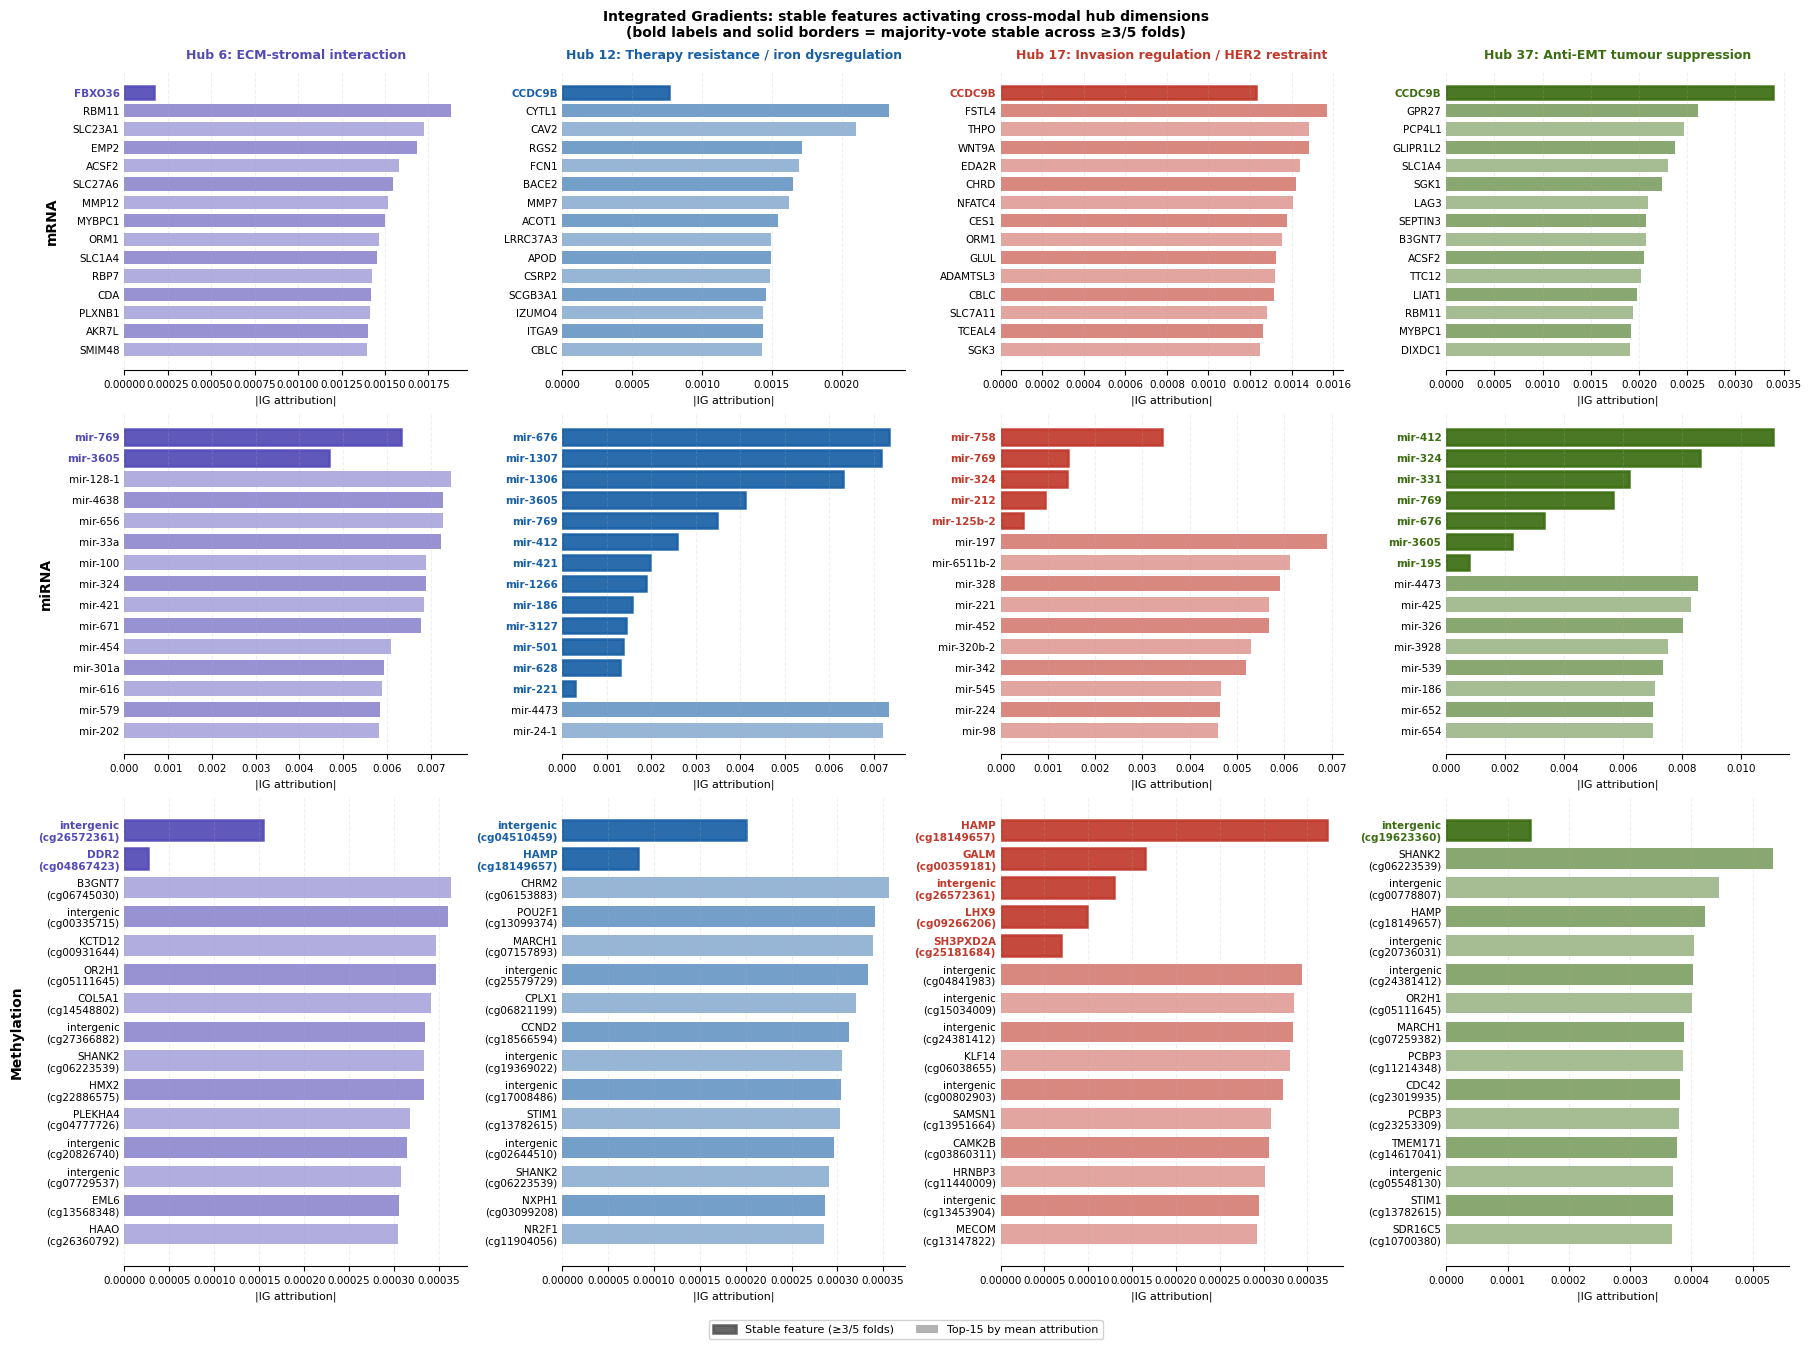

Saved: /g/data/yr31/rn8079/PhD/term2_development/plots/ig_attributions.pdf


In [81]:
plot_hub_attributions_paper(
    attrs=hub_attrs_voted,
    voted_features=voted_features,
    hub_dims=HUB_DIMS,
    hub_labels={
        6:  "Hub 6: ECM-stromal interaction",
        12: "Hub 12: Therapy resistance / iron dysregulation",
        17: "Hub 17: Invasion regulation / HER2 restraint",
        37: "Hub 37: Anti-EMT tumour suppression",
    },
    top_k=15,
)

Figure X | Integrated Gradients attribution across cross-modal hub dimensions. Each column corresponds to one of four latent hub dimensions identified by majority vote across Jacobian analyses of all five cross-validation folds (see Figure X). Each row shows attribution results for one omics modality. Bars represent the mean absolute Integrated Gradients (IG) attribution magnitude, averaged across the five fold-specific models, measuring the contribution of each molecular feature to activating the hub dimension in the corresponding encoder. Features are ordered by descending mean attribution within each panel, with majority-vote stable features always shown first regardless of their mean attribution rank. Bold coloured labels and solid bar borders indicate majority-vote stable features: features that independently appeared among the top-200 most attributed features in at least 3 out of 5 cross-validation folds, indicating reproducibility across different patient partitions. Remaining bars (thin borders, reduced opacity) show the highest-ranked non-stable features by mean attribution and are provided as contextual background; these features should be treated as hypothesis-generating only.

## RNA Only

In [32]:
print(CONFIG["translation_warmup_epochs"])

10


In [33]:
# ── Single-omics ablation: RNA only ──────────────────────────────────────────
_orig_mirna_mask  = TCGABRCADataset._mirna_mask.copy()
_orig_methyl_mask = TCGABRCADataset._methyl_mask.copy()
_orig_warmup      = CONFIG["translation_warmup_epochs"]

TCGABRCADataset._mirna_mask  = np.zeros_like(TCGABRCADataset._mirna_mask)
TCGABRCADataset._methyl_mask = np.zeros_like(TCGABRCADataset._methyl_mask)
CONFIG["translation_warmup_epochs"] = 9999

print("=" * 60)
print("ABLATION: RNA only (miRNA + methylation forced missing)")
print("=" * 60)
fold_results_rna_only = run_cross_validation(CONFIG)

# Restore
TCGABRCADataset._mirna_mask  = _orig_mirna_mask
TCGABRCADataset._methyl_mask = _orig_methyl_mask
CONFIG["translation_warmup_epochs"] = _orig_warmup

ABLATION: RNA only (miRNA + methylation forced missing)

FOLD 1 / 5
  Train: 876  |  Val: 220
  Epoch   1/100 | beta=0.03 | Train loss: 0.5800 (surv=3.886 kl=0.141 recon=1.116 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.5922
  Epoch   2/100 | beta=0.07 | Train loss: 0.5562 (surv=3.750 kl=0.175 recon=1.049 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.7047
  Epoch   3/100 | beta=0.10 | Train loss: 0.5431 (surv=3.609 kl=0.208 recon=1.016 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.7031
  Epoch   4/100 | beta=0.13 | Train loss: 0.5195 (surv=3.291 kl=0.249 recon=0.992 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.6945
  Epoch   5/100 | beta=0.17 | Train loss: 0.5029 (surv=3.051 kl=0.285 recon=0.942 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.6909
  Epoch   6/100 | beta=0.20 | Train loss: 0.4657 (surv=2.626 kl=0.286 recon=0.912 trans=0.000 cycle=0.000 surv_trans=0.000) | Val C-index: 0.5043
  Epoch   7/100 | beta=0.23 | 

## Vanilla PoE

In [44]:
def run_vanilla_poe(cfg):
    """
    VanillaPoE baseline -- pure PoE fusion, no translation, no cycle,
    no consistency loss. Only recon + KL + survival.
    Same architecture as BioPoE but translator=None throughout.
    """
    set_seed(cfg["seed"])

    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)
    skf           = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                                    random_state=cfg["seed"])
    fold_results  = []

    for fold_idx, (train_idx, val_idx) in enumerate(
            skf.split(np.arange(len(strat_labels)), strat_labels)):

        print(f"\n{'='*60}")
        print(f"FOLD {fold_idx + 1} / {cfg['n_folds']}  [VanillaPoE]")
        print(f"  Train: {len(train_idx)}  |  Val: {len(val_idx)}")
        print(f"{'='*60}")

        rna_scaler    = compute_scaler(TCGABRCADataset._rna_data[train_idx][TCGABRCADataset._rna_mask[train_idx]])
        mirna_scaler  = compute_scaler(TCGABRCADataset._mirna_data[train_idx][TCGABRCADataset._mirna_mask[train_idx]])
        methyl_scaler = compute_scaler(TCGABRCADataset._methyl_data[train_idx][TCGABRCADataset._methyl_mask[train_idx]])

        train_dataset = TCGABRCADataset(
            indices=train_idx, rna_scaler=rna_scaler,
            mirna_scaler=mirna_scaler, methyl_scaler=methyl_scaler,
            dropout_probs={"rna": 0.0, "mirna": 0.0, "methyl": 0.0},
        )
        val_dataset = TCGABRCADataset(
            indices=val_idx, rna_scaler=rna_scaler,
            mirna_scaler=mirna_scaler, methyl_scaler=methyl_scaler,
            dropout_probs=None,
        )
        train_loader = DataLoader(train_dataset, batch_size=cfg["batch_size"],
            shuffle=True, collate_fn=collate_fn, num_workers=0, pin_memory=True)
        val_loader   = DataLoader(val_dataset, batch_size=cfg["batch_size"] * 2,
            shuffle=False, collate_fn=collate_fn, num_workers=0, pin_memory=True)

        set_seed(cfg["seed"] + fold_idx)
        model         = BioPoE(latent_dim=N_LATENT).to(device)
        survival_head = SurvivalHead(N_LATENT).to(device)
        # No translator

        all_params = (
            list(model.parameters())
            + list(survival_head.parameters())
        )
        optimizer = torch.optim.AdamW(all_params, lr=cfg["learning_rate"],
                                      weight_decay=cfg["weight_decay"])
        scheduler = CosineAnnealingLR(optimizer, T_max=cfg["n_epochs"], eta_min=1e-5)

        best_score   = -np.inf
        best_c_index = float("nan")
        best_epoch   = 0
        patience_ctr = 0
        best_state   = None

        for epoch in range(1, cfg["n_epochs"] + 1):
            # ── Train ────────────────────────────────────────────────────
            model.train()
            survival_head.train()
            loss_accum = {"total": 0.0, "survival": 0.0, "recon": 0.0, "kl": 0.0}
            n_batches  = 0
            beta       = get_beta(epoch, cfg["kl_warmup_epochs"])

            for batch in train_loader:
                batch = move_batch_to_device(batch, device)
                optimizer.zero_grad()

                # translator=None -- translations never run
                outputs = model(batch, translator=None)

                # Vanilla loss: survival + recon + KL only
                z_surv        = outputs["z_surv"]
                risk_scores   = survival_head(z_surv)
                loss_survival = cox_partial_likelihood_loss(
                    risk_scores, batch["pfi_time"], batch["pfi_event"]
                )

                loss_recon = torch.tensor(0.0, device=device, requires_grad=True)
                mask = batch["mask"]
                recon_targets = {"rna": batch["rna"], "mirna": batch["mirna"],
                                 "methyl": batch["methyl"]}
                for m_idx, m_name in enumerate(["rna", "mirna", "methyl"]):
                    if m_name not in outputs["recons"]:
                        continue
                    obs = mask[:, m_idx]
                    if not obs.any() or recon_targets[m_name] is None:
                        continue
                    loss_recon = loss_recon + F.mse_loss(
                        outputs["recons"][m_name][obs], recon_targets[m_name][obs]
                    )

                mu_poe     = outputs["mu_poe"]
                logvar_poe = outputs["logvar_poe"]
                loss_kl    = -0.5 * torch.mean(
                    1 + logvar_poe - mu_poe.pow(2) - logvar_poe.exp()
                )

                loss = (
                      cfg["lambda_survival"] * loss_survival
                    + cfg["lambda_recon"]    * loss_recon
                    + beta                   * loss_kl
                )

                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    list(model.parameters()) + list(survival_head.parameters()),
                    max_norm=1.0,
                )
                optimizer.step()

                loss_accum["total"]    += loss.item()
                loss_accum["survival"] += loss_survival.item()
                loss_accum["recon"]    += loss_recon.item()
                loss_accum["kl"]       += loss_kl.item()
                n_batches += 1

            scheduler.step()
            train_metrics = {k: v / n_batches for k, v in loss_accum.items()}

            # ── Validate ─────────────────────────────────────────────────
            val_metrics = evaluate(model, None, survival_head, val_loader, device, cfg)

            print(
                f"  Epoch {epoch:3d}/{cfg['n_epochs']} | "
                f"beta={beta:.2f} | "
                f"Train loss: {train_metrics['total']:.4f} "
                f"(surv={train_metrics['survival']:.3f} "
                f"kl={train_metrics['kl']:.3f} "
                f"recon={train_metrics['recon']:.3f}) | "
                f"Val C-index: {val_metrics['c_index']:.4f}"
            )

            # ── Early stopping ────────────────────────────────────────────
            if epoch >= cfg.get("min_epochs", 1):
                c     = val_metrics["c_index"]
                score = c if not np.isnan(c) else -np.inf

                if score > best_score:
                    best_score   = score
                    best_c_index = c
                    best_epoch   = epoch
                    patience_ctr = 0
                    best_state   = {
                        "model":    {k: v.cpu().clone() for k, v in model.state_dict().items()},
                        "survival": {k: v.cpu().clone() for k, v in survival_head.state_dict().items()},
                    }
                else:
                    patience_ctr += 1
                    if patience_ctr >= cfg["patience"]:
                        print(f"  Early stopping at epoch {epoch} "
                              f"(best epoch {best_epoch}, C-index {best_score:.4f})")
                        break

        model.load_state_dict({k: v.to(device) for k, v in best_state["model"].items()})
        survival_head.load_state_dict(
            {k: v.to(device) for k, v in best_state["survival"].items()})

        final_val = evaluate(model, None, survival_head, val_loader, device, cfg)

        print(f"\n  Fold {fold_idx+1} best epoch: {best_epoch}")
        print(f"  Final val C-index: {final_val['c_index']:.4f}")

        fold_results.append({
            "fold":         fold_idx + 1,
            "best_epoch":   best_epoch,
            "best_score":   best_score,
            "best_c_index": best_c_index,
            "val_metrics":  final_val,
            "model_state":  best_state,
            "scalers":      {"rna": rna_scaler, "mirna": mirna_scaler,
                             "methyl": methyl_scaler},
        })

    print(f"\n{'='*60}")
    print(f"VANILLA PoE CROSS-VALIDATION SUMMARY")
    print(f"{'='*60}")
    cidxs = [fr["val_metrics"]["c_index"] for fr in fold_results]
    print(f"C-index: {np.nanmean(cidxs):.4f} +/- {np.nanstd(cidxs):.4f}")
    print(f"\nPer-fold C-index:")
    for fr in fold_results:
        print(f"  Fold {fr['fold']}: {fr['best_c_index']:.4f} "
              f"(best epoch {fr['best_epoch']})")

    return fold_results


In [45]:
CONFIG["translation_warmup_epochs"] = 10  # restore
# ── Run VanillaPoE ────────────────────────────────────────────────────────────
print("=" * 60)
print("VANILLA PoE BASELINE")
print("=" * 60)
fold_results_vanilla = run_vanilla_poe(CONFIG)

VANILLA PoE BASELINE

FOLD 1 / 5  [VanillaPoE]
  Train: 876  |  Val: 220
  Epoch   1/100 | beta=0.03 | Train loss: 0.7432 (surv=3.948 kl=0.319 recon=3.378) | Val C-index: 0.6786
  Epoch   2/100 | beta=0.07 | Train loss: 0.7097 (surv=3.709 kl=0.311 recon=3.181) | Val C-index: 0.6204
  Epoch   3/100 | beta=0.10 | Train loss: 0.6853 (surv=3.472 kl=0.299 recon=3.083) | Val C-index: 0.6847
  Epoch   4/100 | beta=0.13 | Train loss: 0.6645 (surv=3.254 kl=0.294 recon=2.999) | Val C-index: 0.6823
  Epoch   5/100 | beta=0.17 | Train loss: 0.6183 (surv=2.796 kl=0.306 recon=2.878) | Val C-index: 0.7108
  Epoch   6/100 | beta=0.20 | Train loss: 0.5837 (surv=2.369 kl=0.325 recon=2.818) | Val C-index: 0.6189
  Epoch   7/100 | beta=0.23 | Train loss: 0.5616 (surv=2.114 kl=0.307 recon=2.787) | Val C-index: 0.6275
  Epoch   8/100 | beta=0.27 | Train loss: 0.5592 (surv=2.090 kl=0.279 recon=2.759) | Val C-index: 0.5662
  Epoch   9/100 | beta=0.30 | Train loss: 0.5440 (surv=2.006 kl=0.237 recon=2.722) | Va

## MCAR

In [122]:
class MCARDataset(Dataset):
    """
    Wraps a TCGABRCADataset and forces a single modality missing at a given rate.
    Natural missingness is preserved -- forced missingness is applied on top.
    """
    def __init__(self, base_dataset, forced_missing_modality, forced_missing_rate):
        self.base     = base_dataset
        self.modality = forced_missing_modality
        self.rate     = forced_missing_rate
        rng = np.random.RandomState(42)
        n   = len(base_dataset)
        self.forced_missing = rng.rand(n) < forced_missing_rate

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        item = self.base[idx]
        if self.forced_missing[idx]:
            item[self.modality] = None
            mod_idx = {"rna": 0, "mirna": 1, "methyl": 2}[self.modality]
            mask = item["mask"].clone()
            mask[mod_idx] = False
            item["mask"] = mask
        return item


@torch.no_grad()
def evaluate_mcar(model, translator, survival_head, dataset, device, cfg,
                  use_translation=True):
    """
    Evaluate model on an MCARDataset. Returns C-index only.
    use_translation=False disables translation even if translator is provided.
    translator=None runs VanillaPoE (no translation architecture).
    """
    model.eval()
    if translator is not None:
        translator.eval()
    survival_head.eval()

    loader = DataLoader(dataset, batch_size=cfg["batch_size"] * 2,
                        shuffle=False, collate_fn=collate_fn, num_workers=0)

    # Control translation activation
    trans_warmup = cfg["translation_warmup_epochs"] if use_translation else 9999

    all_risk, all_pfi_time, all_pfi_event = [], [], []

    for batch in loader:
        batch   = move_batch_to_device(batch, device)
        outputs = model(
            batch,
            translator=translator if use_translation else None,
            epoch=cfg["n_epochs"],
            translation_warmup_epochs=trans_warmup,
        )
        risk       = survival_head(outputs["z_surv"])
        valid_surv = batch["pfi_event"] >= 0
        if valid_surv.any():
            all_risk.append(risk[valid_surv].cpu())
            all_pfi_time.append(batch["pfi_time"][valid_surv].cpu())
            all_pfi_event.append(batch["pfi_event"][valid_surv].cpu())

    c_index = float("nan")
    if len(all_risk) > 0:
        risk_np  = torch.cat(all_risk).squeeze().numpy()
        time_np  = torch.cat(all_pfi_time).numpy()
        event_np = torch.cat(all_pfi_event).numpy()
        if event_np.sum() > 0:
            c_index = concordance_index(time_np, risk_np, event_np)

    return {"c_index": c_index}


def run_mcar_evaluation(fold_results_biepoe, fold_results_notrans,
                        fold_results_vanilla, cfg,
                        missing_rates=None, modalities=None):
    """
    Run full MCAR grid across three model variants:
        - BioPoE full (with translation)
        - BioPoE no-translation (architecture intact, translations disabled)
        - VanillaPoE (no translation architecture, recon+KL+survival only)

    For each fold's best model, for each modality, for each missing rate,
    evaluate C-index.

    Returns nested dict:
        results[modality][rate] = {
            "biopoe":    [c_index per fold],
            "no_trans":  [c_index per fold],
            "vanilla":   [c_index per fold],
        }
    """
    if missing_rates is None:
        missing_rates = [0.0, 0.3, 0.5, 0.7, 0.9]
    if modalities is None:
        modalities = ["rna", "mirna", "methyl"]

    results = {
        mod: {
            rate: {"biopoe": [], "no_trans": [], "vanilla": []}
            for rate in missing_rates
        }
        for mod in modalities
    }

    # Reproduce fold splits -- same as run_cross_validation
    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)
    skf    = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                             random_state=cfg["seed"])
    splits = list(skf.split(np.arange(len(strat_labels)), strat_labels))

    for fold_idx, (fr_bio, fr_notrans, fr_vanilla) in enumerate(
            zip(fold_results_biepoe, fold_results_notrans, fold_results_vanilla)):

        print(f"\nFold {fold_idx + 1} / {cfg['n_folds']}")

        # ── Load BioPoE full model ────────────────────────────────────────
        model_bio = BioPoE(latent_dim=N_LATENT).to(device)
        model_bio.load_state_dict(
            {k: v.to(device) for k, v in fr_bio["model_state"]["model"].items()})
        translator_bio = CrossModalTranslator(
            N_LATENT, hidden_dim=cfg["translation_hidden_dim"]).to(device)
        translator_bio.load_state_dict(
            {k: v.to(device) for k, v in fr_bio["model_state"]["translator"].items()})
        surv_bio = SurvivalHead(N_LATENT).to(device)
        surv_bio.load_state_dict(
            {k: v.to(device) for k, v in fr_bio["model_state"]["survival"].items()})

        # ── Load BioPoE no-translation model ─────────────────────────────
        model_notrans = BioPoE(latent_dim=N_LATENT).to(device)
        model_notrans.load_state_dict(
            {k: v.to(device) for k, v in fr_notrans["model_state"]["model"].items()})
        translator_notrans = CrossModalTranslator(
            N_LATENT, hidden_dim=cfg["translation_hidden_dim"]).to(device)
        translator_notrans.load_state_dict(
            {k: v.to(device) for k, v in fr_notrans["model_state"]["translator"].items()})
        surv_notrans = SurvivalHead(N_LATENT).to(device)
        surv_notrans.load_state_dict(
            {k: v.to(device) for k, v in fr_notrans["model_state"]["survival"].items()})

        # ── Load VanillaPoE model ─────────────────────────────────────────
        model_vanilla = BioPoE(latent_dim=N_LATENT).to(device)
        model_vanilla.load_state_dict(
            {k: v.to(device) for k, v in fr_vanilla["model_state"]["model"].items()})
        surv_vanilla = SurvivalHead(N_LATENT).to(device)
        surv_vanilla.load_state_dict(
            {k: v.to(device) for k, v in fr_vanilla["model_state"]["survival"].items()})

        # ── Rebuild val dataset ───────────────────────────────────────────
        _, val_idx = splits[fold_idx]
        val_dataset = TCGABRCADataset(
            indices=val_idx,
            rna_scaler=fr_bio["scalers"]["rna"],
            mirna_scaler=fr_bio["scalers"]["mirna"],
            methyl_scaler=fr_bio["scalers"]["methyl"],
            dropout_probs=None,
        )

        for mod in modalities:
            for rate in missing_rates:
                mcar_dataset = MCARDataset(val_dataset, mod, rate)

                res_bio = evaluate_mcar(
                    model_bio, translator_bio, surv_bio,
                    mcar_dataset, device, cfg, use_translation=True,
                )
                res_notrans = evaluate_mcar(
                    model_notrans, translator_notrans, surv_notrans,
                    mcar_dataset, device, cfg, use_translation=False,
                )
                res_vanilla = evaluate_mcar(
                    model_vanilla, None, surv_vanilla,
                    mcar_dataset, device, cfg, use_translation=False,
                )

                results[mod][rate]["biopoe"].append(res_bio["c_index"])
                results[mod][rate]["no_trans"].append(res_notrans["c_index"])
                results[mod][rate]["vanilla"].append(res_vanilla["c_index"])

                print(
                    f"  {mod:>6} @{rate:.1f} | "
                    f"BioPoE={res_bio['c_index']:.4f}  "
                    f"NoTrans={res_notrans['c_index']:.4f}  "
                    f"Vanilla={res_vanilla['c_index']:.4f}  "
                    f"delta(bio-van)={res_bio['c_index']-res_vanilla['c_index']:+.4f}"
                )

    return results

In [123]:
# ── requires fold_results_survival (BioPoE full),
#             fold_results_phase1 (BioPoE warmup=9999),
#             fold_results_vanilla (VanillaPoE)
print("=" * 60)
print("MCAR ROBUSTNESS EVALUATION")
print("=" * 60)
mcar_results = run_mcar_evaluation(
    fold_results_biepoe=fold_results_survival,
    fold_results_notrans=fold_results_phase1,  # the no-translation run
    fold_results_vanilla=fold_results_vanilla,
    cfg=CONFIG,
)

MCAR ROBUSTNESS EVALUATION

Fold 1 / 5
     rna @0.0 | BioPoE=0.7402  NoTrans=0.7086  Vanilla=0.6685  delta(bio-van)=+0.0717
     rna @0.3 | BioPoE=0.7396  NoTrans=0.6878  Vanilla=0.6694  delta(bio-van)=+0.0702
     rna @0.5 | BioPoE=0.7335  NoTrans=0.6667  Vanilla=0.6275  delta(bio-van)=+0.1060
     rna @0.7 | BioPoE=0.7371  NoTrans=0.6455  Vanilla=0.5833  delta(bio-van)=+0.1538
     rna @0.9 | BioPoE=0.7227  NoTrans=0.6241  Vanilla=0.5653  delta(bio-van)=+0.1575
   mirna @0.0 | BioPoE=0.7402  NoTrans=0.7086  Vanilla=0.6685  delta(bio-van)=+0.0717
   mirna @0.3 | BioPoE=0.7469  NoTrans=0.6909  Vanilla=0.6875  delta(bio-van)=+0.0594
   mirna @0.5 | BioPoE=0.7469  NoTrans=0.7022  Vanilla=0.6881  delta(bio-van)=+0.0588
   mirna @0.7 | BioPoE=0.7197  NoTrans=0.6964  Vanilla=0.6924  delta(bio-van)=+0.0273
   mirna @0.9 | BioPoE=0.7331  NoTrans=0.7120  Vanilla=0.6887  delta(bio-van)=+0.0444
  methyl @0.0 | BioPoE=0.7402  NoTrans=0.7086  Vanilla=0.6685  delta(bio-van)=+0.0717
  methyl @0.3 |

In [124]:
# ── MCAR Summary Table ────────────────────────────────────────────────────────
modalities    = ["rna", "mirna", "methyl"]
missing_rates = [0.0, 0.3, 0.5, 0.7, 0.9]

print(f"\n{'='*90}")
print(f"MCAR ROBUSTNESS — C-index across missing rates")
print(f"{'='*90}")
print(f"{'':12}", end="")
for rate in missing_rates:
    print(f"{'rate='+str(rate):>18}", end="")
print()
print(f"{'Modality':<12}", end="")
for rate in missing_rates:
    print(f"{'BioPoE':>6}{'NoTrns':>6}{'Vanlla':>6}", end="")
print()
print(f"{'-'*90}")

for mod in modalities:
    print(f"  {mod:<10}", end="")
    for rate in missing_rates:
        bio  = np.nanmean(mcar_results[mod][rate]["biopoe"])
        notr = np.nanmean(mcar_results[mod][rate]["no_trans"])
        van  = np.nanmean(mcar_results[mod][rate]["vanilla"])
        print(f"  {bio:.3f}{notr:.3f}{van:.3f}", end="")
    print()

print(f"\n{'='*90}")
print(f"DELTA: BioPoE minus VanillaPoE (positive = translation helps)")
print(f"{'='*90}")
print(f"{'Modality':<12}", end="")
for rate in missing_rates:
    print(f"{'rate='+str(rate):>18}", end="")
print()
print(f"{'-'*90}")

for mod in modalities:
    print(f"  {mod:<10}", end="")
    for rate in missing_rates:
        bio = np.nanmean(mcar_results[mod][rate]["biopoe"])
        van = np.nanmean(mcar_results[mod][rate]["vanilla"])
        delta = bio - van
        sign  = "+" if delta >= 0 else ""
        print(f"  {sign}{delta:.3f}".rjust(18), end="")
    print()

print(f"\n{'='*90}")
print(f"DELTA: BioPoE minus NoTranslation (translation mechanism contribution)")
print(f"{'='*90}")
print(f"{'Modality':<12}", end="")
for rate in missing_rates:
    print(f"{'rate='+str(rate):>18}", end="")
print()
print(f"{'-'*90}")

for mod in modalities:
    print(f"  {mod:<10}", end="")
    for rate in missing_rates:
        bio  = np.nanmean(mcar_results[mod][rate]["biopoe"])
        notr = np.nanmean(mcar_results[mod][rate]["no_trans"])
        delta = bio - notr
        sign  = "+" if delta >= 0 else ""
        print(f"  {sign}{delta:.3f}".rjust(18), end="")
    print()


MCAR ROBUSTNESS — C-index across missing rates
                      rate=0.0          rate=0.3          rate=0.5          rate=0.7          rate=0.9
Modality    BioPoENoTrnsVanllaBioPoENoTrnsVanllaBioPoENoTrnsVanllaBioPoENoTrnsVanllaBioPoENoTrnsVanlla
------------------------------------------------------------------------------------------
  rna         0.6890.6790.648  0.6740.6580.626  0.6710.6510.599  0.6700.6440.590  0.6660.6360.583
  mirna       0.6890.6790.648  0.6920.6850.656  0.6920.6830.645  0.6970.6910.646  0.7020.6890.642
  methyl      0.6890.6790.648  0.6800.6680.628  0.6810.6640.622  0.6730.6630.627  0.6700.6600.628

DELTA: BioPoE minus VanillaPoE (positive = translation helps)
Modality              rate=0.0          rate=0.3          rate=0.5          rate=0.7          rate=0.9
------------------------------------------------------------------------------------------
  rna                   +0.042            +0.049            +0.072            +0.081            +0.083
 

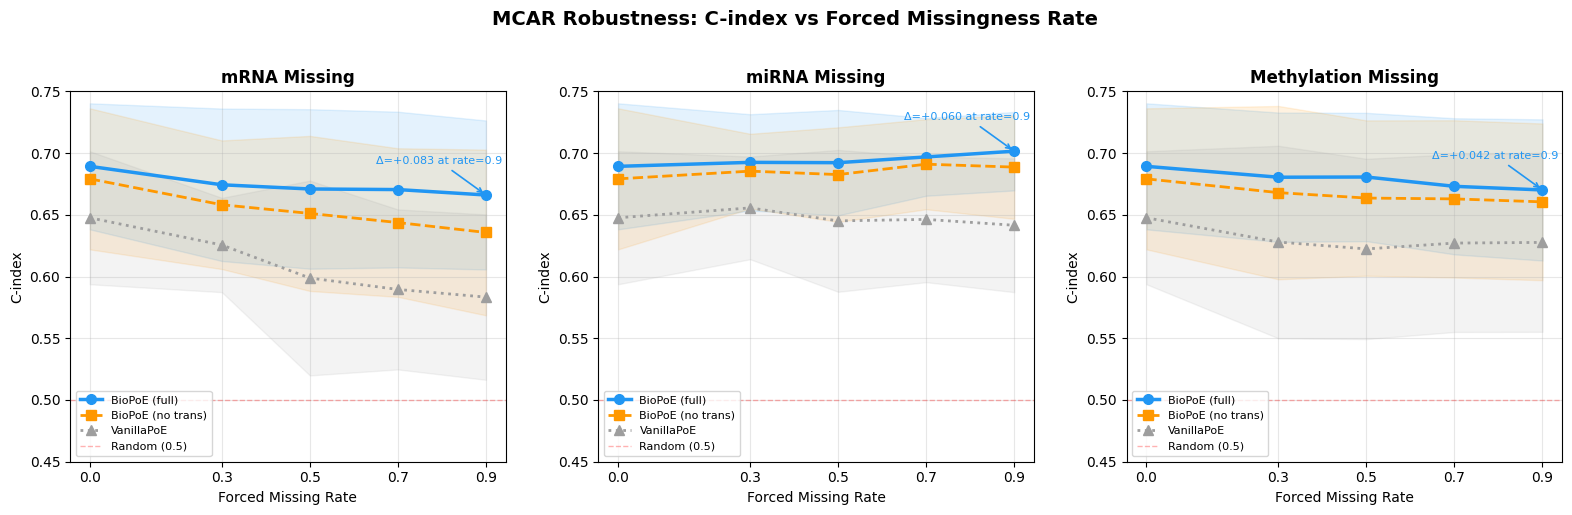

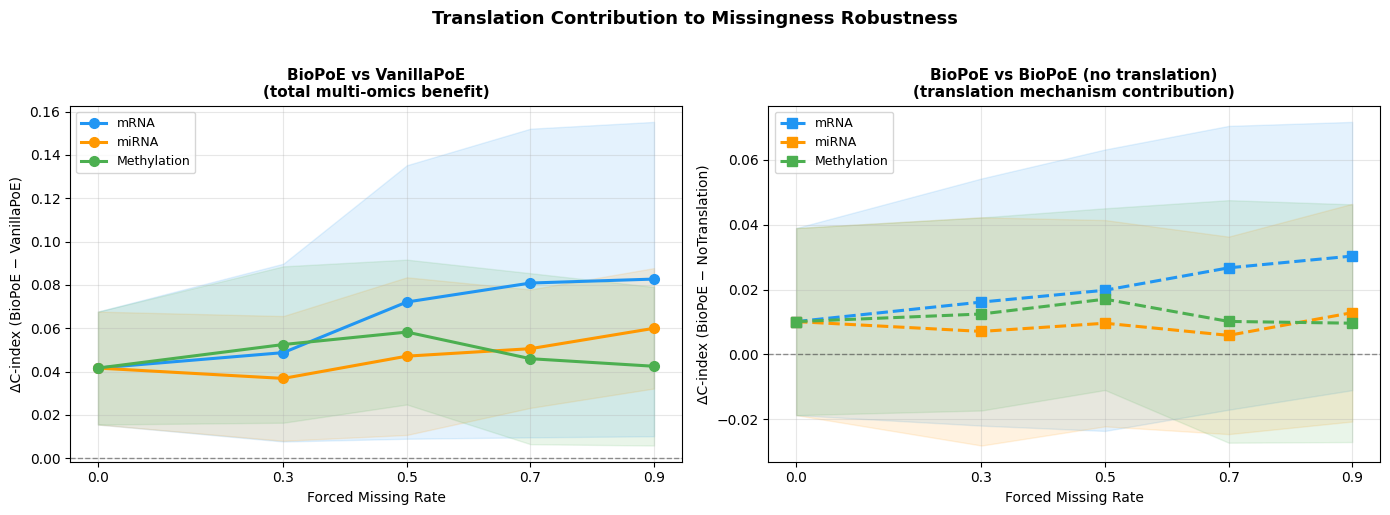

In [125]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def plot_mcar_curves(mcar_results, cfg, save_path="mcar_robustness.png"):
    """
    Three-panel MCAR robustness plot, one panel per modality.
    Each panel shows C-index vs missing rate for three model variants.
    """
    missing_rates = sorted(mcar_results["rna"].keys())
    modalities    = ["rna", "mirna", "methyl"]
    mod_labels    = {"rna": "mRNA", "mirna": "miRNA", "methyl": "Methylation"}

    # Model styles
    models = {
        "biopoe":   {"label": "BioPoE (full)",       "color": "#2196F3", "marker": "o", "lw": 2.5, "ls": "-"},
        "no_trans": {"label": "BioPoE (no trans)",   "color": "#FF9800", "marker": "s", "lw": 2.0, "ls": "--"},
        "vanilla":  {"label": "VanillaPoE",          "color": "#9E9E9E", "marker": "^", "lw": 2.0, "ls": ":"},
    }

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
    fig.suptitle("MCAR Robustness: C-index vs Forced Missingness Rate",
                 fontsize=14, fontweight="bold", y=1.02)

    for ax, mod in zip(axes, modalities):
        for model_key, style in models.items():
            means = []
            stds  = []
            for rate in missing_rates:
                vals = mcar_results[mod][rate][model_key]
                means.append(np.nanmean(vals))
                stds.append(np.nanstd(vals))

            means = np.array(means)
            stds  = np.array(stds)

            ax.plot(
                missing_rates, means,
                label=style["label"],
                color=style["color"],
                marker=style["marker"],
                linewidth=style["lw"],
                linestyle=style["ls"],
                markersize=7,
                zorder=3,
            )
            ax.fill_between(
                missing_rates,
                means - stds,
                means + stds,
                alpha=0.12,
                color=style["color"],
            )

        # Reference line at 0.5 (random)
        ax.axhline(y=0.5, color="red", linestyle="--", alpha=0.3,
                   linewidth=1.0, label="Random (0.5)")

        ax.set_title(f"{mod_labels[mod]} Missing", fontsize=12, fontweight="bold")
        ax.set_xlabel("Forced Missing Rate", fontsize=10)
        ax.set_ylabel("C-index", fontsize=10)
        ax.set_xticks(missing_rates)
        ax.set_xticklabels([str(r) for r in missing_rates])
        ax.set_ylim(0.45, 0.75)
        ax.grid(alpha=0.3, zorder=0)
        ax.legend(fontsize=8, loc="lower left")

        # Annotate delta at highest missing rate for BioPoE vs VanillaPoE
        rate_max = missing_rates[-1]
        bio_max  = np.nanmean(mcar_results[mod][rate_max]["biopoe"])
        van_max  = np.nanmean(mcar_results[mod][rate_max]["vanilla"])
        delta    = bio_max - van_max
        ax.annotate(
            f"Δ={delta:+.3f} at rate={rate_max}",
            xy=(rate_max, bio_max),
            xytext=(rate_max - 0.25, bio_max + 0.025),
            fontsize=8,
            color="#2196F3",
            arrowprops=dict(arrowstyle="->", color="#2196F3", lw=1.2),
        )

    plt.tight_layout()
    plt.show()


def plot_mcar_delta(mcar_results, save_path="mcar_delta.png"):
    """
    Delta plot: BioPoE minus VanillaPoE, one line per modality.
    Shows where translation adds the most value.
    """
    missing_rates = sorted(mcar_results["rna"].keys())
    modalities    = ["rna", "mirna", "methyl"]
    mod_labels    = {"rna": "mRNA", "mirna": "miRNA", "methyl": "Methylation"}
    mod_colors    = {"rna": "#2196F3", "mirna": "#FF9800", "methyl": "#4CAF50"}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Translation Contribution to Missingness Robustness",
                 fontsize=13, fontweight="bold", y=1.02)

    # Left: BioPoE vs VanillaPoE (total architecture benefit)
    ax = axes[0]
    ax.set_title("BioPoE vs VanillaPoE\n(total multi-omics benefit)",
                 fontsize=11, fontweight="bold")
    for mod in modalities:
        deltas = []
        stds   = []
        for rate in missing_rates:
            bio  = np.array(mcar_results[mod][rate]["biopoe"])
            van  = np.array(mcar_results[mod][rate]["vanilla"])
            d    = bio - van
            deltas.append(np.nanmean(d))
            stds.append(np.nanstd(d))
        deltas = np.array(deltas)
        stds   = np.array(stds)
        ax.plot(missing_rates, deltas, label=mod_labels[mod],
                color=mod_colors[mod], marker="o", linewidth=2.2, markersize=7)
        ax.fill_between(missing_rates, deltas - stds, deltas + stds,
                        alpha=0.12, color=mod_colors[mod])

    ax.axhline(y=0, color="black", linestyle="--", alpha=0.4, linewidth=1.0)
    ax.set_xlabel("Forced Missing Rate", fontsize=10)
    ax.set_ylabel("ΔC-index (BioPoE − VanillaPoE)", fontsize=10)
    ax.set_xticks(missing_rates)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # Right: BioPoE vs NoTranslation (translation mechanism only)
    ax = axes[1]
    ax.set_title("BioPoE vs BioPoE (no translation)\n(translation mechanism contribution)",
                 fontsize=11, fontweight="bold")
    for mod in modalities:
        deltas = []
        stds   = []
        for rate in missing_rates:
            bio  = np.array(mcar_results[mod][rate]["biopoe"])
            notr = np.array(mcar_results[mod][rate]["no_trans"])
            d    = bio - notr
            deltas.append(np.nanmean(d))
            stds.append(np.nanstd(d))
        deltas = np.array(deltas)
        stds   = np.array(stds)
        ax.plot(missing_rates, deltas, label=mod_labels[mod],
                color=mod_colors[mod], marker="s", linewidth=2.2,
                linestyle="--", markersize=7)
        ax.fill_between(missing_rates, deltas - stds, deltas + stds,
                        alpha=0.12, color=mod_colors[mod])

    ax.axhline(y=0, color="black", linestyle="--", alpha=0.4, linewidth=1.0)
    ax.set_xlabel("Forced Missing Rate", fontsize=10)
    ax.set_ylabel("ΔC-index (BioPoE − NoTranslation)", fontsize=10)
    ax.set_xticks(missing_rates)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# ── Run plots ─────────────────────────────────────────────────────────────────
plot_mcar_curves(mcar_results, CONFIG, save_path="mcar_robustness.png")
plot_mcar_delta(mcar_results, save_path="mcar_delta.png")

## Save Results

In [126]:
import pickle

pickle.dump(fold_results_survival, open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_biopoe_canonical.pkl', 'wb'))
pickle.dump(fold_results_phase1,   open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_notrans_canonical.pkl', 'wb'))
pickle.dump(fold_results_vanilla,  open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_vanilla_canonical.pkl', 'wb'))

print("Saved all three fold results.")

Saved all three fold results.


In [53]:
with open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_biopoe_canonical.pkl', 'rb') as f:
    fold_results_survival = pickle.load(f)

with open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_notrans_canonical.pkl', 'rb') as f:
    fold_results_phase1 = pickle.load(f)

with open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_vanilla_canonical.pkl', 'rb') as f:
    fold_results_vanilla = pickle.load(f)

with open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_mvae_canonical.pkl', 'rb') as f:
    fold_results_mvae = pickle.load(f)

with open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_clue_canonical.pkl', 'rb') as f:
    fold_results_clue = pickle.load(f)

with open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_mofa_canonical.pkl', 'rb') as f:
    fold_results_mofa = pickle.load(f)

print("Loaded all three fold results.")

Loaded all three fold results.


## Run full ensemble

In [29]:
def train_full_ensemble(cfg, n_seeds=5):
    """
    Train n_seeds independent models on the full dataset.
    For METABRIC inference: average risk scores across seeds.
    """
    all_indices = np.arange(len(TCGABRCADataset._sample_ids))
    
    rna_scaler    = compute_scaler(TCGABRCADataset._rna_data[TCGABRCADataset._rna_mask])
    mirna_scaler  = compute_scaler(TCGABRCADataset._mirna_data[TCGABRCADataset._mirna_mask])
    methyl_scaler = compute_scaler(TCGABRCADataset._methyl_data[TCGABRCADataset._methyl_mask])

    ensemble_states = []

    for seed_idx in range(n_seeds):
        seed = cfg["seed"] + seed_idx
        set_seed(seed)
        print(f"\n{'='*60}")
        print(f"ENSEMBLE SEED {seed_idx+1}/{n_seeds}  (seed={seed})")
        print(f"{'='*60}")

        train_dataset = TCGABRCADataset(
            indices=all_indices,
            rna_scaler=rna_scaler,
            mirna_scaler=mirna_scaler,
            methyl_scaler=methyl_scaler,
            dropout_probs={"rna": 0.0, "mirna": 0.0, "methyl": 0.0},
        )
        train_loader = DataLoader(
            train_dataset, batch_size=cfg["batch_size"],
            shuffle=True, collate_fn=collate_fn, num_workers=0, pin_memory=True
        )

        model         = BioPoE(latent_dim=N_LATENT).to(device)
        translator    = CrossModalTranslator(N_LATENT, hidden_dim=cfg["translation_hidden_dim"]).to(device)
        survival_head = SurvivalHead(N_LATENT).to(device)
        optimizer     = torch.optim.AdamW(
            list(model.parameters()) + list(translator.parameters()) + list(survival_head.parameters()),
            lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"]
        )
        scheduler = CosineAnnealingLR(optimizer, T_max=cfg["n_epochs"])

        for epoch in range(1, cfg["n_epochs"] + 1):
            beta = min(1.0, epoch / cfg["kl_warmup_epochs"])
            model.train(); translator.train(); survival_head.train()

            for batch in train_loader:
                batch = move_batch_to_device(batch, device)
                optimizer.zero_grad()
                outputs = model(batch, translator=translator, epoch=epoch,
                                translation_warmup_epochs=cfg["translation_warmup_epochs"])
                loss, _ = compute_loss(
                    outputs=outputs, batch=batch, beta=beta,
                    lambda_recon=cfg["lambda_recon"],
                    lambda_consist=cfg["lambda_consist"],
                    lambda_survival=cfg["lambda_survival"],
                    lambda_translation=cfg["lambda_translation"],
                    lambda_cycle=cfg["lambda_cycle"],
                    lambda_gate=cfg["lambda_gate"],
                    survival_head=survival_head, translator=translator,
                    epoch=epoch,
                    translation_warmup_epochs=cfg["translation_warmup_epochs"],
                    model=model,                                        # ← ADD
                    lambda_unimodal=cfg["lambda_unimodal"],             # ← ADD
                    lambda_surv_trans=cfg.get("lambda_surv_trans", 0.0), # ← ADD
                )
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    list(model.parameters()) + list(translator.parameters()) + list(survival_head.parameters()),
                    max_norm=1.0
                )
                optimizer.step()
            scheduler.step()

        ensemble_states.append({
            "model":         {k: v.cpu() for k, v in model.state_dict().items()},
            "translator":    {k: v.cpu() for k, v in translator.state_dict().items()},
            "survival_head": {k: v.cpu() for k, v in survival_head.state_dict().items()},
            "scalers":       {"rna": rna_scaler, "mirna": mirna_scaler, "methyl": methyl_scaler},
            "seed":          seed,
        })
        print(f"  Seed {seed_idx+1} done.")

    return ensemble_states


@torch.no_grad()
def ensemble_predict(ensemble_states, loader, cfg):
    """
    Average risk scores across all ensemble members.
    Use this for METABRIC inference.
    """
    all_seed_risks = []

    for state in ensemble_states:
        model         = BioPoE(latent_dim=N_LATENT).to(device)
        translator    = CrossModalTranslator(N_LATENT, hidden_dim=cfg["translation_hidden_dim"]).to(device)
        survival_head = SurvivalHead(N_LATENT).to(device)

        model.load_state_dict({k: v.to(device) for k, v in state["model"].items()})
        translator.load_state_dict({k: v.to(device) for k, v in state["translator"].items()})
        survival_head.load_state_dict({k: v.to(device) for k, v in state["survival_head"].items()})

        model.eval(); translator.eval(); survival_head.eval()

        seed_risks = []
        for batch in loader:
            batch   = move_batch_to_device(batch, device)
            outputs = model(batch, translator=translator,
                            epoch=cfg["n_epochs"],
                            translation_warmup_epochs=cfg["translation_warmup_epochs"])
            risk = survival_head(outputs["z_surv"]).squeeze(-1).cpu()
            seed_risks.append(risk)

        all_seed_risks.append(torch.cat(seed_risks))

    # Average across seeds then return as numpy
    return torch.stack(all_seed_risks).mean(dim=0).numpy()

In [30]:
# ── Ensemble training ─────────────────────────────────────────────────────────
# Use mean best epoch from CV to avoid overfitting (no early stopping on full data)
mean_best_epoch = int(np.round(np.mean([fr["best_epoch"] for fr in fold_results_survival])))
print(f"Mean best epoch from CV: {mean_best_epoch}")

CONFIG_ENSEMBLE = {**CONFIG, "n_epochs": mean_best_epoch}
ensemble_states = train_full_ensemble(CONFIG_ENSEMBLE, n_seeds=5)
pickle.dump(ensemble_states, open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/ensemble_full_dataset.pkl', 'wb'))

Mean best epoch from CV: 44

ENSEMBLE SEED 1/5  (seed=0)
  Seed 1 done.

ENSEMBLE SEED 2/5  (seed=1)
  Seed 2 done.

ENSEMBLE SEED 3/5  (seed=2)
  Seed 3 done.

ENSEMBLE SEED 4/5  (seed=3)
  Seed 4 done.

ENSEMBLE SEED 5/5  (seed=4)
  Seed 5 done.


In [33]:
 # ── Wrapper functions: input -> hub dim activation ────────────────────────
def make_encoder_hub_fn(encoder, hub_dim):
    """Returns function: x -> mu[hub_dim] for use with IG."""
    def fn(x):
        mu, _ = encoder(x)
        return mu[:, hub_dim].unsqueeze(1)   # (batch, 1)
    return fn

              
def compute_hub_ig_ensemble(ensemble_states, cfg, hub_dims=HUB_DIMS, n_steps=50):
    """
    Compute IG attributions averaged across all ensemble seeds.
    Uses full dataset loader — no train/val split needed.
    """
    all_indices = np.arange(len(TCGABRCADataset._sample_ids))
    
    # Collect attributions per seed then average
    all_seed_attrs = []
    
    for seed_idx, state in enumerate(ensemble_states):
        print(f"Running IG for seed {seed_idx+1}/{len(ensemble_states)}...")
        
        dataset = TCGABRCADataset(
            indices=all_indices,
            rna_scaler=state["scalers"]["rna"],
            mirna_scaler=state["scalers"]["mirna"],
            methyl_scaler=state["scalers"]["methyl"],
            dropout_probs=None,
        )
        loader = DataLoader(dataset, batch_size=32,
                           shuffle=False, collate_fn=collate_fn, num_workers=0)
        
        model = BioPoE(latent_dim=N_LATENT).to(device)
        model.load_state_dict({k: v.to(device) for k, v in state["model"].items()})
        model.eval()
        
        encoders = {
            "rna":    model.rna_enc,
            "mirna":  model.mirna_enc,
            "methyl": model.methyl_enc,
        }
        modality_keys  = ["rna", "mirna", "methyl"]
        mask_indices   = {"rna": 0, "mirna": 1, "methyl": 2}
        
        attrs_accum = {
            mod: {d: [] for d in hub_dims}
            for mod in modality_keys
        }
        
        for batch in loader:
            batch = move_batch_to_device(batch, device)
            mask  = batch["mask"]
            
            for mod in modality_keys:
                m_idx = mask_indices[mod]
                obs   = mask[:, m_idx]
                if not obs.any() or batch[mod] is None:
                    continue
                x_obs    = batch[mod][obs].detach()
                baseline = torch.zeros_like(x_obs)
                encoder  = encoders[mod]
                
                for hub_dim in hub_dims:
                    fn = make_encoder_hub_fn(encoder, hub_dim)
                    ig = IntegratedGradients(fn)
                    attr = ig.attribute(
                        x_obs, baselines=baseline,
                        n_steps=n_steps, return_convergence_delta=False,
                    )
                    attrs_accum[mod][hub_dim].append(attr.detach().cpu().numpy())
        
        # Aggregate this seed
        seed_attrs = {}
        for mod in modality_keys:
            hub_list = []
            for hub_dim in hub_dims:
                chunks = attrs_accum[mod][hub_dim]
                if chunks:
                    hub_list.append(np.concatenate(chunks, axis=0).mean(axis=0))
                else:
                    hub_list.append(None)
            seed_attrs[mod] = hub_list
        
        all_seed_attrs.append(seed_attrs)
    
    # Average across seeds
    final_attrs = {}
    for mod in modality_keys:
        final_attrs[mod] = []
        for i in range(len(hub_dims)):
            seed_arrays = [s[mod][i] for s in all_seed_attrs if s[mod][i] is not None]
            if seed_arrays:
                final_attrs[mod].append(np.stack(seed_arrays, axis=0).mean(axis=0))
            else:
                final_attrs[mod].append(None)
    
    return final_attrs

Running IG for seed 1/5...
Running IG for seed 2/5...
Running IG for seed 3/5...
Running IG for seed 4/5...
Running IG for seed 5/5...
TOP-20 FEATURES BY IG ATTRIBUTION — HUB DIMENSIONS [12, 37, 5]
Baseline = zeros (z-scored inputs)

RNA → Hub dim 12
  Feature                     |IG attr|
  -------------------------------------
  ENSG00000213316                0.0007
  ENSG00000177943                0.0006
  ENSG00000286190                0.0006
  ENSG00000107872                0.0006
  ENSG00000187634                0.0005
  ENSG00000104936                0.0005
  ENSG00000125508                0.0005
  ENSG00000010327                0.0005
  ENSG00000125967                0.0005
  ENSG00000130487                0.0005
  ENSG00000100968                0.0005
  ENSG00000163106                0.0005
  ENSG00000184986                0.0005
  ENSG00000149534                0.0005
  ENSG00000090006                0.0005
  ENSG00000046653                0.0004
  ENSG00000085117            

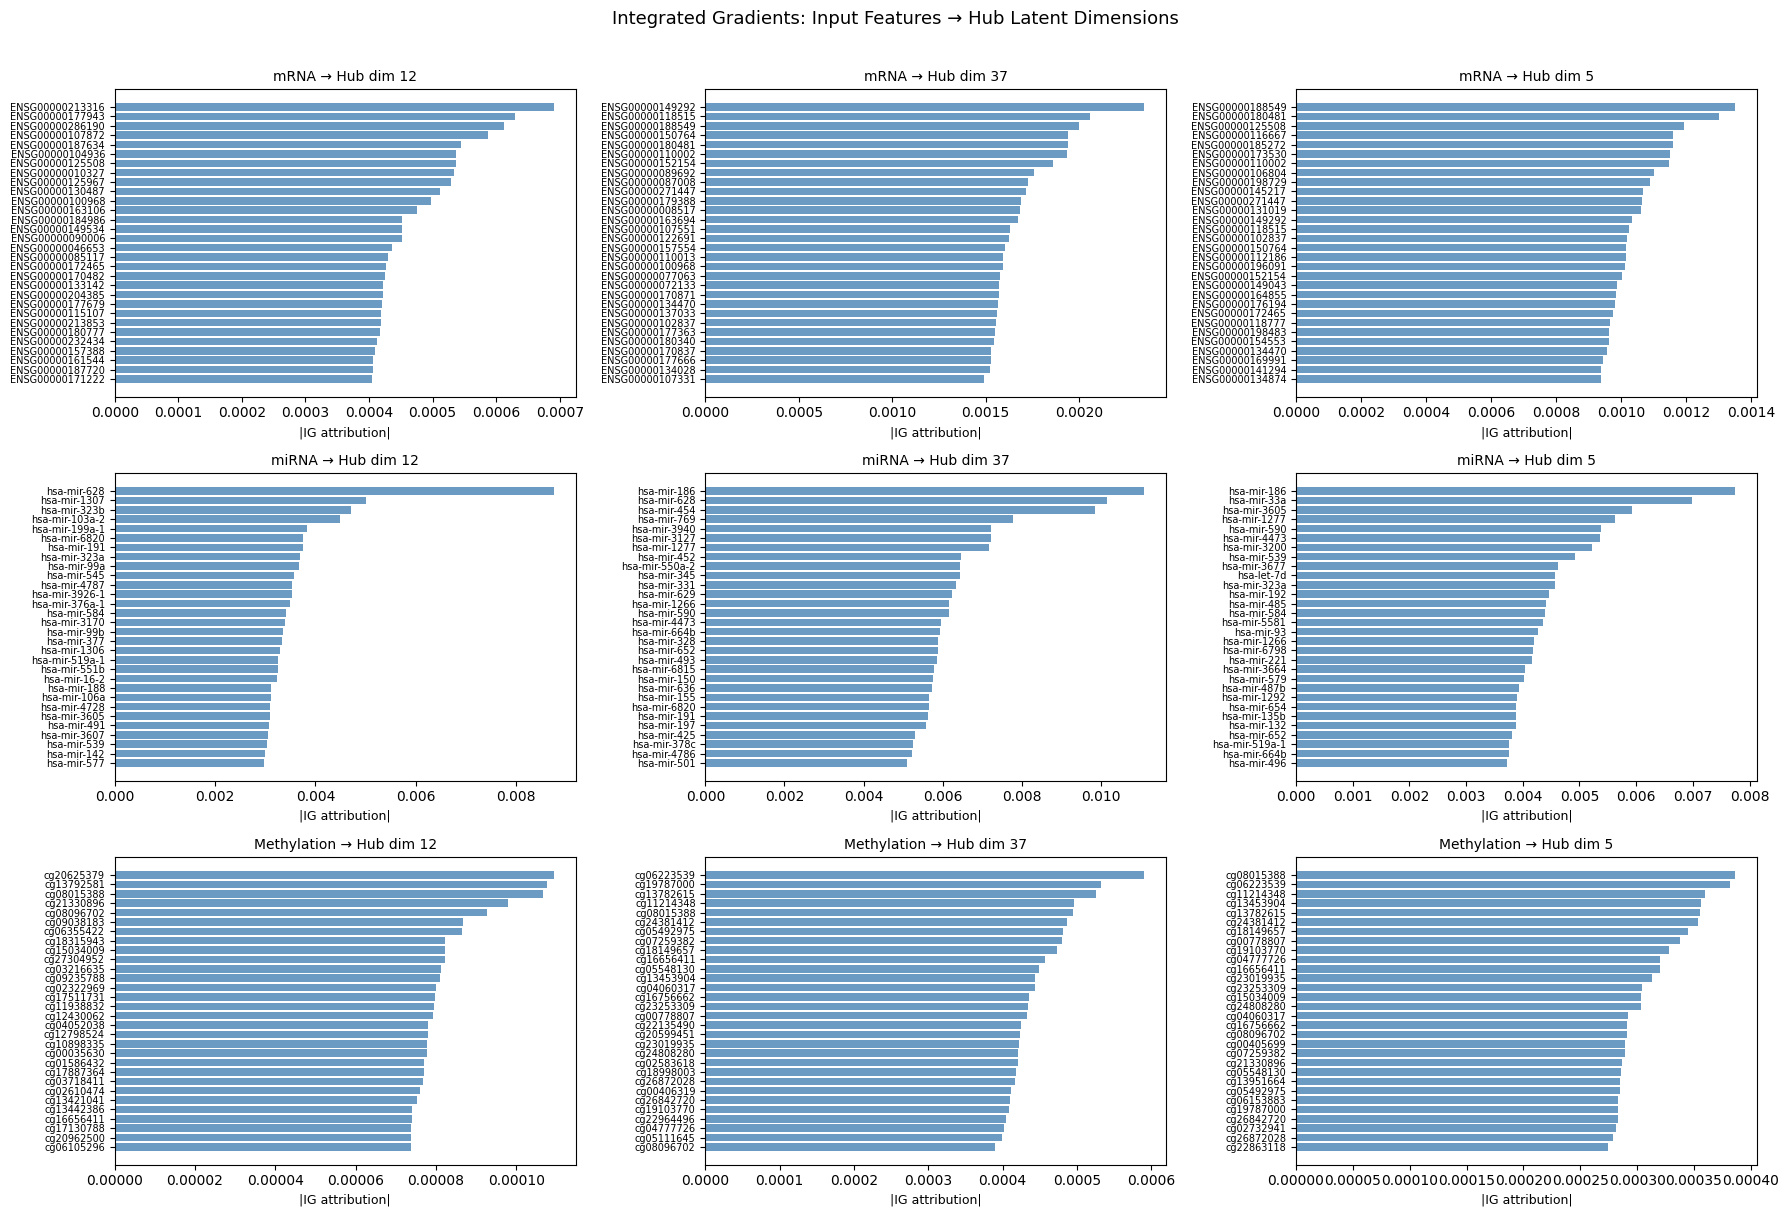

In [34]:
hub_attrs_ensemble = compute_hub_ig_ensemble(ensemble_states, CONFIG, n_steps=50)
print_top_features(hub_attrs_ensemble, top_k=20)
plot_hub_attributions(hub_attrs_ensemble, top_k=30)

# Run MORE BASELINES

## MVAE Baseline

In [58]:
# ─────────────────────────────────────────────────────────────────────────────
# MVAE Baseline — Mixture of Experts fusion
# Wu & Goodman, NeurIPS 2018
# Same encoders, decoders, survival head as CrossPoE.
# Only difference: MixtureOfExperts fusion instead of ProductOfExperts.
# No translation heads, no consistency losses, no gate networks.
# ─────────────────────────────────────────────────────────────────────────────

class MixtureOfExperts(nn.Module):
    """
    Mixture of Experts posterior.
    Joint posterior = uniform mixture of individual modality posteriors.
    For K observed modalities, samples z ~ (1/K) * sum_k q(z | x_k).
    
    At inference with missing modalities: mixture only over observed experts.
    This is MVAE's native missingness handling — no imputation needed.
    """
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim

    def forward(self, mu_list, logvar_list):
        """
        Args:
            mu_list:     list of (batch, latent_dim) for OBSERVED modalities
            logvar_list: list of (batch, latent_dim) for OBSERVED modalities
        Returns:
            mu_moe:     (batch, latent_dim) mixture mean
            logvar_moe: (batch, latent_dim) mixture logvar (diagonal approx)
        """
        # Stack: (K, batch, latent_dim)
        mus     = torch.stack(mu_list,     dim=0)
        logvars = torch.stack(logvar_list, dim=0)
        
        # Mixture mean = mean of component means
        mu_moe = mus.mean(dim=0)
        
        # Mixture variance approximation:
        # Var[mixture] = E[Var] + Var[E] (law of total variance)
        # E[Var] = mean of component variances
        # Var[E] = variance of component means
        vars_    = logvars.exp()
        e_var    = vars_.mean(dim=0)
        var_e    = mus.var(dim=0, unbiased=False)
        var_moe  = e_var + var_e
        # Clamp to avoid log(0)
        logvar_moe = torch.log(var_moe + 1e-8)
        
        return mu_moe, logvar_moe


class MVAE(nn.Module):
    """
    Multimodal VAE with Mixture-of-Experts fusion.
    Architecturally identical to CrossPoE except:
    - MixtureOfExperts replaces ProductOfExperts
    - No translation heads
    - No gate networks
    - No consistency / cycle / surv_trans losses
    """
    def __init__(self, latent_dim=N_LATENT, n_methyl=None):
        super().__init__()
        self.latent_dim = latent_dim
        n_methyl = n_methyl or TCGABRCADataset._methyl_data.shape[1]

        # Same encoders as CrossPoE
        self.rna_enc    = RNAEncoder(latent_dim=latent_dim)
        self.mirna_enc  = MIRNAEncoder(latent_dim=latent_dim)
        self.methyl_enc = MethylEncoder(in_dim=n_methyl, latent_dim=latent_dim)

        # Same decoders as CrossPoE
        self.rna_dec    = RNADecoder(latent_dim=latent_dim)
        self.mirna_dec  = MIRNADecoder(latent_dim=latent_dim)
        self.methyl_dec = MethylDecoder(latent_dim=latent_dim, out_dim=n_methyl)

        self.moe = MixtureOfExperts(latent_dim=latent_dim)

    def forward(self, batch):
        batch_size = batch["mask"].shape[0]
        device     = batch["mask"].device
        mask       = batch["mask"]

        rna_mask    = mask[:, 0]
        mirna_mask  = mask[:, 1]
        methyl_mask = mask[:, 2]

        mu_rna    = torch.zeros(batch_size, self.latent_dim, device=device)
        lv_rna    = torch.zeros(batch_size, self.latent_dim, device=device)
        mu_mirna  = torch.zeros(batch_size, self.latent_dim, device=device)
        lv_mirna  = torch.zeros(batch_size, self.latent_dim, device=device)
        mu_methyl = torch.zeros(batch_size, self.latent_dim, device=device)
        lv_methyl = torch.zeros(batch_size, self.latent_dim, device=device)

        if rna_mask.any() and batch["rna"] is not None:
            mu_r, lv_r = self.rna_enc(batch["rna"][rna_mask])
            mu_rna[rna_mask]    = mu_r
            lv_rna[rna_mask]    = lv_r
        if mirna_mask.any() and batch["mirna"] is not None:
            mu_m, lv_m = self.mirna_enc(batch["mirna"][mirna_mask])
            mu_mirna[mirna_mask]  = mu_m
            lv_mirna[mirna_mask]  = lv_m
        if methyl_mask.any() and batch["methyl"] is not None:
            mu_me, lv_me = self.methyl_enc(batch["methyl"][methyl_mask])
            mu_methyl[methyl_mask] = mu_me
            lv_methyl[methyl_mask] = lv_me

        # Build per-sample mixture only over observed modalities
        # Process per-sample to handle variable observed sets
        modality_masks = [rna_mask, mirna_mask, methyl_mask]
        all_mus     = [mu_rna, mu_mirna, mu_methyl]
        all_logvars = [lv_rna, lv_mirna, lv_methyl]

        mu_moe     = torch.zeros(batch_size, self.latent_dim, device=device)
        logvar_moe = torch.zeros(batch_size, self.latent_dim, device=device)

        # Group samples by their observed modality pattern for efficiency
        # For each unique pattern, apply MoE to that subset
        patterns = mask.cpu().numpy()
        unique_patterns = np.unique(patterns, axis=0)

        for pat in unique_patterns:
            pat_tensor = torch.tensor(pat, dtype=torch.bool, device=device)
            sample_mask = (mask == pat_tensor).all(dim=1)
            if not sample_mask.any():
                continue

            obs_indices = [i for i in range(3) if pat[i]]
            if not obs_indices:
                continue

            mu_obs  = [all_mus[i][sample_mask]     for i in obs_indices]
            lv_obs  = [all_logvars[i][sample_mask]  for i in obs_indices]

            if len(obs_indices) == 1:
                mu_moe[sample_mask]     = mu_obs[0]
                logvar_moe[sample_mask] = lv_obs[0]
            else:
                mu_p, lv_p = self.moe(mu_obs, lv_obs)
                mu_moe[sample_mask]     = mu_p
                logvar_moe[sample_mask] = lv_p

        z = reparameterise(mu_moe, logvar_moe)

        # Reconstructions
        recons = {}
        decoders = [self.rna_dec, self.mirna_dec, self.methyl_dec]
        names    = ["rna", "mirna", "methyl"]
        for m_idx, (dec, name) in enumerate(zip(decoders, names)):
            obs = modality_masks[m_idx]
            if not obs.any():
                continue
            feat_dim   = dec.net[-1].out_features
            recon_full = torch.zeros(batch_size, feat_dim, device=device)
            recon_full[obs] = dec(z[obs])
            recons[name]    = recon_full

        return {
            "mu_moe":     mu_moe,
            "logvar_moe": logvar_moe,
            "z_surv":     z,
            "recons":     recons,
            "mus":        all_mus,
            "logvars":    all_logvars,
            "mask":       mask,
        }

def compute_loss_mvae(outputs, batch, beta, lambda_recon, lambda_survival, survival_head):
    """
    MVAE loss: reconstruction + KL + survival only.
    No translation, no consistency, no cycle, no gate.
    """
    device = batch["mask"].device
    mask   = batch["mask"]

    RECON_WEIGHTS = {
        "rna":    1.0,
        "mirna":  N_RNA / N_MIRNA,
        "methyl": N_RNA / N_METHYL,
    }

    # Reconstruction
    loss_recon = torch.tensor(0.0, device=device, requires_grad=True)
    recon_targets = {"rna": batch["rna"], "mirna": batch["mirna"], "methyl": batch["methyl"]}
    for m_idx, m_name in enumerate(["rna", "mirna", "methyl"]):
        if m_name not in outputs["recons"]:
            continue
        obs = mask[:, m_idx]
        if not obs.any() or recon_targets[m_name] is None:
            continue
        loss_recon = loss_recon + RECON_WEIGHTS[m_name] * F.mse_loss(
            outputs["recons"][m_name][obs], recon_targets[m_name][obs]
        )

    # KL
    mu     = outputs["mu_moe"]
    logvar = outputs["logvar_moe"]
    loss_kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    # Survival
    loss_surv = torch.tensor(0.0, device=device, requires_grad=True)
    valid_surv = batch["pfi_event"] >= 0
    if valid_surv.sum() >= 2 and batch["pfi_event"][valid_surv].sum() >= 1:
        risk = survival_head(outputs["z_surv"])
        loss_surv = cox_partial_likelihood_loss(
            risk[valid_surv], batch["pfi_time"][valid_surv], batch["pfi_event"][valid_surv]
        )

    total = (lambda_recon * loss_recon
             + beta * loss_kl
             + lambda_survival * loss_surv)

    return total, {
        "total": total.item(), "recon": loss_recon.item(),
        "kl": loss_kl.item(), "survival": loss_surv.item(),
    }


def run_mvae(cfg):
    """
    Run 5-fold CV for MVAE baseline.
    Same splits, same scalers, same Cox head as CrossPoE.
    """
    set_seed(cfg["seed"])

    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)
    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                          random_state=cfg["seed"])
    fold_results = []

    for fold_idx, (train_idx, val_idx) in enumerate(
            skf.split(np.arange(len(strat_labels)), strat_labels)):

        print(f"\n{'='*60}")
        print(f"MVAE FOLD {fold_idx+1} / {cfg['n_folds']}")
        print(f"{'='*60}")

        rna_scaler    = compute_scaler(TCGABRCADataset._rna_data[train_idx][TCGABRCADataset._rna_mask[train_idx]])
        mirna_scaler  = compute_scaler(TCGABRCADataset._mirna_data[train_idx][TCGABRCADataset._mirna_mask[train_idx]])
        methyl_scaler = compute_scaler(TCGABRCADataset._methyl_data[train_idx][TCGABRCADataset._methyl_mask[train_idx]])

        train_dataset = TCGABRCADataset(
            indices=train_idx, rna_scaler=rna_scaler,
            mirna_scaler=mirna_scaler, methyl_scaler=methyl_scaler,
            dropout_probs={"rna": 0.0, "mirna": 0.0, "methyl": 0.0},
        )
        val_dataset = TCGABRCADataset(
            indices=val_idx, rna_scaler=rna_scaler,
            mirna_scaler=mirna_scaler, methyl_scaler=methyl_scaler,
            dropout_probs=None,
        )
        train_loader = DataLoader(train_dataset, batch_size=cfg["batch_size"],
                                  shuffle=True, collate_fn=collate_fn,
                                  num_workers=0, pin_memory=True)
        val_loader   = DataLoader(val_dataset, batch_size=cfg["batch_size"]*2,
                                  shuffle=False, collate_fn=collate_fn,
                                  num_workers=0, pin_memory=True)

        set_seed(cfg["seed"] + fold_idx)
        model         = MVAE(latent_dim=N_LATENT).to(device)
        survival_head = SurvivalHead(N_LATENT).to(device)
        optimizer     = torch.optim.AdamW(
            list(model.parameters()) + list(survival_head.parameters()),
            lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"]
        )
        scheduler = CosineAnnealingLR(optimizer, T_max=cfg["n_epochs"], eta_min=1e-5)

        best_score   = -np.inf
        best_c_index = float("nan")
        best_epoch   = 0
        patience_ctr = 0
        best_state   = None

        for epoch in range(1, cfg["n_epochs"] + 1):
            model.train()
            survival_head.train()
            beta = min(1.0, epoch / cfg["kl_warmup_epochs"])

            for batch in train_loader:
                batch = move_batch_to_device(batch, device)
                optimizer.zero_grad()
                outputs = model(batch)
                loss, _ = compute_loss_mvae(
                    outputs, batch, beta,
                    lambda_recon=cfg["lambda_recon"],
                    lambda_survival=cfg["lambda_survival"],
                    survival_head=survival_head,
                )
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    list(model.parameters()) + list(survival_head.parameters()),
                    max_norm=1.0
                )
                optimizer.step()
            scheduler.step()

            # Evaluate
            model.eval()
            survival_head.eval()
            all_risk, all_time, all_event = [], [], []
            with torch.no_grad():
                for batch in val_loader:
                    batch   = move_batch_to_device(batch, device)
                    outputs = model(batch)
                    risk    = survival_head(outputs["z_surv"])
                    valid   = batch["pfi_event"] >= 0
                    if valid.any():
                        all_risk.append(risk[valid].cpu())
                        all_time.append(batch["pfi_time"][valid].cpu())
                        all_event.append(batch["pfi_event"][valid].cpu())

            c_index = float("nan")
            if all_risk:
                risk_np  = torch.cat(all_risk).squeeze().numpy()
                time_np  = torch.cat(all_time).numpy()
                event_np = torch.cat(all_event).numpy()
                if event_np.sum() > 0:
                    c_index = concordance_index(time_np, risk_np, event_np)

            print(f"  Epoch {epoch:3d} | beta={beta:.2f} | Val C-index: {c_index:.4f}")

            if epoch >= cfg.get("min_epochs", 1):
                score = c_index if not np.isnan(c_index) else -np.inf
                if score > best_score:
                    best_score   = score
                    best_c_index = c_index
                    best_epoch   = epoch
                    patience_ctr = 0
                    best_state   = {
                        "model":    {k: v.cpu().clone() for k, v in model.state_dict().items()},
                        "survival": {k: v.cpu().clone() for k, v in survival_head.state_dict().items()},
                    }
                else:
                    patience_ctr += 1
                    if patience_ctr >= cfg["patience"]:
                        print(f"  Early stopping at epoch {epoch} (best {best_epoch}, C-index {best_score:.4f})")
                        break

        fold_results.append({
            "fold": fold_idx + 1, "best_epoch": best_epoch,
            "best_c_index": best_c_index,
            "val_metrics": {"c_index": best_c_index},
            "model_state": best_state,
            "scalers": {"rna": rna_scaler, "mirna": mirna_scaler, "methyl": methyl_scaler},
        })
        print(f"\n  Fold {fold_idx+1} best epoch: {best_epoch}, C-index: {best_c_index:.4f}")

    cidxs = [fr["best_c_index"] for fr in fold_results]
    print(f"\n{'='*60}")
    print(f"MVAE CROSS-VALIDATION SUMMARY")
    print(f"{'='*60}")
    print(f"C-index: {np.nanmean(cidxs):.4f} +/- {np.nanstd(cidxs):.4f}")
    for fr in fold_results:
        print(f"  Fold {fr['fold']}: {fr['best_c_index']:.4f} (best epoch {fr['best_epoch']})")

    return fold_results

In [57]:
fold_results_mvae = run_mvae(CONFIG)


MVAE FOLD 1 / 5
  Epoch   1 | beta=0.03 | Val C-index: 0.6762
  Epoch   2 | beta=0.07 | Val C-index: 0.6216
  Epoch   3 | beta=0.10 | Val C-index: 0.6985
  Epoch   4 | beta=0.13 | Val C-index: 0.7181
  Epoch   5 | beta=0.17 | Val C-index: 0.6893
  Epoch   6 | beta=0.20 | Val C-index: 0.6789
  Epoch   7 | beta=0.23 | Val C-index: 0.6706
  Epoch   8 | beta=0.27 | Val C-index: 0.6278
  Epoch   9 | beta=0.30 | Val C-index: 0.5990
  Epoch  10 | beta=0.33 | Val C-index: 0.6734
  Epoch  11 | beta=0.37 | Val C-index: 0.6550
  Epoch  12 | beta=0.40 | Val C-index: 0.6284
  Epoch  13 | beta=0.43 | Val C-index: 0.6636
  Epoch  14 | beta=0.47 | Val C-index: 0.6835
  Epoch  15 | beta=0.50 | Val C-index: 0.7267
  Epoch  16 | beta=0.53 | Val C-index: 0.6768
  Epoch  17 | beta=0.57 | Val C-index: 0.6829
  Epoch  18 | beta=0.60 | Val C-index: 0.6752
  Epoch  19 | beta=0.63 | Val C-index: 0.7267
  Epoch  20 | beta=0.67 | Val C-index: 0.6722
  Epoch  21 | beta=0.70 | Val C-index: 0.6501
  Epoch  22 | bet

In [59]:
def run_mcar_single(fold_results, cfg, model_class, model_name="Model"):
    """
    Run MCAR evaluation for a single model.
    Works with any model whose forward() returns z_surv and
    whose fold_results match the standard format.
    """
    modalities = ["rna", "mirna", "methyl"]
    rates      = [0.0, 0.3, 0.5, 0.7, 0.9]

    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)
    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                          random_state=cfg["seed"])
    splits = list(skf.split(np.arange(len(strat_labels)), strat_labels))

    results = {mod: {r: [] for r in rates} for mod in modalities}

    for fold_idx, fr in enumerate(fold_results):
        _, val_idx = splits[fold_idx]

        # Load model from saved state
        model         = model_class(latent_dim=N_LATENT).to(device)
        survival_head = SurvivalHead(N_LATENT).to(device)
        model.load_state_dict(
            {k: v.to(device) for k, v in fr["model_state"]["model"].items()})
        survival_head.load_state_dict(
            {k: v.to(device) for k, v in fr["model_state"]["survival"].items()})
        model.eval()
        survival_head.eval()

        for mod in modalities:
            val_dataset = TCGABRCADataset(          # ← move here, create once per mod
                indices=val_idx,
                rna_scaler=fr["scalers"]["rna"],
                mirna_scaler=fr["scalers"]["mirna"],
                methyl_scaler=fr["scalers"]["methyl"],
                dropout_probs=None,
            )
            for rate in rates:
                mcar_dataset = MCARDataset(val_dataset,
                                           forced_missing_modality=mod,
                                           forced_missing_rate=rate)
                loader = DataLoader(mcar_dataset, batch_size=cfg["batch_size"]*2,
                                    shuffle=False, collate_fn=collate_fn, num_workers=0)

                all_risk, all_time, all_event = [], [], []
                with torch.no_grad():
                    for batch in loader:
                        batch   = move_batch_to_device(batch, device)
                        outputs = model(batch)
                        risk    = survival_head(outputs["z_surv"])
                        valid   = batch["pfi_event"] >= 0
                        if valid.any():
                            all_risk.append(risk[valid].cpu())
                            all_time.append(batch["pfi_time"][valid].cpu())
                            all_event.append(batch["pfi_event"][valid].cpu())

                c_index = float("nan")
                if all_risk:
                    risk_np  = torch.cat(all_risk).squeeze().numpy()
                    time_np  = torch.cat(all_time).numpy()
                    event_np = torch.cat(all_event).numpy()
                    if event_np.sum() > 0:
                        c_index = concordance_index(time_np, risk_np, event_np)

                results[mod][rate].append(c_index)

    # Print summary
    print(f"\n{'='*60}")
    print(f"MCAR ROBUSTNESS — {model_name}")
    print(f"{'='*60}")
    print(f"{'Modality':<10}", end="")
    for r in rates:
        print(f"  rate={r}", end="")
    print()
    print("-" * 60)
    for mod in modalities:
        print(f"  {mod:<8}", end="")
        for r in rates:
            mean_c = np.nanmean(results[mod][r])
            print(f"  {mean_c:.3f} ", end="")
        print()

    return results

In [64]:
mcar_mvae = run_mcar_single(fold_results_mvae, CONFIG, MVAE, model_name="MVAE")


MCAR ROBUSTNESS — MVAE
Modality    rate=0.0  rate=0.3  rate=0.5  rate=0.7  rate=0.9
------------------------------------------------------------
  rna       0.658   0.621   0.619   0.608   0.598 
  mirna     0.658   0.669   0.669   0.677   0.677 
  methyl    0.658   0.636   0.624   0.622   0.623 


## CLUE Baseline

In [65]:
# ─────────────────────────────────────────────────────────────────────────────
# CLUE Baseline — Cross-Linked Unified Embedding
# Tu et al., NeurIPS 2022
# Same encoders as CrossPoE. Adds cross-encoders between modality pairs.
# No PoE fusion — concatenates self + cross representations per modality,
# then averages across observed modalities for joint embedding.
# No survival-aware training of cross-encoders.
# ─────────────────────────────────────────────────────────────────────────────

class CrossEncoder(nn.Module):
    """
    Maps source modality latent representation to target modality latent space.
    Smaller than CrossPoE translation heads — CLUE uses simpler cross-encoders.
    Input: mu_src (latent_dim) -> output: mu_tgt_pred (latent_dim)
    """
    def __init__(self, latent_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, latent_dim),
        )

    def forward(self, z_src):
        return self.net(z_src)


class CLUE(nn.Module):
    """
    Cross-Linked Unified Embedding for bulk multi-omics.

    Architecture per sample:
    1. Each observed modality is encoded to z_i via its own encoder (self-encoding)
    2. Each observed modality is cross-encoded from every other observed modality
    3. For each modality, self + all cross representations are averaged
    4. Final joint embedding = mean across all modality-level representations

    Handles missing modalities by only using observed modality encoders
    and cross-encoders from observed sources.
    """
    def __init__(self, latent_dim=N_LATENT, hidden_dim=64, n_methyl=None):
        super().__init__()
        self.latent_dim = latent_dim
        self.n_mods     = 3
        n_methyl = n_methyl or TCGABRCADataset._methyl_data.shape[1]

        # Same encoders as CrossPoE
        self.rna_enc    = RNAEncoder(latent_dim=latent_dim)
        self.mirna_enc  = MIRNAEncoder(latent_dim=latent_dim)
        self.methyl_enc = MethylEncoder(in_dim=n_methyl, latent_dim=latent_dim)

        # Same decoders as CrossPoE
        self.rna_dec    = RNADecoder(latent_dim=latent_dim)
        self.mirna_dec  = MIRNADecoder(latent_dim=latent_dim)
        self.methyl_dec = MethylDecoder(latent_dim=latent_dim, out_dim=n_methyl)

        # Cross-encoders: one per ordered pair (src -> tgt), 6 total
        self.cross_encoders = nn.ModuleDict()
        for src in range(self.n_mods):
            for tgt in range(self.n_mods):
                if src == tgt:
                    continue
                self.cross_encoders[f"{src}_to_{tgt}"] = CrossEncoder(
                    latent_dim, hidden_dim
                )

    def forward(self, batch):
        batch_size = batch["mask"].shape[0]
        device     = batch["mask"].device
        mask       = batch["mask"]

        rna_mask    = mask[:, 0]
        mirna_mask  = mask[:, 1]
        methyl_mask = mask[:, 2]
        mod_masks   = [rna_mask, mirna_mask, methyl_mask]

        encoders = [self.rna_enc, self.mirna_enc, self.methyl_enc]
        decoders = [self.rna_dec, self.mirna_dec, self.methyl_dec]
        inputs   = [batch["rna"], batch["mirna"], batch["methyl"]]

        # Step 1: self-encode each observed modality
        self_z = [torch.zeros(batch_size, self.latent_dim, device=device)
                  for _ in range(self.n_mods)]

        for i in range(self.n_mods):
            obs = mod_masks[i]
            if obs.any() and inputs[i] is not None:
                mu_i, _ = encoders[i](inputs[i][obs])
                self_z[i][obs] = mu_i

        # Step 2: cross-encode from each observed source to each target
        # For each sample, aggregate: self_z[tgt] + all cross_z[src->tgt]
        # then average to get modality-level representation
        mod_reprs = [torch.zeros(batch_size, self.latent_dim, device=device)
                     for _ in range(self.n_mods)]
        mod_counts = [torch.zeros(batch_size, 1, device=device)
                      for _ in range(self.n_mods)]

        for tgt in range(self.n_mods):
            obs_tgt = mod_masks[tgt]
            if not obs_tgt.any():
                continue

            # Self contribution
            mod_reprs[tgt][obs_tgt] += self_z[tgt][obs_tgt]
            mod_counts[tgt][obs_tgt] += 1.0

            # Cross contributions from all observed sources
            for src in range(self.n_mods):
                if src == tgt:
                    continue
                # Samples where src is observed (regardless of tgt)
                obs_src = mod_masks[src]
                both    = obs_src  # cross-encode from src to tgt space

                if not both.any():
                    continue

                key    = f"{src}_to_{tgt}"
                cross  = self.cross_encoders[key](self_z[src][both].detach())
                mod_reprs[tgt][both]  += cross
                mod_counts[tgt][both] += 1.0

        # Normalise each modality representation
        for tgt in range(self.n_mods):
            obs = mod_masks[tgt]
            if obs.any():
                mod_reprs[tgt][obs] = (mod_reprs[tgt][obs]
                                       / (mod_counts[tgt][obs] + 1e-8))

        # Step 3: joint embedding = mean of observed modality representations
        z_joint    = torch.zeros(batch_size, self.latent_dim, device=device)
        obs_counts = torch.zeros(batch_size, 1, device=device)

        for i in range(self.n_mods):
            obs = mod_masks[i]
            if obs.any():
                z_joint[obs]    += mod_reprs[i][obs]
                obs_counts[obs] += 1.0

        z_joint = z_joint / (obs_counts + 1e-8)

        # Step 4: reconstruct from joint embedding
        recons    = {}
        mod_names = ["rna", "mirna", "methyl"]
        for i, (dec, name) in enumerate(zip(decoders, mod_names)):
            obs = mod_masks[i]
            if not obs.any():
                continue
            feat_dim   = dec.net[-1].out_features
            recon_full = torch.zeros(batch_size, feat_dim, device=device)
            recon_full[obs] = dec(z_joint[obs])
            recons[name]    = recon_full

        return {
            "z_surv":   z_joint,
            "recons":   recons,
            "self_z":   self_z,
            "mod_reprs": mod_reprs,
            "mask":     mask,
        }

def compute_loss_clue(outputs, batch, lambda_recon, lambda_survival,
                      lambda_cross, survival_head, model):
    """
    CLUE loss: reconstruction + survival + cross-encoder consistency.

    Cross-encoder consistency: for fully observed pairs, the cross-encoded
    representation should match the self-encoded representation of the target.
    This is the core CLUE training signal — cross-encoders learn to predict
    what the target encoder would produce.
    """
    device = batch["mask"].device
    mask   = batch["mask"]

    RECON_WEIGHTS = {
        "rna":    1.0,
        "mirna":  N_RNA / N_MIRNA,
        "methyl": N_RNA / N_METHYL,
    }

    # Reconstruction loss
    loss_recon = torch.tensor(0.0, device=device, requires_grad=True)
    recon_targets = {"rna": batch["rna"], "mirna": batch["mirna"],
                     "methyl": batch["methyl"]}
    for m_idx, m_name in enumerate(["rna", "mirna", "methyl"]):
        if m_name not in outputs["recons"]:
            continue
        obs = mask[:, m_idx]
        if not obs.any() or recon_targets[m_name] is None:
            continue
        loss_recon = loss_recon + RECON_WEIGHTS[m_name] * F.mse_loss(
            outputs["recons"][m_name][obs], recon_targets[m_name][obs]
        )

    # Cross-encoder consistency loss
    # For fully observed pairs: cross_encode(src->tgt) should match self_z[tgt]
    loss_cross = torch.tensor(0.0, device=device, requires_grad=True)
    n_cross = 0
    self_z = outputs["self_z"]

    for src in range(3):
        for tgt in range(3):
            if src == tgt:
                continue
            both = mask[:, src] & mask[:, tgt]
            if not both.any():
                continue
            key   = f"{src}_to_{tgt}"
            cross = model.cross_encoders[key](self_z[src][both])
            # Target: self-encoded representation of target modality
            target = self_z[tgt][both].detach()
            loss_cross = loss_cross + F.mse_loss(cross, target)
            n_cross += 1

    if n_cross > 0:
        loss_cross = loss_cross / n_cross

    # Survival loss
    loss_surv = torch.tensor(0.0, device=device, requires_grad=True)
    valid_surv = batch["pfi_event"] >= 0
    if valid_surv.sum() >= 2 and batch["pfi_event"][valid_surv].sum() >= 1:
        risk = survival_head(outputs["z_surv"])
        loss_surv = cox_partial_likelihood_loss(
            risk[valid_surv], batch["pfi_time"][valid_surv],
            batch["pfi_event"][valid_surv]
        )

    total = (lambda_recon    * loss_recon
             + lambda_cross  * loss_cross
             + lambda_survival * loss_surv)

    return total, {
        "total": total.item(), "recon": loss_recon.item(),
        "cross": loss_cross.item(), "survival": loss_surv.item(),
    }


def run_clue(cfg):
    """5-fold CV for CLUE. Same splits and scalers as CrossPoE."""
    set_seed(cfg["seed"])

    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)
    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                          random_state=cfg["seed"])
    fold_results = []

    for fold_idx, (train_idx, val_idx) in enumerate(
            skf.split(np.arange(len(strat_labels)), strat_labels)):

        print(f"\n{'='*60}")
        print(f"CLUE FOLD {fold_idx+1} / {cfg['n_folds']}")
        print(f"{'='*60}")

        rna_scaler    = compute_scaler(TCGABRCADataset._rna_data[train_idx][TCGABRCADataset._rna_mask[train_idx]])
        mirna_scaler  = compute_scaler(TCGABRCADataset._mirna_data[train_idx][TCGABRCADataset._mirna_mask[train_idx]])
        methyl_scaler = compute_scaler(TCGABRCADataset._methyl_data[train_idx][TCGABRCADataset._methyl_mask[train_idx]])

        train_dataset = TCGABRCADataset(
            indices=train_idx, rna_scaler=rna_scaler,
            mirna_scaler=mirna_scaler, methyl_scaler=methyl_scaler,
            dropout_probs={"rna": 0.0, "mirna": 0.0, "methyl": 0.0},
        )
        val_dataset = TCGABRCADataset(
            indices=val_idx, rna_scaler=rna_scaler,
            mirna_scaler=mirna_scaler, methyl_scaler=methyl_scaler,
            dropout_probs=None,
        )
        train_loader = DataLoader(train_dataset, batch_size=cfg["batch_size"],
                                  shuffle=True, collate_fn=collate_fn,
                                  num_workers=0, pin_memory=True)
        val_loader   = DataLoader(val_dataset, batch_size=cfg["batch_size"]*2,
                                  shuffle=False, collate_fn=collate_fn,
                                  num_workers=0, pin_memory=True)

        set_seed(cfg["seed"] + fold_idx)
        model         = CLUE(latent_dim=N_LATENT).to(device)
        survival_head = SurvivalHead(N_LATENT).to(device)
        optimizer     = torch.optim.AdamW(
            list(model.parameters()) + list(survival_head.parameters()),
            lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"]
        )
        scheduler = CosineAnnealingLR(optimizer, T_max=cfg["n_epochs"], eta_min=1e-5)

        best_score   = -np.inf
        best_c_index = float("nan")
        best_epoch   = 0
        patience_ctr = 0
        best_state   = None

        for epoch in range(1, cfg["n_epochs"] + 1):
            model.train()
            survival_head.train()

            train_loss = 0.0
            n_batches  = 0
            for batch in train_loader:
                batch = move_batch_to_device(batch, device)
                optimizer.zero_grad()
                outputs = model(batch)
                loss, loss_dict = compute_loss_clue(
                    outputs, batch,
                    lambda_recon=cfg["lambda_recon"],
                    lambda_survival=cfg["lambda_survival"],
                    lambda_cross=cfg.get("lambda_cross", 0.1),
                    survival_head=survival_head,
                    model=model,
                )
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    list(model.parameters()) + list(survival_head.parameters()),
                    max_norm=1.0
                )
                optimizer.step()
                train_loss += loss.item()
                n_batches  += 1
            scheduler.step()

            # Evaluate
            model.eval()
            survival_head.eval()
            all_risk, all_time, all_event = [], [], []
            with torch.no_grad():
                for batch in val_loader:
                    batch   = move_batch_to_device(batch, device)
                    outputs = model(batch)
                    risk    = survival_head(outputs["z_surv"])
                    valid   = batch["pfi_event"] >= 0
                    if valid.any():
                        all_risk.append(risk[valid].cpu())
                        all_time.append(batch["pfi_time"][valid].cpu())
                        all_event.append(batch["pfi_event"][valid].cpu())

            c_index = float("nan")
            if all_risk:
                risk_np  = torch.cat(all_risk).squeeze().numpy()
                time_np  = torch.cat(all_time).numpy()
                event_np = torch.cat(all_event).numpy()
                if event_np.sum() > 0:
                    c_index = concordance_index(time_np, risk_np, event_np)

            print(f"  Epoch {epoch:3d} | "
                  f"Train loss: {train_loss/n_batches:.4f} | "
                  f"Val C-index: {c_index:.4f}")

            if epoch >= cfg.get("min_epochs", 1):
                score = c_index if not np.isnan(c_index) else -np.inf
                if score > best_score:
                    best_score   = score
                    best_c_index = c_index
                    best_epoch   = epoch
                    patience_ctr = 0
                    best_state   = {
                        "model":    {k: v.cpu().clone() for k, v in model.state_dict().items()},
                        "survival": {k: v.cpu().clone() for k, v in survival_head.state_dict().items()},
                    }
                else:
                    patience_ctr += 1
                    if patience_ctr >= cfg["patience"]:
                        print(f"  Early stopping at epoch {epoch} "
                              f"(best {best_epoch}, C-index {best_score:.4f})")
                        break

        fold_results.append({
            "fold": fold_idx + 1, "best_epoch": best_epoch,
            "best_c_index": best_c_index,
            "val_metrics": {"c_index": best_c_index},
            "model_state": best_state,
            "scalers": {"rna": rna_scaler, "mirna": mirna_scaler,
                        "methyl": methyl_scaler},
        })
        print(f"\n  Fold {fold_idx+1} best epoch: {best_epoch}, "
              f"C-index: {best_c_index:.4f}")

    cidxs = [fr["best_c_index"] for fr in fold_results]
    print(f"\n{'='*60}")
    print(f"CLUE CROSS-VALIDATION SUMMARY")
    print(f"{'='*60}")
    print(f"C-index: {np.nanmean(cidxs):.4f} +/- {np.nanstd(cidxs):.4f}")
    for fr in fold_results:
        print(f"  Fold {fr['fold']}: {fr['best_c_index']:.4f} "
              f"(best epoch {fr['best_epoch']})")

    return fold_results

In [61]:
CONFIG["lambda_cross"] = 0.1  # cross-encoder consistency weight
fold_results_clue = run_clue(CONFIG)


CLUE FOLD 1 / 5
  Epoch   1 | Train loss: 1.5100 | Val C-index: 0.6501
  Epoch   2 | Train loss: 1.4119 | Val C-index: 0.6780
  Epoch   3 | Train loss: 1.3433 | Val C-index: 0.6608
  Epoch   4 | Train loss: 1.2785 | Val C-index: 0.6835
  Epoch   5 | Train loss: 1.2175 | Val C-index: 0.6808
  Epoch   6 | Train loss: 1.1681 | Val C-index: 0.6988
  Epoch   7 | Train loss: 1.1139 | Val C-index: 0.6529
  Epoch   8 | Train loss: 1.0826 | Val C-index: 0.7145
  Epoch   9 | Train loss: 1.0443 | Val C-index: 0.7350
  Epoch  10 | Train loss: 1.0442 | Val C-index: 0.6869
  Epoch  11 | Train loss: 1.0174 | Val C-index: 0.6480
  Epoch  12 | Train loss: 0.9825 | Val C-index: 0.7286
  Epoch  13 | Train loss: 0.9707 | Val C-index: 0.7062
  Epoch  14 | Train loss: 0.9616 | Val C-index: 0.6777
  Epoch  15 | Train loss: 0.9447 | Val C-index: 0.6896
  Epoch  16 | Train loss: 0.9232 | Val C-index: 0.7417
  Epoch  17 | Train loss: 0.9155 | Val C-index: 0.7325
  Epoch  18 | Train loss: 0.9140 | Val C-index: 

In [66]:
CONFIG["lambda_cross"] = 0.1  # cross-encoder consistency weight
mcar_clue = run_mcar_single(fold_results_clue, CONFIG, CLUE, model_name="CLUE")


MCAR ROBUSTNESS — CLUE
Modality    rate=0.0  rate=0.3  rate=0.5  rate=0.7  rate=0.9
------------------------------------------------------------
  rna       0.681   0.654   0.651   0.648   0.642 
  mirna     0.681   0.694   0.696   0.697   0.695 
  methyl    0.681   0.660   0.654   0.643   0.644 


## MOFA+

In [67]:
from mofapy2.run.entry_point import entry_point
import pandas as pd

In [68]:
def run_mofa(cfg, n_factors=20):
    """
    MOFA+ baseline: unsupervised factorisation + Cox head.
    Same 5-fold CV splits as CrossPoE.
    n_factors=20 is standard for TCGA multi-omics.
    """
    set_seed(cfg["seed"])

    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)
    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                          random_state=cfg["seed"])
    fold_results = []

    # Prepare full data arrays
    rna_data    = TCGABRCADataset._rna_data       # (n, n_rna)
    mirna_data  = TCGABRCADataset._mirna_data     # (n, n_mirna)
    methyl_data = TCGABRCADataset._methyl_data    # (n, n_methyl)
    rna_mask    = TCGABRCADataset._rna_mask
    mirna_mask  = TCGABRCADataset._mirna_mask
    methyl_mask = TCGABRCADataset._methyl_mask
    sample_ids  = TCGABRCADataset._sample_ids

    for fold_idx, (train_idx, val_idx) in enumerate(
            skf.split(np.arange(len(strat_labels)), strat_labels)):

        print(f"\n{'='*60}")
        print(f"MOFA+ FOLD {fold_idx+1} / {cfg['n_folds']}")
        print(f"{'='*60}")

        # Fold-safe scalers — same as CrossPoE
        rna_scaler    = compute_scaler(rna_data[train_idx][rna_mask[train_idx]])
        mirna_scaler  = compute_scaler(mirna_data[train_idx][mirna_mask[train_idx]])
        methyl_scaler = compute_scaler(methyl_data[train_idx][methyl_mask[train_idx]])

        def scale(X, mask_arr, scaler):
            out = np.full_like(X, np.nan, dtype=np.float32)
            out[mask_arr] = apply_scaler(X[mask_arr], *scaler)
            return out

        rna_scaled    = scale(rna_data,    rna_mask,    rna_scaler)
        mirna_scaled  = scale(mirna_data,  mirna_mask,  mirna_scaler)
        methyl_scaled = scale(methyl_data, methyl_mask, methyl_scaler)

        # MOFA+ expects data as list of views x groups
        # Each view: (n_features, n_samples) with NaN for missing
        # Train on training samples only
        rna_train    = rna_scaled[train_idx]       # (n_train, n_rna) — no .T
        mirna_train  = mirna_scaled[train_idx]     # (n_train, n_mirna) — no .T
        methyl_train = methyl_scaled[train_idx]    # (n_train, n_methyl) — no .T

        sample_names = [str(s) for s in sample_ids[train_idx]]  # length = n_train, correct

        # Build MOFA+ entry point
        ent = entry_point()
        ent.set_data_options(scale_groups=False, scale_views=False)
        ent.set_data_matrix(
            data=[[rna_train], [mirna_train], [methyl_train]],  # each view is its own list
            likelihoods=["gaussian", "gaussian", "gaussian"],
            views_names=["rna", "mirna", "methyl"],
            groups_names=["BRCA"],
            samples_names=[sample_names],
            features_names=[
                [f"gene_{i}"  for i in range(rna_train.shape[1])],    # shape[1] not shape[0]
                [f"mirna_{i}" for i in range(mirna_train.shape[1])],
                [f"cpg_{i}"   for i in range(methyl_train.shape[1])],
            ],
        )
        ent.set_model_options(factors=n_factors)
        ent.set_train_options(
            iter=1000, convergence_mode="fast",
            startELBO=1, freqELBO=5,
            seed=cfg["seed"] + fold_idx,
            verbose=False,
        )

        print(f"  Training MOFA+ ({n_factors} factors)...")
        ent.build()
        ent.run()
        
        W_exp = ent.model.nodes["W"].getExpectations()
        Z_exp = ent.model.nodes["Z"].getExpectations()
        
        # Extract Z factors for training samples: (n_train, n_factors)
        z_train = Z_exp["E"]  # shape (n_train, n_factors)
        
        # Extract W weights per view: each W[i] is an object array wrapping a dict
        W_rna    = W_exp[0]["E"]  # (n_rna, n_factors)
        W_mirna  = W_exp[1]["E"]  # (n_mirna, n_factors)
        W_methyl = W_exp[2]["E"]  # (n_methyl, n_factors)

        def project_val(val_idx_arr):
            """Project validation samples into factor space via least squares."""
            z_vals = []
            for i in val_idx_arr:
                views, Ws = [], []
                if rna_mask[i]:
                    views.append(rna_scaled[i])
                    Ws.append(W_rna)
                if mirna_mask[i]:
                    views.append(mirna_scaled[i])
                    Ws.append(W_mirna)
                if methyl_mask[i]:
                    views.append(methyl_scaled[i])
                    Ws.append(W_methyl)

                if not views:
                    z_vals.append(np.zeros(n_factors))
                    continue

                X_obs = np.concatenate(views)           # (n_obs_features,)
                W_obs = np.vstack(Ws)                   # (n_obs_features, n_factors)
                # Least squares: z = (W^T W)^{-1} W^T x
                z_i, _, _, _ = np.linalg.lstsq(W_obs, X_obs, rcond=None)
                z_vals.append(z_i)

            return np.stack(z_vals)  # (n_val, n_factors)

        print(f"  Projecting validation samples...")
        z_val = project_val(val_idx)

        # Fit Cox head on training factors
        z_train_t = torch.tensor(z_train, dtype=torch.float32).to(device)
        z_val_t   = torch.tensor(z_val,   dtype=torch.float32).to(device)

        survival_head = SurvivalHead(n_factors).to(device)
        optimizer     = torch.optim.AdamW(
            survival_head.parameters(),
            lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"]
        )

        pfi_time_train  = TCGABRCADataset._pfi_time[train_idx].to(device)
        pfi_event_train = TCGABRCADataset._pfi_event[train_idx].to(device)
        valid_train     = pfi_event_train >= 0

        best_score   = -np.inf
        best_c_index = float("nan")
        best_epoch   = 0
        patience_ctr = 0
        best_state   = None

        print(f"  Training Cox head...")
        for epoch in range(1, cfg["n_epochs"] + 1):
            survival_head.train()
            optimizer.zero_grad()
            risk = survival_head(z_train_t)
            loss = cox_partial_likelihood_loss(
                risk[valid_train],
                pfi_time_train[valid_train],
                pfi_event_train[valid_train],
            )
            loss.backward()
            optimizer.step()

            # Evaluate on val
            survival_head.eval()
            with torch.no_grad():
                risk_val = survival_head(z_val_t).squeeze().cpu().numpy()

            pfi_time_val  = TCGABRCADataset._pfi_time[val_idx].numpy()
            pfi_event_val = TCGABRCADataset._pfi_event[val_idx].numpy()
            valid_val     = pfi_event_val >= 0

            c_index = float("nan")
            if valid_val.sum() >= 2 and pfi_event_val[valid_val].sum() >= 1:
                c_index = concordance_index(
                    pfi_time_val[valid_val],
                    risk_val[valid_val],
                    pfi_event_val[valid_val],
                )

            if epoch >= cfg.get("min_epochs", 1):
                score = c_index if not np.isnan(c_index) else -np.inf
                if score > best_score:
                    best_score   = score
                    best_c_index = c_index
                    best_epoch   = epoch
                    patience_ctr = 0
                    best_state   = {k: v.cpu().clone()
                                    for k, v in survival_head.state_dict().items()}
                else:
                    patience_ctr += 1
                    if patience_ctr >= cfg["patience"]:
                        print(f"  Early stopping at epoch {epoch} "
                              f"(best {best_epoch}, C-index {best_score:.4f})")
                        break

        fold_results.append({
            "fold": fold_idx + 1,
            "best_epoch": best_epoch,
            "best_c_index": best_c_index,
            "val_metrics": {"c_index": best_c_index},
            "z_val": z_val,
            "W": {"rna": W_rna, "mirna": W_mirna, "methyl": W_methyl},
            "scalers": {"rna": rna_scaler, "mirna": mirna_scaler,
                        "methyl": methyl_scaler},
            "survival_state": best_state,
            "n_factors": n_factors,
        })
        print(f"  Fold {fold_idx+1} best epoch: {best_epoch}, "
              f"C-index: {best_c_index:.4f}")

    cidxs = [fr["best_c_index"] for fr in fold_results]
    print(f"\n{'='*60}")
    print(f"MOFA+ CROSS-VALIDATION SUMMARY")
    print(f"{'='*60}")
    print(f"C-index: {np.nanmean(cidxs):.4f} +/- {np.nanstd(cidxs):.4f}")
    for fr in fold_results:
        print(f"  Fold {fr['fold']}: {fr['best_c_index']:.4f} "
              f"(best epoch {fr['best_epoch']})")

    return fold_results

In [69]:
def run_mcar_mofa(fold_results_mofa, cfg):
    """MCAR evaluation for MOFA+ using least-squares projection."""
    modalities = ["rna", "mirna", "methyl"]
    rates      = [0.0, 0.3, 0.5, 0.7, 0.9]
    mod_to_mask = {
        "rna":    TCGABRCADataset._rna_mask,
        "mirna":  TCGABRCADataset._mirna_mask,
        "methyl": TCGABRCADataset._methyl_mask,
    }

    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)
    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                          random_state=cfg["seed"])
    splits = list(skf.split(np.arange(len(strat_labels)), strat_labels))

    results = {mod: {r: [] for r in rates} for mod in modalities}

    for fold_idx, fr in enumerate(fold_results_mofa):
        _, val_idx = splits[fold_idx]
        n_factors  = fr["n_factors"]
        W          = fr["W"]
        scalers    = fr["scalers"]

        # Rebuild scaled data for this fold
        def scale(X, mask_arr, scaler):
            out = np.full_like(X, np.nan, dtype=np.float32)
            out[mask_arr] = apply_scaler(X[mask_arr], *scaler)
            return out

        rna_scaled    = scale(TCGABRCADataset._rna_data,
                              TCGABRCADataset._rna_mask, scalers["rna"])
        mirna_scaled  = scale(TCGABRCADataset._mirna_data,
                              TCGABRCADataset._mirna_mask, scalers["mirna"])
        methyl_scaled = scale(TCGABRCADataset._methyl_data,
                              TCGABRCADataset._methyl_mask, scalers["methyl"])

        scaled_data = {"rna": rna_scaled, "mirna": mirna_scaled,
                       "methyl": methyl_scaled}
        nat_masks   = {"rna": TCGABRCADataset._rna_mask,
                       "mirna": TCGABRCADataset._mirna_mask,
                       "methyl": TCGABRCADataset._methyl_mask}

        # Rebuild survival head
        survival_head = SurvivalHead(n_factors).to(device)
        survival_head.load_state_dict(
            {k: v.to(device) for k, v in fr["survival_state"].items()})
        survival_head.eval()

        for mod in modalities:
            for rate in rates:
                # Apply MCAR: randomly force mod missing at given rate
                np.random.seed(cfg["seed"] + fold_idx)
                forced_missing = (np.random.rand(len(val_idx)) < rate)

                z_vals = []
                for j, i in enumerate(val_idx):
                    views, Ws = [], []
                    for m in modalities:
                        # Skip if naturally missing OR forced missing for this mod
                        if m == mod and forced_missing[j]:
                            continue
                        if not nat_masks[m][i]:
                            continue
                        views.append(scaled_data[m][i])
                        Ws.append(W[m])

                    if not views:
                        z_vals.append(np.zeros(n_factors))
                        continue

                    X_obs = np.concatenate(views)
                    W_obs = np.vstack(Ws)
                    z_i, _, _, _ = np.linalg.lstsq(W_obs, X_obs, rcond=None)
                    z_vals.append(z_i)

                z_val_t = torch.tensor(
                    np.stack(z_vals), dtype=torch.float32).to(device)

                with torch.no_grad():
                    risk_val = survival_head(z_val_t).squeeze().cpu().numpy()

                pfi_time_val  = TCGABRCADataset._pfi_time[val_idx].numpy()
                pfi_event_val = TCGABRCADataset._pfi_event[val_idx].numpy()
                valid         = pfi_event_val >= 0

                c_index = float("nan")
                if valid.sum() >= 2 and pfi_event_val[valid].sum() >= 1:
                    c_index = concordance_index(
                        pfi_time_val[valid], risk_val[valid],
                        pfi_event_val[valid])

                results[mod][rate].append(c_index)

    print(f"\n{'='*60}")
    print(f"MCAR ROBUSTNESS — MOFA+")
    print(f"{'='*60}")
    print(f"{'Modality':<10}", end="")
    for r in rates:
        print(f"  rate={r}", end="")
    print()
    print("-" * 60)
    for mod in modalities:
        print(f"  {mod:<8}", end="")
        for r in rates:
            print(f"  {np.nanmean(results[mod][r]):.3f} ", end="")
        print()

    return results

In [43]:
fold_results_mofa = run_mofa(CONFIG, n_factors=20)


MOFA+ FOLD 1 / 5

        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Successfully loaded view='rna' group='BRCA' with N=876 samples and D=4652 features...
Successfully loaded view='mirna' group='BRCA' with N=876 samples and D=524 features...
Successfully loaded view='methyl' group='BRCA' with N=876 samples and D=37482 features...


Model options:
- Automatic Relevance Determination prior on the factors: False
- Automatic Relevance Dete

In [70]:
mcar_mofa = run_mcar_mofa(fold_results_mofa, CONFIG)


MCAR ROBUSTNESS — MOFA+
Modality    rate=0.0  rate=0.3  rate=0.5  rate=0.7  rate=0.9
------------------------------------------------------------
  rna       0.582   0.580   0.567   0.560   0.556 
  mirna     0.582   0.582   0.584   0.582   0.583 
  methyl    0.582   0.582   0.569   0.564   0.563 


## Full MCAR plot

In [127]:
# Restructure existing MCAR results into the format plot_mcar_comparison expects
# Expected format: {mod: {rate: [fold_c_indices]}}

def extract_mcar(mcar_results, model_key):
    """Extract results for one model from your existing mcar_results dict."""
    modalities = ["rna", "mirna", "methyl"]
    rates      = [0.0, 0.3, 0.5, 0.7, 0.9]
    out = {}
    for mod in modalities:
        out[mod] = {}
        for rate in rates:
            out[mod][rate] = mcar_results[mod][rate][model_key]
    return out

mcar_crossPoE = extract_mcar(mcar_results, "biopoe")
mcar_vanilla  = extract_mcar(mcar_results, "vanilla")

In [128]:
def plot_mcar_comparison(mcar_crossPoe, mcar_crossae, mcar_moevae, mcar_mofa,
                         mcar_vanilla, save_path="/g/data/yr31/rn8079/PhD/term2_development/plots/mcar_comparison.png"):
    """
    Plot MCAR robustness curves comparing all models across all modalities.
    
    Args:
        mcar_crossPoe: results dict from run_mcar_single for CrossPoE
        mcar_crossae:  results dict from run_mcar_single for CrossAE
        mcar_moevae:   results dict from run_mcar_single for MoE-VAE
        mcar_mofa:     results dict from run_mcar_mofa for MOFA+
        mcar_vanilla:  results dict from existing MCAR evaluation for VanillaPoE
    """
    rates      = [0.0, 0.3, 0.5, 0.7, 0.9]
    modalities = ["rna", "mirna", "methyl"]
    mod_labels = {"rna": "mRNA Missing", "mirna": "miRNA Missing", "methyl": "Methylation Missing"}

    # Model configs: (results_dict, display_name, color, linestyle, linewidth, marker)
    models = [
        (mcar_crossPoe, "CrossPoE",         "#1565C0", "-",   2.5, "o"),
        (mcar_crossae,  "CrossAE",           "#2E7D32", "--",  2.0, "s"),
        (mcar_moevae,   "MoE-VAE",           "#E65100", "-.",  2.0, "^"),
        (mcar_mofa,     "MOFA+",             "#6A1B9A", ":",   2.0, "D"),
        (mcar_vanilla,  "PoE-VAE",        "#757575", "--",  1.5, "x"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

    for ax_idx, mod in enumerate(modalities):
        ax = axes[ax_idx]

        for results, name, color, ls, lw, marker in models:
            # Get mean C-index at each rate
            means = [np.nanmean(results[mod][r]) for r in rates]
            ax.plot(rates, means,
                    label=name, color=color, linestyle=ls,
                    linewidth=lw, marker=marker, markersize=6,
                    markerfacecolor=color, markeredgecolor="white",
                    markeredgewidth=0.8)

        ax.set_title(mod_labels[mod], fontsize=12, fontweight="bold")
        ax.set_xlabel("Forced Missingness Rate", fontsize=11)
        if ax_idx == 0:
            ax.set_ylabel("Mean C-index (5-fold CV)", fontsize=11)
        ax.set_xticks(rates)
        ax.set_xticklabels([f"{r:.1f}" for r in rates])
        ax.set_xlim(-0.05, 0.95)
        ax.grid(True, alpha=0.3, linestyle="--")
        ax.tick_params(labelsize=10)

        # Annotate CrossPoE at rate=0.9 with value
        crosspoe_vals = [np.nanmean(mcar_crossPoe[mod][r]) for r in rates]
        ax.annotate(f"{crosspoe_vals[-1]:.3f}",
                    xy=(0.9, crosspoe_vals[-1]),
                    xytext=(0.78, crosspoe_vals[-1] + 0.008),
                    fontsize=8, color="#1565C0", fontweight="bold")

    # Single legend below all plots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels,
               loc="lower center", ncol=5,
               bbox_to_anchor=(0.5, -0.08),
               fontsize=10, framealpha=0.9,
               edgecolor="#CCCCCC")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

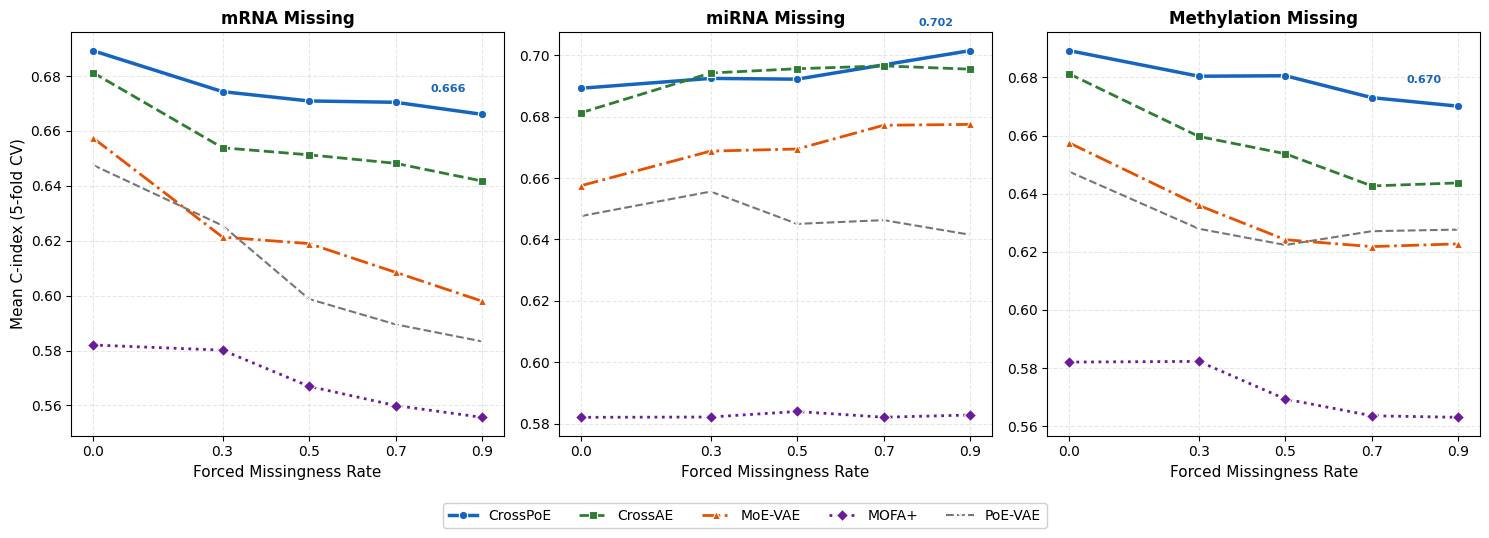

Saved: /g/data/yr31/rn8079/PhD/term2_development/plots/mcar_comparison.png


In [129]:
plot_mcar_comparison(
    mcar_crossPoe=mcar_crossPoE,  
    mcar_crossae=mcar_clue,
    mcar_moevae=mcar_mvae,
    mcar_mofa=mcar_mofa,
    mcar_vanilla=mcar_vanilla,
)

In [64]:
pickle.dump(fold_results_mvae, open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_mvae_canonical.pkl', 'wb'))
pickle.dump(fold_results_clue,   open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_clue_canonical.pkl', 'wb'))
pickle.dump(fold_results_mofa,  open('/g/data/yr31/rn8079/PhD/term2_development/saved_results/fold_results_mofa_canonical.pkl', 'wb'))


## Run survival Curves 

In [130]:
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import numpy as np

def plot_kaplan_meier(fold_results, cfg, save_path="/g/data/yr31/rn8079/PhD/term2_development/plots/kaplan_meier.png"):
    """
    Plot Kaplan-Meier survival curves splitting patients by CrossPoE risk score.
    Uses all validation patients across all 5 folds (no patient seen in training).
    High-risk vs low-risk split at median risk score.
    """
    from sklearn.model_selection import StratifiedKFold

    pfi_event_all = TCGABRCADataset._pfi_event.numpy()
    pfi_time_all  = TCGABRCADataset._pfi_time.numpy()
    strat_labels  = np.clip(pfi_event_all, 0, 1)

    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True,
                          random_state=cfg["seed"])
    splits = list(skf.split(np.arange(len(strat_labels)), strat_labels))

    all_risk   = []
    all_time   = []
    all_event  = []
    all_val_idx = []

    for fold_idx, fr in enumerate(fold_results):
        _, val_idx = splits[fold_idx]

        # Load model
        model         = BioPoE(latent_dim=N_LATENT).to(device)
        translator    = CrossModalTranslator(N_LATENT,
                            hidden_dim=cfg["translation_hidden_dim"]).to(device)
        survival_head = SurvivalHead(N_LATENT).to(device)

        model.load_state_dict(
            {k: v.to(device) for k, v in fr["model_state"]["model"].items()})
        translator.load_state_dict(
            {k: v.to(device) for k, v in fr["model_state"]["translator"].items()})
        survival_head.load_state_dict(
            {k: v.to(device) for k, v in fr["model_state"]["survival"].items()})
        model.eval()
        translator.eval()
        survival_head.eval()

        val_dataset = TCGABRCADataset(
            indices=val_idx,
            rna_scaler=fr["scalers"]["rna"],
            mirna_scaler=fr["scalers"]["mirna"],
            methyl_scaler=fr["scalers"]["methyl"],
            dropout_probs=None,
        )
        val_loader = DataLoader(val_dataset, batch_size=cfg["batch_size"]*2,
                                shuffle=False, collate_fn=collate_fn, num_workers=0)

        fold_risk = []
        with torch.no_grad():
            for batch in val_loader:
                batch   = move_batch_to_device(batch, device)
                outputs = model(batch, translator=translator,
                                epoch=cfg["n_epochs"],
                                translation_warmup_epochs=cfg["translation_warmup_epochs"])
                risk = survival_head(outputs["z_surv"]).squeeze(-1).cpu().numpy()
                fold_risk.append(risk)

        fold_risk = np.concatenate(fold_risk)
        all_risk.append(fold_risk)
        all_val_idx.append(val_idx)

    # Concatenate all validation patients
    all_risk    = np.concatenate(all_risk)
    all_val_idx = np.concatenate(all_val_idx)

    # Get survival labels for validation patients
    times  = pfi_time_all[all_val_idx]
    events = pfi_event_all[all_val_idx]

    # Filter to valid labels only
    valid  = events >= 0
    risk_v = all_risk[valid]
    time_v = times[valid]
    event_v = events[valid].astype(bool)

    # Split at median risk score
    median_risk = np.median(risk_v)
    high_risk   = risk_v >= median_risk
    low_risk    = ~high_risk

    # Log-rank test
    lr = logrank_test(
        time_v[high_risk],  time_v[low_risk],
        event_v[high_risk], event_v[low_risk],
    )
    p_val = lr.p_value

    # Plot
    fig, ax = plt.subplots(figsize=(7, 5))

    kmf_high = KaplanMeierFitter()
    kmf_low  = KaplanMeierFitter()

    kmf_high.fit(time_v[high_risk],  event_observed=event_v[high_risk],
                 label=f"High risk (n={high_risk.sum()})")
    kmf_low.fit(time_v[low_risk],   event_observed=event_v[low_risk],
                label=f"Low risk (n={low_risk.sum()})")

    kmf_high.plot_survival_function(ax=ax, color="#C62828", linewidth=2.0,
                                     ci_show=True, ci_alpha=0.12)
    kmf_low.plot_survival_function(ax=ax, color="#1565C0", linewidth=2.0,
                                    ci_show=True, ci_alpha=0.12)

    add_at_risk_counts(kmf_high, kmf_low, ax=ax, fontsize=9)

    # P-value annotation
    p_str = f"p = {p_val:.4f}" if p_val >= 0.0001 else "p < 0.0001"
    ax.text(0.97, 0.97, p_str,
            transform=ax.transAxes,
            ha="right", va="top", fontsize=11,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="#CCCCCC", alpha=0.9))

    ax.set_xlabel("Time (days)", fontsize=12)
    ax.set_ylabel("PFI Probability", fontsize=12)
    ax.set_title("CrossPoE Risk Stratification — TCGA-BRCA PFI\n"
                 "(Validation patients across all 5 folds)",
                 fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.05)

    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(fontsize=11, loc="lower left")
    plt.subplots_adjust(bottom=0.2)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")
    print(f"Log-rank test: {p_str}")
    print(f"High-risk events: {event_v[high_risk].sum()}/{high_risk.sum()}")
    print(f"Low-risk events:  {event_v[low_risk].sum()}/{low_risk.sum()}")

    return {
        "risk": risk_v, "time": time_v, "event": event_v,
        "high_risk_mask": high_risk, "p_value": p_val,
    }

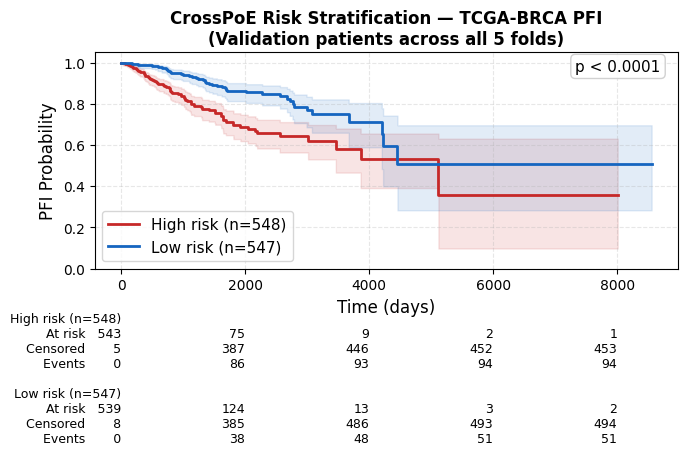

Saved: /g/data/yr31/rn8079/PhD/term2_development/plots/kaplan_meier.png
Log-rank test: p < 0.0001
High-risk events: 94/548
Low-risk events:  51/547


In [131]:
km_results = plot_kaplan_meier(fold_results_survival, CONFIG)